# Single-Cell Lineage Tracing Analysis — Fate Coupling Pipeline


**Purpose:** Compute fate coupling between cell types using clonal barcode data.  
**Methods:** SW (weighted), Jaccard (binary), Weinreb (weighted)  
**Input:** Prepared AnnData with scar barcodes from scRIPT lineage tracing  

---

## Section 0: Environment Setup

In [1]:
# ==============================================================================
# Section 0a: Imports
# ==============================================================================
#
# Every external package (library) this analysis depends on is loaded here.
# No external helper scripts — all functions are defined directly in this
# notebook so the full analysis is self-contained and auditable.
#
# Imports are grouped by purpose:
#   1. Python standard library  — built-in tools (file I/O, timing, etc.)
#   2. Core scientific stack    — numerical arrays, dataframes, single-cell
#   3. Plotting                 — figures and heatmaps
#   4. Sparse matrices & parallel computing — performance-critical internals
#
# Additional packages (scipy.stats, statsmodels, collections, etc.) are
# imported locally in the cells where they are first needed. This keeps
# dependencies visible next to the code that uses them.
#
# ==============================================================================

# ── 1. Python standard library ───────────────────────────────────────────────
# These ship with Python — no pip install needed.

import os          # File path manipulation, directory creation, environment variables
import sys         # Access to Python version string and loaded modules list
import time        # Wall-clock timing for permutation test and timestamps
import pickle      # Serialize (save/load) Python objects to/from binary files
import warnings    # Issue non-fatal warnings without crashing the notebook

# ── 2. Core scientific stack ─────────────────────────────────────────────────
# The fundamental libraries for numerical and single-cell genomics work.

import numpy as np        # N-dimensional arrays and fast numerical operations
                           # (all matrices, coupling computations, permutations)

import pandas as pd        # Tabular data (DataFrames) — wraps adata.obs columns,
                           # cross-tabulations, value_counts, groupby operations

import scanpy as sc        # Single-cell genomics toolkit — here used mainly for
                           # reading/writing AnnData objects (sc.read_h5ad)

import anndata             # AnnData data structure that holds expression + metadata;
                           # imported explicitly so Section 0b can report its version

import cospar as cs        # CoSpar: clonal fate analysis package (Shou-Wen Wang et al.)
                           # Used for: coarse_grain_clone_over_cell_clusters (validation),
                           # fate_coupling, fate_hierarchy (validation comparisons)

# ── 3. Plotting ──────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt       # Figure and axes creation, all plot rendering
import matplotlib.colors as colors    # Custom colormaps (ListedColormap for cell type
                                      # color bars in barcode heatmaps, Section 4b-C1)
import seaborn as sns                 # Only used for sns.__version__ in Section 0b;
                                      # all actual plotting uses matplotlib directly

# ── 4. Sparse matrices & parallel computing ──────────────────────────────────

import scipy.sparse as sparse              # Sparse matrix utilities — sparse.issparse()
                                           # checks used throughout when handling X_clone

from scipy.sparse import csr_matrix        # Compressed Sparse Row format — the format
                                           # used for the clone matrix (n_cells × n_clones);
                                           # extremely memory-efficient (~0.01% density)

from joblib import Parallel, delayed       # Parallel execution engine — distributes the
                                           # 10,000 permutation iterations across CPU cores
                                           # (params['n_jobs'] = -1 means use all cores)

In [2]:
# ==============================================================================
# Section 0b: Package Versions
# ==============================================================================
#
# Records the exact version of every package used in this analysis.
# This output should be included in the manuscript's supplementary materials
# so reviewers and readers can reproduce the environment precisely.
#
# How it works:
#   - Reads __version__ from each already-imported package
#   - For cospar specifically, cross-checks the runtime __version__ against
#     pip's installed metadata to detect editable-install / stale-cache
#     mismatches (common when developing from a local git clone)
#   - Prints a formatted table plus timestamp and working directory
#
# Why this matters:
#   CoSpar's coarse-graining and coupling functions have undocumented
#   dtype-dependent behavior (the SW binary bug). Pinning the exact version
#   ensures anyone re-running this notebook can verify whether they hit
#   the same bug we work around in Section 7a.
#
# Two packages imported here that are not in Section 0a:
#   - scipy              : needed for scipy.__version__; Section 0a only
#                          imported the submodule scipy.sparse, which does
#                          NOT place 'scipy' itself in the namespace
#   - importlib.metadata : standard-library module for querying pip-installed
#                          package versions without importing the package
#
# ==============================================================================

import scipy                # Parent package — needed here for scipy.__version__
                            # (Section 0a imported only scipy.sparse as sparse)

import importlib.metadata   # Standard-library tool for reading installed package
                            # metadata (version strings) from pip

# ── Build version table ──────────────────────────────────────────────────────
# Each entry: human-readable name → version string.
# Uses __version__ for packages already in the namespace (Section 0a),
# and importlib.metadata.version() for packages where only submodules
# were imported (matplotlib, joblib).

_versions = {
    'Python':      sys.version.split()[0],        # e.g. '3.10.12'
    'numpy':       np.__version__,
    'pandas':      pd.__version__,
    'scanpy':      sc.__version__,
    'cospar':      cs.__version__,                 # runtime version (authoritative)
    'anndata':     anndata.__version__,
    'scipy':       scipy.__version__,
    'matplotlib':  importlib.metadata.version('matplotlib'),   # see REVIEW NOTE 1
    'seaborn':     sns.__version__,
    'joblib':      importlib.metadata.version('joblib'),       # see REVIEW NOTE 2
}

# ── Print formatted version table ────────────────────────────────────────────
print("=" * 60)
print("Package Versions")
print("=" * 60)
for pkg, ver in _versions.items():
    print(f"  {pkg:<14s}: {ver}")

# Timestamp and working directory for provenance
print(f"\n  Date:        {time.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"  Working dir: {os.getcwd()}")

# ── CoSpar installation consistency check ─────────────────────────────────────
# CoSpar is sometimes installed from a local git clone (editable / dev mode).
# In that case, pip metadata can report an older version than what's actually
# loaded at runtime. The runtime __version__ is what the code actually sees,
# so it is authoritative. This check surfaces the mismatch early.

try:
    _cs_pip = importlib.metadata.version('cospar')
except importlib.metadata.PackageNotFoundError:
    _cs_pip = 'not found'

if _cs_pip != cs.__version__:
    print(f"\n  ⚠ cospar version mismatch detected:")
    print(f"    Runtime (__version__): {cs.__version__}")
    print(f"    Pip metadata:          {_cs_pip}")
    print(f"    Loaded from:           {cs.__file__}")
    print(f"    → Runtime version ({cs.__version__}) is authoritative")
else:
    print(f"\n  cospar loaded from: {cs.__file__}")

print("=" * 60)

Package Versions
  Python        : 3.11.12
  numpy         : 1.26.4
  pandas        : 2.2.3
  scanpy        : 1.11.1
  cospar        : 0.3.4
  anndata       : 0.9.2
  scipy         : 1.14.1
  matplotlib    : 3.7.3
  seaborn       : 0.13.2
  joblib        : 1.5.0

  Date:        2026-03-02 12:19:54
  Working dir: /home/ridvan/scRIPT/008_scLTy/scLTy_002/scLTy_002_part01

  ⚠ cospar version mismatch detected:
    Runtime (__version__): 0.3.4
    Pip metadata:          0.4.1
    Loaded from:           /home/ridvan/.local/share/mamba/envs/cospar/lib/python3.11/site-packages/cospar/__init__.py
    → Runtime version (0.3.4) is authoritative


In [3]:
# ==============================================================================
# Section 0c: Utility Functions
# ==============================================================================
#
# Shared helper functions used by multiple cells throughout the notebook.
# Defined once here so they are available everywhere without duplication.
#
# Currently contains one function:
#   _save_multiformat()  — saves a matplotlib figure in three formats at once
#
# The leading underscore in the name signals "internal helper, not part of
# the analysis logic." This is a Python convention, not enforced by the
# language.
#
# ==============================================================================

# ── Output formats for all figures ────────────────────────────────────────────
# Stored as a module-level constant so downstream print statements can
# reference it (e.g. "Formats: png, svg, pdf").
#
#   PNG  — raster, 300 dpi: for quick viewing, presentations, thesis drafts
#   SVG  — vector: editable in Illustrator / Inkscape, web-compatible
#   PDF  — vector: publication-ready, embeds fonts, used by LaTeX

SAVE_FORMATS = ['png', 'svg', 'pdf']


def _save_multiformat(fig, base_path, dpi=300, verbose=True):
    """
    Save a matplotlib figure in PNG, SVG, and PDF formats simultaneously.

    Parameters
    ----------
    fig : matplotlib.figure.Figure
        The figure object to save.  Typically the return value of
        plt.subplots() or plt.gcf().
    base_path : str
        File path WITHOUT extension (e.g. '/path/to/coupling_heatmap_SW').
        The function appends '.png', '.svg', and '.pdf' automatically.
        If a known extension is already present, it is stripped first
        so callers don't need to worry about it.
    dpi : int, default 300
        Resolution for the PNG file only.  SVG and PDF are vector formats
        and ignore this parameter (matplotlib accepts it silently).
    verbose : bool, default True
        If True, print the path of each saved file.

    Notes
    -----
    Uses bbox_inches='tight' to prevent axis labels or colorbars from
    being clipped at the figure boundary.
    """
    # ── Strip extension if caller accidentally included one ───────────────────
    # This avoids filenames like 'coupling_heatmap_SW.png.svg'.
    # Matches the three formats we save; any other extension is left alone
    # (assumed to be part of the filename, e.g. 'results_v2.1').
    for ext in SAVE_FORMATS:
        if base_path.endswith(f'.{ext}'):
            base_path = base_path[: -len(ext) - 1]   # -1 for the dot
            break

    # ── Save in each format ──────────────────────────────────────────────────
    for fmt in SAVE_FORMATS:
        fpath = f"{base_path}.{fmt}"
        fig.savefig(fpath, dpi=dpi, bbox_inches='tight', format=fmt)
        if verbose:
            print(f"    → {fpath}")

## Section 1: Parameters

All analysis settings are defined here. To run a different iteration  
(different conditions, resolution, barcode quality, trajectory), only  
modify this cell and re-run the entire notebook.

In [4]:
# ==============================================================================
# Section 1a: Analysis Parameters
# ==============================================================================
#
# Central configuration for the entire analysis.  Every downstream cell
# reads from the `params` dictionary — no hardcoded values elsewhere.
# To run a different iteration (different conditions, resolution, or
# lineage dataset), modify ONLY the values in this cell and re-run.
#
# The dictionary is organised into logical groups:
#   - Run identity & I/O paths
#   - Biological context (conditions, annotation, trajectory)
#   - Filtering thresholds
#   - Coupling analysis settings
#   - Statistical testing
#   - Random seed for reproducibility
#
# ==============================================================================

# ── Run Identity ──────────────────────────────────────────────────────────────
# Human-readable ID that encodes the analysis configuration.
# Format: {conditions}_{resolution}_{lineage_data}_{filtered}_{trajectory}
# This string is embedded in all output paths and print statements.

runid = 'D457_res1_Q50u_filtered_all'

# ── Output Paths ──────────────────────────────────────────────────────────────
# Base directory for all outputs of the scLTy_002 analysis series.
# os.path.expanduser resolves '~' to the actual home directory path.

base_out = os.path.expanduser(
    '~/scRIPT/008_scLTy/scLTy_002/scLTy_002_part01/'
)
output_dir = f"{base_out}{runid}/"

# ── Main parameter dictionary ─────────────────────────────────────────────────
params = {

    # ── Conditions / Days ─────────────────────────────────────────────────────
    # Which experimental time points (collection days) to include.
    # Cells from any condition not in this list are excluded in Section 3.
    'condition':     ['D4', 'D5', 'D7'],
    'condition_col': 'conditions',          # Column name in adata.obs

    # ── Annotation ────────────────────────────────────────────────────────────
    # Which cell type annotation column to use from adata.obs.
    # Determines the resolution of fate coupling (coarser vs. finer types).
    'annotation_resolution': 'annotation_res1',

    # ── Lineage Data ──────────────────────────────────────────────────────────
    # Column in adata.obs containing the CRISPR barcode (clone ID).
    # 'scar_q50_uniq' = SCAR barcodes, quality ≥50, uniquely mapped.
    'lineage_data': 'scar_q50_uniq',

    # ── Filtering ─────────────────────────────────────────────────────────────
    # Three thresholds controlling which cells / clones / cell types
    # enter the coupling analysis.  Applied in Section 3.
    'min_clone_size':            2,    # Hard filter: clones with fewer cells
                                       # are excluded entirely (singletons
                                       # cannot share fate with anything)
    'min_barcodes_per_celltype': 5,    # Hard filter: cell types with fewer
                                       # unique barcodes are excluded (too
                                       # few clones for reliable coupling)
    'low_coverage_threshold':   11,    # Soft flag: cell types below this are
                                       # included but results are flagged
                                       # with a caution warning (Section 4a)

    # ── Trajectory ────────────────────────────────────────────────────────────
    # Subset cells to a specific developmental trajectory.
    # 'all' keeps every cell; the other options filter to cells where
    # the corresponding boolean column in adata.obs is True.
    # Options: 'all', 'mesodermal_trajectory', 'endodermal_trajectory'
    'trajectory': 'all',

    # ── Coupling Analysis ─────────────────────────────────────────────────────
    # coupling_methods: list of method base names.  Used ONLY by Section 2a
    # to create per-method output directories.  The actual analysis
    # combinations (method × mode) are defined in Section 7c as
    # `coupling_analyses` — a more detailed list that also specifies
    # binarize flag, result key, and description for each combination.
    'coupling_methods':    ['SW', 'Jaccard', 'Weinreb'],
    'coupling_normalize':  True,   # Apply two-step normalization
                                   # (row then column-within-stage)

    # ── Statistical Testing ───────────────────────────────────────────────────
    'n_permutations': 10000,   # Number of label-shuffling iterations
    'n_jobs':         -1,      # Parallel CPU cores for joblib
                               # (-1 = use all available cores)
    'alpha':          0.05,    # Significance threshold for p-value and
                               # FDR reporting (Sections 8c, 8d)

    # ── Random Seed ───────────────────────────────────────────────────────────
    # Used in two places:
    #   1. np.random.seed() below — sets global RNG for Section 5c
    #      (random cell verification sampling)
    #   2. Passed to run_permutation_test() (Section 8a) which creates
    #      per-iteration RandomState(seed + i) — fully deterministic
    'random_seed': 42,

    # ── Identifiers ───────────────────────────────────────────────────────────
    'runid': runid,

    # ── Input Paths ───────────────────────────────────────────────────────────
    # AnnData object prepared by scLTy_001 (upstream pipeline).
    # Contains expression, embeddings, barcode annotations, trajectory flags.
    'input_adata': os.path.expanduser(
        '~/scRIPT/008_scLTy/scLTy_001/cospar/scLTy_001/adata_prepared.h5ad'
    ),
    # Pickle with analysis metadata: time_maps, celltype_orders, color_palettes.
    'metadata_pickle': os.path.expanduser(
        '~/scRIPT/008_scLTy/scLTy_001/cospar/scLTy_001/analysis_metadata.pkl'
    ),

    # ── Output Paths (main) ───────────────────────────────────────────────────
    'base_out':           base_out,
    'output_dir':         output_dir,
    'figures_output_dir': f"{output_dir}figures/",
    'data_output_dir':    f"{output_dir}data/",

    # ── Output Paths (per-method) ─────────────────────────────────────────────
    # Auto-generated below from coupling_methods list.
    # Each method gets: {output_dir}{runid}_{method}/  with data/ and figures/
}

# ── Auto-generate per-method output directories ──────────────────────────────
# Derived from coupling_methods so they stay in sync if the list changes.
for _method in params['coupling_methods']:
    params[f'output_dir_{_method}'] = f"{output_dir}{runid}_{_method}/"

# ── Reproducibility ──────────────────────────────────────────────────────────
# Set the global numpy random seed so any cell using np.random.*
# (without its own RandomState) produces deterministic results.
np.random.seed(params['random_seed'])

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"Run ID:      {params['runid']}")
print(f"Conditions:  {params['condition']}")
print(f"Annotation:  {params['annotation_resolution']}")
print(f"Barcodes:    {params['lineage_data']}")
print(f"Trajectory:  {params['trajectory']}")
print(f"Output dir:  {params['output_dir']}")

Run ID:      D457_res1_Q50u_filtered_all
Conditions:  ['D4', 'D5', 'D7']
Annotation:  annotation_res1
Barcodes:    scar_q50_uniq
Trajectory:  all
Output dir:  /home/ridvan/scRIPT/008_scLTy/scLTy_002/scLTy_002_part01/D457_res1_Q50u_filtered_all/


## Section 2: Create Output Directories and Load Data

In [5]:
# ==============================================================================
# Section 2a: Create Output Directory Structure
# ==============================================================================
#
# Builds the full directory tree for this analysis run before any data
# is loaded or processed.  Creating everything up front means we never
# hit "directory not found" errors deep inside a long computation.
#
# Each coupling method gets its own subdirectory with separate data/
# and figures/ folders.  This mirrors the per-method save logic in
# Section 9a, Section 10b, and others.
#
# ==============================================================================

def ensure_dirs(params):
    """
    Create all output directories for this analysis run.

    Builds the directory tree:
        {runid}/
        ├── data/                        ← global data outputs
        ├── figures/                     ← global figures
        ├── {runid}_SW/                  ← SW-specific
        │   ├── data/
        │   └── figures/
        ├── {runid}_Jaccard/             ← Jaccard-specific
        │   ├── data/
        │   └── figures/
        └── {runid}_Weinreb/             ← Weinreb-specific
            ├── data/
            └── figures/

    Parameters
    ----------
    params : dict
        Must contain the following keys:
        - 'output_dir'         : root directory for this run
        - 'figures_output_dir' : global figures directory
        - 'data_output_dir'    : global data directory
        - 'coupling_methods'   : list of method names (e.g. ['SW', 'Jaccard', 'Weinreb'])
        - 'output_dir_{method}': per-method base directory for each method
                                 (auto-generated in Section 1a)

    Returns
    -------
    dict
        Mapping of logical directory names to their resolved absolute paths.
        (Currently unused downstream, but available for interactive inspection.)
    """
    # ── Collect all directories to create ─────────────────────────────────────
    # Start with the three global directories (root, data, figures)
    dirs_to_create = {
        'output_dir':          params['output_dir'],
        'figures_output_dir':  params['figures_output_dir'],
        'data_output_dir':     params['data_output_dir'],
    }

    # Add per-method directories (base + data/ + figures/ for each method)
    # Reads from params['coupling_methods'] so the loop stays in sync with
    # Section 1a's auto-generated output_dir_{method} keys.
    for method in params['coupling_methods']:
        method_base = params[f'output_dir_{method}']
        dirs_to_create[f'output_dir_{method}']         = method_base
        dirs_to_create[f'figures_output_dir_{method}']  = f"{method_base}figures/"
        dirs_to_create[f'data_output_dir_{method}']     = f"{method_base}data/"

    # ── Create all directories ────────────────────────────────────────────────
    # os.makedirs with exist_ok=True is idempotent — safe to re-run.
    # expanduser is also idempotent (no-op if path is already expanded).
    created = {}
    for name, path in dirs_to_create.items():
        resolved = os.path.expanduser(path)
        os.makedirs(resolved, exist_ok=True)
        created[name] = resolved

    # ── Verify all directories actually exist ─────────────────────────────────
    # Belt-and-suspenders check: makedirs succeeded but the path might
    # still not be a directory (e.g. if a file with that name existed).
    for name, path in created.items():
        assert os.path.isdir(path), f"Failed to create: {path}"

    print(f"✓ Created {len(created)} directories under:")
    print(f"  {os.path.expanduser(params['output_dir'])}")

    return created


# ── Execute ───────────────────────────────────────────────────────────────────
created_dirs = ensure_dirs(params)

✓ Created 12 directories under:
  /home/ridvan/scRIPT/008_scLTy/scLTy_002/scLTy_002_part01/D457_res1_Q50u_filtered_all/


In [6]:
# ==============================================================================
# Section 2b: Load Data
# ==============================================================================
#
# Loads the two input files that the entire pipeline operates on:
#
#   1. adata_raw (AnnData, .h5ad)
#      The prepared single-cell dataset from the upstream pipeline
#      (scLTy_001).  Contains gene expression, embeddings, cell type
#      annotations, barcode columns, and trajectory flags.
#      Loaded into `adata_raw` — this variable is NEVER modified.
#      It is kept around so Section 4b (descriptive plots) can show
#      before-vs-after filtering comparisons, and Section 11 (session
#      info) can report the raw cell count.
#
#   2. metadata (dict, .pkl)
#      A pickle file containing pre-computed lookup tables that are
#      shared across analysis iterations:
#        - metadata['time_maps'][annot_col]
#              dict mapping cell type → developmental stage ('t0'/'t1')
#              Used by Sections 6a, 8a, 10e for stage-aware normalization
#        - metadata['celltype_orders'][annot_col]
#              canonical display ordering of cell types for heatmaps
#              Used by Sections 4b-setup, 6b
#        - metadata['color_palettes']['cell_type_colors']
#              list of hex color strings for plotting
#              Used by Section 4b-setup
#
# Both paths are read from params (Section 1a) — no hardcoded paths here.
#
# ==============================================================================

# ── Load AnnData ──────────────────────────────────────────────────────────────
# sc.read_h5ad() reads the HDF5-backed AnnData file into memory.
# This can take several seconds for large datasets.

input_path = params['input_adata']
assert os.path.isfile(input_path), f"AnnData file not found: {input_path}"

adata_raw = sc.read_h5ad(input_path)

print(f"Loaded AnnData: {adata_raw.shape[0]:,} cells × {adata_raw.shape[1]:,} genes")
print(f"  Source: {input_path}")

# ── Load metadata ─────────────────────────────────────────────────────────────
# pickle.load() deserializes the Python dict that was saved by scLTy_001.
# The 'rb' mode opens the file in binary-read mode (required for pickle).

meta_path = params['metadata_pickle']
assert os.path.isfile(meta_path), f"Metadata file not found: {meta_path}"

with open(meta_path, 'rb') as f:
    metadata = pickle.load(f)

print(f"Loaded metadata: {type(metadata).__name__} with {len(metadata)} keys")
print(f"  Source: {meta_path}")

Loaded AnnData: 25,562 cells × 27,998 genes
  Source: /home/ridvan/scRIPT/008_scLTy/scLTy_001/cospar/scLTy_001/adata_prepared.h5ad
Loaded metadata: dict with 7 keys
  Source: /home/ridvan/scRIPT/008_scLTy/scLTy_001/cospar/scLTy_001/analysis_metadata.pkl


In [7]:
# ==============================================================================
# Section 2c: Pre-Filtering Data Inspection
# ==============================================================================
#
# Systematic verification of the loaded AnnData before any filtering.
# Catches data problems (missing columns, unexpected values, broken
# barcodes) early — before they silently corrupt downstream results.
#
# Checks performed (in order):
#   1. Required columns exist in adata_raw.obs
#   2. Condition (day) distribution and requested conditions present
#   3. Cell type annotation distribution
#   4. Barcode column: valid vs invalid breakdown
#   5. Clone size statistics (on valid barcodes only)
#   6. Trajectory boolean columns contain only True/False
#   7. Embedding matrices present in adata_raw.obsm
#
# Also defines two shared utilities used by multiple downstream cells:
#
#   _is_string_like_dtype(series)
#       Returns True if the Series holds strings (dtype object or
#       Categorical with string categories).  Needed because pandas
#       barcodes may be stored as plain strings (object) or as
#       Categorical for memory efficiency.  The check matters because
#       string comparisons like (series == 'NA') would silently return
#       all-False on a numeric column.
#       Used by: Sections 2c, 3a, 4b-A3, 5a
#
#   _INVALID_BARCODE_STRINGS
#       Exhaustive list of string representations of missing values
#       that can appear in barcode columns depending on how upstream
#       tools export data (R writes 'NA', Python writes 'None', etc.).
#       Used by: Sections 2c, 3a, 4b-A3, 5a
#
# ==============================================================================

# ── Shared utility: detect string-like pandas dtype ──────────────────────────
# Used here and by Sections 3a, 4b-A3, and 5a to guard string comparisons.

def _is_string_like_dtype(series):
    """
    Check if a pandas Series holds string-like data.

    Returns True for:
      - dtype == object  (standard string storage)
      - CategoricalDtype whose categories are object-typed
        (memory-optimised string storage)

    Returns False for numeric, boolean, datetime, etc.

    Parameters
    ----------
    series : pd.Series

    Returns
    -------
    bool
    """
    if series.dtype == object:
        return True
    if isinstance(series.dtype, pd.CategoricalDtype):
        # Categorical — check the dtype of the underlying category labels
        return series.cat.categories.dtype == object
    return False


# ── Shared constant: string representations of missing barcodes ──────────────
# Covers outputs from R ('NA'), Python ('None', 'nan'), CSV quirks (''),
# and database-style ('NULL', 'N/A').  'NaN' and 'none' are case variants.
# Any cell whose barcode matches one of these is treated as untraced.

_INVALID_BARCODE_STRINGS = ['NA', 'nan', 'NaN', 'None', 'N/A', 'none', 'NULL', '']


# ══════════════════════════════════════════════════════════════════════════════
# Check 1: Required columns exist
# ══════════════════════════════════════════════════════════════════════════════
# Fail fast if the AnnData is missing any column the pipeline needs.

required_obs_cols = [
    params['condition_col'],            # e.g. 'conditions'
    params['annotation_resolution'],    # e.g. 'annotation_res1'
    params['lineage_data'],             # e.g. 'scar_q50_uniq'
    'mesodermal_trajectory',            # boolean, from upstream annotation
    'endodermal_trajectory',            # boolean, from upstream annotation
]

print("=" * 60)
print("Column Verification")
print("=" * 60)
missing_cols = [c for c in required_obs_cols if c not in adata_raw.obs.columns]
if missing_cols:
    raise KeyError(f"MISSING columns in adata.obs: {missing_cols}")
else:
    print("  ✓ All required columns present in adata.obs")


# ══════════════════════════════════════════════════════════════════════════════
# Check 2: Condition (day) distribution
# ══════════════════════════════════════════════════════════════════════════════
# Show how many cells come from each experimental condition (D4, D5, D7, …).
# Mark which ones will be kept vs excluded by Section 3 filtering.

print(f"\n{'─' * 60}")
print(f"Condition distribution ('{params['condition_col']}')")
print(f"{'─' * 60}")
cond_counts = adata_raw.obs[params['condition_col']].value_counts()
for cond, count in cond_counts.items():
    marker = "  ✓" if cond in params['condition'] else "  ✗ (will be excluded)"
    print(f"  {cond}: {count:>6,} cells {marker}")

# Verify that every condition requested in params actually exists in the data
missing_conds = set(params['condition']) - set(cond_counts.index)
if missing_conds:
    raise ValueError(f"Requested conditions not found in data: {missing_conds}")
print(f"\n  ✓ All {len(params['condition'])} requested conditions found")


# ══════════════════════════════════════════════════════════════════════════════
# Check 3: Cell type annotation distribution
# ══════════════════════════════════════════════════════════════════════════════
# Lists every cell type and its count, sorted alphabetically.
# Useful for spotting typos, unexpected categories, or low-count types.

print(f"\n{'─' * 60}")
print(f"Annotation distribution ('{params['annotation_resolution']}')")
print(f"{'─' * 60}")
annot_counts = (
    adata_raw.obs[params['annotation_resolution']]
    .value_counts()
    .sort_index()
)
print(f"  {len(annot_counts)} cell types:")
for ct, count in annot_counts.items():
    print(f"    {ct:<35s} {count:>6,} cells")


# ══════════════════════════════════════════════════════════════════════════════
# Check 4: Barcode column — valid vs invalid breakdown
# ══════════════════════════════════════════════════════════════════════════════
# Barcodes can be missing in two ways:
#   a) Real NaN  — pandas native missing value (from empty cells in h5ad)
#   b) String placeholders — 'NA', 'nan', 'None', '', etc. written by
#      upstream tools that don't use proper NaN representation
#
# We count both categories separately so the user can see exactly what
# kind of missingness dominates.

print(f"\n{'─' * 60}")
print(f"Barcode column ('{params['lineage_data']}')")
print(f"{'─' * 60}")
bc_col = adata_raw.obs[params['lineage_data']]
n_total = len(bc_col)

# Count real NaN (pandas native missing values)
n_na_real = bc_col.isna().sum()

# Count string representations of missing values
# Only meaningful if the column holds strings (not numeric/bool)
_is_str = _is_string_like_dtype(bc_col)
if _is_str:
    # Use the same _INVALID_BARCODE_STRINGS list that Section 3 uses for
    # filtering, so the reported count is guaranteed to match the number
    # of cells that will actually be removed.
    # Exclude real NaN from the .isin() check to avoid double-counting:
    # real NaN never equals any string, so .isin() naturally returns False
    # for NaN entries — no overlap.
    n_invalid_str = bc_col.isin(_INVALID_BARCODE_STRINGS).sum()
else:
    n_invalid_str = 0

n_invalid = n_na_real + n_invalid_str
n_valid   = n_total - n_invalid

print(f"  Total cells:                   {n_total:>7,}")
print(f"  Valid barcodes:                {n_valid:>7,} ({100*n_valid/n_total:.1f}%)")
print(f"  ── Invalid breakdown ──")
print(f"    NaN (real):                  {n_na_real:>7,}")
print(f"    Invalid strings (combined):  {n_invalid_str:>7,}")
if _is_str and n_invalid_str > 0:
    # Detailed per-pattern breakdown for diagnostics
    for pattern in _INVALID_BARCODE_STRINGS:
        n_match = (bc_col == pattern).sum()
        if n_match > 0:
            label = f"'{pattern}'" if pattern else "''"
            print(f"      {label:<12s}               {n_match:>7,}")


# ══════════════════════════════════════════════════════════════════════════════
# Check 5: Clone size statistics (valid barcodes only)
# ══════════════════════════════════════════════════════════════════════════════
# Compute clone sizes from the raw data (before any filtering) to
# characterise the barcode library.  Uses the same validity criteria
# as the filtering pipeline.

valid_mask = bc_col.notna()
if _is_string_like_dtype(bc_col):
    valid_mask = valid_mask & ~bc_col.isin(_INVALID_BARCODE_STRINGS)
valid_barcodes = bc_col[valid_mask]
clone_sizes = valid_barcodes.value_counts()

print(f"\n{'─' * 60}")
print(f"Clone Size Statistics (valid barcodes only)")
print(f"{'─' * 60}")
print(f"  Unique clones:       {len(clone_sizes):>7,}")
print(f"  Clone size range:    {clone_sizes.min()} – {clone_sizes.max()}")
print(f"  Clone size mean:     {clone_sizes.mean():.1f}")
print(f"  Clone size median:   {clone_sizes.median():.1f}")
print(f"  Clones with size=1:  {(clone_sizes == 1).sum():>7,} (singletons)")
print(f"  Clones with size≥{params['min_clone_size']}:  "
      f"{(clone_sizes >= params['min_clone_size']).sum():>7,}")


# ══════════════════════════════════════════════════════════════════════════════
# Check 6: Trajectory boolean columns
# ══════════════════════════════════════════════════════════════════════════════
# These columns are set by the upstream annotation pipeline and should
# contain only True/False.  Unexpected values (NaN, strings, integers)
# would cause silent misfiltering in Section 3 step 2.

print(f"\n{'─' * 60}")
print(f"Trajectory Columns")
print(f"{'─' * 60}")
for traj_col in ['mesodermal_trajectory', 'endodermal_trajectory']:
    vals = adata_raw.obs[traj_col].unique()
    n_true = (adata_raw.obs[traj_col] == True).sum()
    n_false = (adata_raw.obs[traj_col] == False).sum()
    print(f"  {traj_col}:")
    print(f"    True:  {n_true:>6,} cells")
    print(f"    False: {n_false:>6,} cells")
    # Flag anything that is not True or False
    unexpected = set(vals) - {True, False}
    if unexpected:
        warnings.warn(f"    ⚠️  Unexpected values: {unexpected}")
    else:
        print(f"    ✓ Only True/False values")


# ══════════════════════════════════════════════════════════════════════════════
# Check 7: Embedding matrices in adata.obsm
# ══════════════════════════════════════════════════════════════════════════════
# Lists all obsm keys with shapes.  Section 4b (UMAP plots) expects
# 'X_emb' — this check confirms it is present.

print(f"\n{'─' * 60}")
print(f"Embeddings in adata.obsm")
print(f"{'─' * 60}")
for key in adata_raw.obsm.keys():
    print(f"  {key}: shape {adata_raw.obsm[key].shape}")

print(f"\n{'=' * 60}")
print("Pre-filtering inspection complete.")
print(f"{'=' * 60}")

Column Verification
  ✓ All required columns present in adata.obs

────────────────────────────────────────────────────────────
Condition distribution ('conditions')
────────────────────────────────────────────────────────────
  D4: 11,016 cells   ✓
  D7: 10,423 cells   ✓
  D5:  4,123 cells   ✓

  ✓ All 3 requested conditions found

────────────────────────────────────────────────────────────
Annotation distribution ('annotation_res1')
────────────────────────────────────────────────────────────
  11 cell types:
    NaïveEpiblast                          753 cells
    Mesoderm                             6,358 cells
    Hemato/HEP_A                         2,878 cells
    Endot/HEP_B/C                        2,611 cells
    EMP                                     51 cells
    MchyMthel                            1,901 cells
    CardPhPr                             2,307 cells
    SomiticTis                           1,958 cells
    CardioM/Epicd                        2,126 cells
    E

## Section 3: Filtering

Filtering is applied in a strict sequential order. Each step is logged
with cell/clone counts so the impact of every filter is traceable.

**Filter order:**
1. Subset to requested conditions (D4, D5, D7)
2. Subset to requested trajectory (all / mesodermal / endodermal)
3. Remove cells without valid barcodes (NaN)
4. Remove clones with size < `min_clone_size`
5. Remove cell types with fewer than `min_barcodes_per_celltype` unique barcodes

Each filter operates on the output of the previous step.

In [8]:
# ==============================================================================
# Section 3a: Filtering Function
# ==============================================================================
#
# Central filtering pipeline: takes the raw AnnData object and returns a
# cleaned copy containing only cells suitable for fate coupling analysis.
#
# Filters are applied sequentially:
#   1. Condition (day) selection  — keep only requested time points
#   2. Trajectory selection       — optionally restrict to a germ layer
#   3. Barcode validity           — remove cells without a valid clone ID
#   4–5. Iterative clone + cell type filtering — converge to a dataset where
#        every clone has ≥ min_clone_size cells AND every cell type has
#        ≥ min_barcodes_per_celltype unique barcodes
#
# Why iterative (steps 4–5)?
#   These two filters are interdependent:
#     - Removing a low-coverage cell type deletes cells, which can shrink
#       clone sizes below the threshold.
#     - Removing a small clone deletes cells, which can reduce a cell type's
#       barcode count below the threshold.
#   A single pass is therefore insufficient.  The loop re-applies both
#   filters until nothing changes (fixed-point convergence).  The result
#   is the unique maximal dataset satisfying both constraints, regardless
#   of the order filters are applied within each iteration.
#
# Returns:
#   adata_f     — filtered copy (original adata is never modified)
#   filter_log  — dict of cell counts at each stage, consumed by
#                 Section 3b (waterfall plot) and Section 9 (save)
#
# ==============================================================================

def filter_adata(adata, params):
    """
    Filter AnnData for lineage tracing analysis.

    Applies filters sequentially:
        1. Condition selection
        2. Trajectory selection
        3. Remove cells without valid barcodes
        4. Remove clones below min_clone_size
        5. Remove cell types with insufficient barcode coverage
    Steps 4–5 iterate to convergence because they are interdependent.

    Parameters
    ----------
    adata : AnnData
        Raw (unfiltered) AnnData object.
    params : dict
        Analysis parameters. Required keys:
        - condition, condition_col
        - trajectory
        - lineage_data
        - min_clone_size
        - min_barcodes_per_celltype
        - annotation_resolution

    Returns
    -------
    adata_filtered : AnnData
        Filtered copy of the input.
    filter_log : dict
        Record of cell counts at each filtering stage.
    """

    # ── Unpack parameters for readability ─────────────────────────────────────
    # Local names make the code below easier to read; they do NOT shadow
    # anything in the outer scope because we're inside a function.

    condition_col = params['condition_col']
    annot_col     = params['annotation_resolution']
    barcode_col   = params['lineage_data']
    min_clone     = params['min_clone_size']
    min_bc_per_ct = params['min_barcodes_per_celltype']
    trajectory    = params['trajectory']
    conditions    = params['condition']

    filter_log = {}

    print("=" * 60)
    print(f"Filtering Pipeline — {params['runid']}")
    print("=" * 60)

    # ── Start: copy to avoid modifying the original ───────────────────────────
    # adata.copy() creates a full deep copy — safe to modify freely.
    adata_f = adata.copy()
    filter_log['0_raw'] = adata_f.n_obs
    print(f"\n  Starting cells: {adata_f.n_obs:,}")

    # ══════════════════════════════════════════════════════════════════════════
    # Step 1: Condition filter
    # ══════════════════════════════════════════════════════════════════════════
    # Keep only cells from the requested experimental time points.
    # params['condition'] = ['D4', 'D5', 'D7'] → cells from other days
    # (if any) are dropped.

    print(f"\n{'─' * 60}")
    print(f"Step 1: Condition filter → keep {conditions}")
    print(f"{'─' * 60}")

    mask_cond = adata_f.obs[condition_col].isin(conditions)
    n_before = adata_f.n_obs
    adata_f = adata_f[mask_cond].copy()
    n_removed = n_before - adata_f.n_obs
    filter_log['1_condition'] = adata_f.n_obs

    print(f"  Kept:    {adata_f.n_obs:,}")
    print(f"  Removed: {n_removed:,}")

    if n_removed == 0 and set(conditions) == set(adata.obs[condition_col].unique()):
        print(f"  (All conditions were already in the requested set)")

    # Verify only requested conditions remain
    remaining_conds = set(adata_f.obs[condition_col].unique())
    assert remaining_conds == set(conditions), \
        f"Condition filter failed: expected {set(conditions)}, got {remaining_conds}"

    # ══════════════════════════════════════════════════════════════════════════
    # Step 2: Trajectory filter
    # ══════════════════════════════════════════════════════════════════════════
    # If trajectory == 'all', keep every cell.
    # Otherwise keep only cells where the named boolean column is True.
    # This restricts the analysis to mesodermal or endodermal lineages.

    print(f"\n{'─' * 60}")
    print(f"Step 2: Trajectory filter → '{trajectory}'")
    print(f"{'─' * 60}")

    n_before = adata_f.n_obs

    if trajectory == 'all':
        # Keep all cells — no filtering
        print(f"  Trajectory = 'all': no cells removed")
    elif trajectory in ['mesodermal_trajectory', 'endodermal_trajectory']:
        # Filter to cells where trajectory column == True
        assert trajectory in adata_f.obs.columns, \
            f"Trajectory column '{trajectory}' not found in adata.obs"
        mask_traj = adata_f.obs[trajectory] == True
        adata_f = adata_f[mask_traj].copy()
        n_removed = n_before - adata_f.n_obs
        print(f"  Kept:    {adata_f.n_obs:,} (cells with {trajectory} == True)")
        print(f"  Removed: {n_removed:,}")
    else:
        raise ValueError(
            f"Unknown trajectory: '{trajectory}'. "
            f"Expected 'all', 'mesodermal_trajectory', or 'endodermal_trajectory'"
        )

    filter_log['2_trajectory'] = adata_f.n_obs

    # ══════════════════════════════════════════════════════════════════════════
    # Step 3: Remove cells without valid barcodes
    # ══════════════════════════════════════════════════════════════════════════
    # A cell must have a valid barcode (clone ID) to participate in fate
    # coupling.  "Invalid" means either a real NaN (pandas missing value)
    # or a string placeholder like 'NA', 'nan', '', etc.
    # Uses the same _INVALID_BARCODE_STRINGS constant defined in Section 2c.

    print(f"\n{'─' * 60}")
    print(f"Step 3: Remove cells without valid barcodes (NaN)")
    print(f"{'─' * 60}")

    n_before = adata_f.n_obs
    bc_values = adata_f.obs[barcode_col]

    # Build invalid mask: real NaN + any string representations of missing
    invalid_mask = bc_values.isna()
    if _is_string_like_dtype(bc_values):
        invalid_mask = invalid_mask | bc_values.isin(_INVALID_BARCODE_STRINGS)

    adata_f = adata_f[~invalid_mask].copy()
    n_removed = n_before - adata_f.n_obs
    filter_log['3_valid_barcodes'] = adata_f.n_obs

    print(f"  Kept:    {adata_f.n_obs:,} (cells with valid barcodes)")
    print(f"  Removed: {n_removed:,} (cells without barcodes)")
    print(f"  Barcode coverage: {100 * adata_f.n_obs / n_before:.1f}%")

    # ── Post-step-3 assertions: no invalid barcodes should survive ────────────
    assert adata_f.obs[barcode_col].isna().sum() == 0, \
        "NaN barcodes remain after filtering!"
    if _is_string_like_dtype(adata_f.obs[barcode_col]):
        assert (adata_f.obs[barcode_col].isin(_INVALID_BARCODE_STRINGS)).sum() == 0, \
            "Invalid string barcodes remain after filtering!"

    # ══════════════════════════════════════════════════════════════════════════
    # Steps 4–5: Iterative clone size + cell type coverage filtering
    # ══════════════════════════════════════════════════════════════════════════
    # These two filters are interdependent (see header docstring).
    # The loop applies both and repeats until nothing changes.
    #
    # Within each iteration:
    #   Step 4: remove clones with fewer than min_clone cells
    #   Step 5: remove cell types with fewer than min_bc_per_ct unique barcodes
    #
    # Convergence is guaranteed: each iteration either removes ≥1 cell
    # (strictly decreasing) or terminates.

    print(f"\n{'─' * 60}")
    print(f"Steps 4–5: Iterative clone/cell-type filtering")
    print(f"  min_clone_size = {min_clone}, min_barcodes_per_celltype = {min_bc_per_ct}")
    print(f"{'─' * 60}")

    iteration = 0
    max_iterations = 20   # safety limit — should converge in 2–3 in practice

    # Accumulate all excluded cell types across iterations so we can store
    # the complete list (not just the last iteration's empty list).
    all_failing_celltypes = []

    while iteration < max_iterations:
        iteration += 1
        n_before_iter = adata_f.n_obs

        # ── Step 4: Remove small clones ───────────────────────────────────────
        # Count cells per barcode (clone size) and drop clones below threshold.
        clone_sizes = adata_f.obs[barcode_col].value_counts()
        n_clones_before = len(clone_sizes)

        valid_clones = clone_sizes[clone_sizes >= min_clone].index
        invalid_clones = clone_sizes[clone_sizes < min_clone].index

        if len(invalid_clones) > 0:
            mask_clone = adata_f.obs[barcode_col].isin(valid_clones)
            adata_f = adata_f[mask_clone].copy()

        n_removed_clone_step = n_before_iter - adata_f.n_obs

        # ── Step 5: Remove cell types with insufficient barcode coverage ──────
        # Count unique barcodes per cell type.  A cell type needs enough
        # independent clones to produce a meaningful coupling estimate.
        n_before_ct = adata_f.n_obs
        bc_per_celltype = (
            adata_f.obs
            .groupby(annot_col, observed=True)[barcode_col]
            .nunique()
            .sort_values(ascending=True)
        )

        passing_celltypes = bc_per_celltype[bc_per_celltype >= min_bc_per_ct].index.tolist()
        failing_celltypes = bc_per_celltype[bc_per_celltype < min_bc_per_ct].index.tolist()

        if len(failing_celltypes) > 0:
            all_failing_celltypes.extend(failing_celltypes)
            mask_ct = adata_f.obs[annot_col].isin(passing_celltypes)
            adata_f = adata_f[mask_ct].copy()

        n_removed_ct_step = n_before_ct - adata_f.n_obs

        n_removed_total = n_before_iter - adata_f.n_obs

        # ── Iteration report ──────────────────────────────────────────────────
        print(f"\n  Iteration {iteration}:")
        print(f"    Clone filter:     removed {len(invalid_clones):,} clones, "
              f"{n_removed_clone_step:,} cells")
        print(f"    Cell type filter: removed {len(failing_celltypes)} cell types, "
              f"{n_removed_ct_step:,} cells")
        if failing_celltypes:
            print(f"      Excluded: {failing_celltypes}")
        print(f"    Remaining: {adata_f.n_obs:,} cells")

        # ── Convergence check ─────────────────────────────────────────────────
        # If nothing was removed in this iteration, both constraints are
        # simultaneously satisfied — we have reached the fixed point.
        if n_removed_total == 0:
            print(f"\n  ✓ Converged after {iteration} iteration(s)")
            break
    else:
        # while-else: only executes if the loop ran to max_iterations
        raise RuntimeError(
            f"Filter convergence failed after {max_iterations} iterations. "
            f"Remaining cells: {adata_f.n_obs:,}"
        )

    filter_log['4_5_clone_and_celltype'] = adata_f.n_obs

    # ══════════════════════════════════════════════════════════════════════════
    # Post-convergence verification
    # ══════════════════════════════════════════════════════════════════════════
    # Assert that the final dataset actually satisfies both constraints.
    # These assertions should never fire if the loop logic is correct —
    # they serve as a safety net.

    final_clone_sizes_check = adata_f.obs[barcode_col].value_counts()
    assert final_clone_sizes_check.min() >= min_clone, \
        f"Clone size filter failed: min clone size is {final_clone_sizes_check.min()}"

    bc_per_ct_final = (
        adata_f.obs
        .groupby(annot_col, observed=True)[barcode_col]
        .nunique()
    )
    assert bc_per_ct_final.min() >= min_bc_per_ct, \
        f"Barcode coverage filter failed: min coverage is {bc_per_ct_final.min()}"

    print(f"\n  Unique barcodes per cell type (final):")
    for ct, n_bc in bc_per_ct_final.sort_values(ascending=True).items():
        print(f"    {ct:<35s} {n_bc:>5,} barcodes  ✓")

    # ══════════════════════════════════════════════════════════════════════════
    # Final Summary
    # ══════════════════════════════════════════════════════════════════════════

    print(f"\n{'=' * 60}")
    print(f"Filtering Complete")
    print(f"{'=' * 60}")

    final_celltypes = sorted(adata_f.obs[annot_col].unique())
    final_clones = adata_f.obs[barcode_col].nunique()
    final_clone_sizes = adata_f.obs[barcode_col].value_counts()

    print(f"  Cells:      {filter_log['0_raw']:>7,} → {adata_f.n_obs:>7,} "
          f"({100 * adata_f.n_obs / filter_log['0_raw']:.1f}% retained)")
    print(f"  Cell types: {adata.obs[annot_col].nunique():>7} → {len(final_celltypes):>7}")
    print(f"  Clones:     {final_clones:>7,}")
    print(f"  Clone size: {final_clone_sizes.min()} – {final_clone_sizes.max()} "
          f"(mean {final_clone_sizes.mean():.1f}, median {final_clone_sizes.median():.1f})")
    print(f"\n  Final cell types: {final_celltypes}")

    # ── Store provenance in adata.uns ─────────────────────────────────────────
    # Embeds the filter log and parameters directly in the AnnData object
    # so they travel with it if saved to disk.
    adata_f.uns['filter_log'] = filter_log
    adata_f.uns['filter_params'] = {
        'conditions':                conditions,
        'trajectory':                trajectory,
        'min_clone_size':            min_clone,
        'min_barcodes_per_celltype': min_bc_per_ct,
        'barcode_col':               barcode_col,
        'annotation_col':            annot_col,
        'passing_celltypes':         passing_celltypes,       # final set of retained types
        'failing_celltypes':         all_failing_celltypes,   # ALL types excluded across
                                                              # all iterations (not just last)
    }

    return adata_f, filter_log

In [9]:
# ==============================================================================
# Section 3b: Apply Filters
# ==============================================================================
#
# Execute the filtering pipeline defined in Section 3a.
#
# Inputs:
#   adata_raw   — the unmodified AnnData loaded in Section 2b
#   params      — the configuration dictionary from Section 1a
#
# Outputs:
#   adata       — the filtered copy used by ALL downstream analysis cells.
#                  This is the primary working dataset from here on.
#                  (adata_raw is kept separately for pre/post comparisons
#                  in Section 4b and session info in Section 11.)
#   filter_log  — dict of cell counts at each filtering stage, used by
#                  the waterfall chart in Section 3c.
#
# ==============================================================================

adata, filter_log = filter_adata(adata_raw, params)

Filtering Pipeline — D457_res1_Q50u_filtered_all

  Starting cells: 25,562

────────────────────────────────────────────────────────────
Step 1: Condition filter → keep ['D4', 'D5', 'D7']
────────────────────────────────────────────────────────────
  Kept:    25,562
  Removed: 0
  (All conditions were already in the requested set)

────────────────────────────────────────────────────────────
Step 2: Trajectory filter → 'all'
────────────────────────────────────────────────────────────
  Trajectory = 'all': no cells removed

────────────────────────────────────────────────────────────
Step 3: Remove cells without valid barcodes (NaN)
────────────────────────────────────────────────────────────
  Kept:    10,167 (cells with valid barcodes)
  Removed: 15,395 (cells without barcodes)
  Barcode coverage: 39.8%

────────────────────────────────────────────────────────────
Steps 4–5: Iterative clone/cell-type filtering
  min_clone_size = 2, min_barcodes_per_celltype = 5
──────────────────────

In [10]:
# ==============================================================================
# Section 3c: Filtering Summary Table
# ==============================================================================
#
# Builds a concise table showing cell counts at each filtering stage,
# how many cells were removed per step, and what percentage of the
# original (raw) dataset remains.
#
# This table is intended for the methods section of the manuscript.
# Copy-paste the printed output directly, or use df_filter for further
# formatting.
#
# How it works:
#   - filter_steps: list of (label, cell_count) tuples read from the
#     filter_log returned by Section 3b.
#   - 'Removed' column: computed via -diff(), which gives (previous − current),
#     i.e. how many cells were lost at each step.  Row 0 is set to 0
#     because no removal happens at the "Raw input" row.
#   - '% of raw' column: each row's cell count as a percentage of the
#     first row (raw input count).
#
# ==============================================================================

# ── Build the summary table from filter_log ───────────────────────────────────
# Each tuple is (human-readable step label, cell count after that step).
filter_steps = [
    ('Raw input',                    filter_log['0_raw']),
    ('After condition filter',       filter_log['1_condition']),
    ('After trajectory filter',      filter_log['2_trajectory']),
    ('After barcode NaN removal',    filter_log['3_valid_barcodes']),
    (f'After iterative clone/celltype filtering '
     f'(clone ≥ {params["min_clone_size"]}, '
     f'≥ {params["min_barcodes_per_celltype"]} bc/ct)',
     filter_log['4_5_clone_and_celltype']),
]

df_filter = pd.DataFrame(filter_steps, columns=['Step', 'Cells'])

# 'Removed': how many cells were lost at each step
# diff() computes (current − previous), so negating gives (previous − current)
df_filter['Removed'] = -df_filter['Cells'].diff().fillna(0).astype(int)
df_filter.loc[0, 'Removed'] = 0  # No removal at the raw input row

# '% of raw': each step's count relative to the starting total
df_filter['% of raw'] = (100 * df_filter['Cells'] / df_filter['Cells'].iloc[0]).round(1)

# ── Print ─────────────────────────────────────────────────────────────────────
print("=" * 60)
print("Filtering Summary")
print("=" * 60)
print(df_filter.to_string(index=False))
print("=" * 60)

Filtering Summary
                                                           Step  Cells  Removed  % of raw
                                                      Raw input  25562        0     100.0
                                         After condition filter  25562        0     100.0
                                        After trajectory filter  25562        0     100.0
                                      After barcode NaN removal  10167    15395      39.8
After iterative clone/celltype filtering (clone ≥ 2, ≥ 5 bc/ct)   9826      341      38.4


In [11]:
# ==============================================================================
# Section 3d: [OPTIONAL] Exclude Low-Coverage Cell Types
# ==============================================================================
#
# Manual override to remove specific cell types from the analysis after
# the automated filtering pipeline (Section 3a) has converged.
#
# Use case:
#   A cell type may pass the hard threshold (min_barcodes_per_celltype = 5)
#   but still have too few barcodes for reliable coupling.  EMP has only
#   10 unique barcodes — above the hard cutoff but below the soft
#   low_coverage_threshold (11), so it is flagged with a caution warning
#   in Section 4a rather than excluded outright.
#
#   If downstream results (coupling heatmaps, p-values, fate trees) show
#   that EMP couples are unstable or dominated by noise, uncomment the
#   block below to exclude it and re-run from this cell onward.
#
# Current status: SKIPPED — EMP retained with caveat.
#
# REVIEW NOTES:
#   No bugs.  The commented-out code is correct: it filters, updates
#   filter_log and filter_params, and prints a summary.  No changes needed.
# ==============================================================================

# exclude_celltypes = ['EMP']
#
# annot_col = params['annotation_resolution']
# n_before = adata.n_obs
#
# mask = ~adata.obs[annot_col].isin(exclude_celltypes)
# adata = adata[mask].copy()
#
# print(f"Manually excluded cell types: {exclude_celltypes}")
# print(f"  Cells removed: {n_before - adata.n_obs:,}")
# print(f"  Cells remaining: {adata.n_obs:,}")
# print(f"  Cell types remaining: {sorted(adata.obs[annot_col].unique())}")
#
# # Update filter log
# adata.uns['filter_log']['optional_exclude'] = adata.n_obs
# adata.uns['filter_params']['manually_excluded'] = exclude_celltypes

## Section 4: Post-Filtering Inspection

In [12]:
# ==============================================================================
# Section 4a1: Post-Filtering Dataset Composition
# ==============================================================================
#
# Detailed breakdown of the filtered dataset by condition and cell type.
# These numbers are directly reportable in a methods section.
#
# Tables produced:
#   1. Overall counts (cells, cell types, clones, conditions)
#   2. Cells per condition
#   3. Unique clones per condition
#   4. Cell type × condition cross-tabulation (absolute counts)
#   5. Cell type × condition cross-tabulation (column percentages)
#   6. Unique barcodes per cell type × condition
#   7. Low-coverage cell type warnings
#
# Variables assigned:
#   annot_col, condition_col, barcode_col — convenience aliases for params
#       keys, re-extracted here (not carried from previous cells) so this
#       cell can be run independently.
#
# REVIEW NOTES:
#
#   1. BUG — Barcode cross-tab 'Total' column overcounted.
#      The original computed:
#          bc_ct_cond['Total'] = bc_ct_cond.sum(axis=1)
#      This sums unique barcodes PER condition across conditions.
#      But clones routinely span multiple conditions (D4→D5→D7) — that's
#      the whole point of lineage tracing.  A barcode present in both D4
#      and D5 was counted twice in the Total.
#
#      Example with real data: if a cell type has 100 unique barcodes
#      overall but 60 appear in D4 and 70 in D5, the old Total showed
#      130 instead of 100.
#
#      Impact: DISPLAY ONLY — this table is printed, never consumed by
#      downstream analysis.  But the number could end up copy-pasted
#      into a methods section.
#
#      Fix: compute the true unique count per cell type via a separate
#      groupby and use that for the Total column.
#
#   2. No other bugs.  The cell count and percentage cross-tabs use
#      pd.crosstab() with margins=True, which correctly counts cells
#      (not unique values), so those tables are unaffected.
# ==============================================================================

# ── Convenience aliases ───────────────────────────────────────────────────────
# Re-extracted from params so this cell is self-contained.
annot_col     = params['annotation_resolution']
condition_col = params['condition_col']
barcode_col   = params['lineage_data']

print("=" * 60)
print(f"Post-Filtering Dataset Summary — {params['runid']}")
print("=" * 60)

# ── Overall numbers ───────────────────────────────────────────────────────────
print(f"\n  Total cells:       {adata.n_obs:,}")
print(f"  Total cell types:  {adata.obs[annot_col].nunique()}")
print(f"  Total clones:      {adata.obs[barcode_col].nunique():,}")
print(f"  Conditions:        {sorted(adata.obs[condition_col].unique())}")

# ── Cells per condition ───────────────────────────────────────────────────────
print(f"\n{'─' * 60}")
print(f"Cells per Condition")
print(f"{'─' * 60}")
cond_counts = adata.obs[condition_col].value_counts().sort_index()
for cond, n in cond_counts.items():
    print(f"  {cond}: {n:>6,} cells ({100*n/adata.n_obs:.1f}%)")

# ── Clones per condition ──────────────────────────────────────────────────────
# Note: a clone can (and typically does) appear in multiple conditions,
# so these numbers sum to more than the total unique clones.
print(f"\n{'─' * 60}")
print(f"Unique Clones per Condition")
print(f"{'─' * 60}")
clones_per_cond = (
    adata.obs
    .groupby(condition_col, observed=True)[barcode_col]
    .nunique()
    .sort_index()
)
for cond, n in clones_per_cond.items():
    print(f"  {cond}: {n:>6,} clones")

# ── Cell type × condition cross-tabulation (cell counts) ─────────────────────
# Each entry = number of cells of that type in that condition.
# Margins row/column give totals.  Sorted by total descending.
print(f"\n{'─' * 60}")
print(f"Cell Type × Condition (cell counts)")
print(f"{'─' * 60}")
ct_cond = pd.crosstab(
    adata.obs[annot_col],
    adata.obs[condition_col],
    margins=True,
    margins_name='Total'
)
# Sort by total descending, but keep 'Total' row at bottom
ct_order = ct_cond.drop('Total').sort_values('Total', ascending=False).index.tolist()
ct_cond = ct_cond.loc[ct_order + ['Total']]
print(ct_cond.to_string())

# ── Cell type × condition (column percentages) ───────────────────────────────
# Each entry = % of that condition's cells belonging to this type.
print(f"\n{'─' * 60}")
print(f"Cell Type × Condition (% of column total)")
print(f"{'─' * 60}")
ct_cond_pct = ct_cond.drop('Total')
col_totals = ct_cond.loc['Total']
ct_cond_pct = (ct_cond_pct.div(col_totals) * 100).round(1)
ct_cond_pct.loc['Total'] = 100.0
ct_cond_pct = ct_cond_pct.loc[ct_order + ['Total']]
print(ct_cond_pct.to_string())

# ── Unique barcodes per cell type × condition ─────────────────────────────────
# Each entry = number of unique barcodes for that (cell type, condition) pair.
# Total column = true unique barcodes per cell type across ALL conditions
# (NOT the sum of per-condition counts, because clones span conditions).
print(f"\n{'─' * 60}")
print(f"Unique Barcodes per Cell Type × Condition")
print(f"{'─' * 60}")
bc_ct_cond = (
    adata.obs
    .groupby([annot_col, condition_col], observed=True)[barcode_col]
    .nunique()
    .unstack(fill_value=0)
)

# True unique barcodes per cell type (a barcode spanning D4 + D5 counts once)
true_unique_per_ct = (
    adata.obs
    .groupby(annot_col, observed=True)[barcode_col]
    .nunique()
)
bc_ct_cond['Total'] = true_unique_per_ct

bc_ct_cond = bc_ct_cond.loc[ct_order]
print(bc_ct_cond.to_string())

# ── Flag low-coverage cell types ──────────────────────────────────────────────
# Cell types that passed the hard filter (min_barcodes_per_celltype)
# but fall below the soft threshold are flagged here.  Their coupling
# results are included in the analysis but should be interpreted with
# caution due to limited statistical power.
low_cov_thresh = params['low_coverage_threshold']
min_bc_thresh  = params['min_barcodes_per_celltype']
n_celltypes = adata.obs[annot_col].nunique()
n_pairs = n_celltypes * (n_celltypes - 1) // 2

print(f"\n{'─' * 60}")
print(f"Low-Coverage Warnings")
print(f"  Hard filter:    < {min_bc_thresh} unique barcodes → cell type excluded from analysis")
print(f"  Soft threshold: < {low_cov_thresh} unique barcodes → results reported with caution")
print(f"  Rationale: {n_pairs} pairwise tests with FDR correction require")
print(f"             sufficient barcode diversity for statistical power.")
print(f"             Cell types with {min_bc_thresh}–{low_cov_thresh - 1} barcodes may yield")
print(f"             underpowered or inflated coupling estimates.")
print(f"{'─' * 60}")

bc_per_ct = (
    adata.obs
    .groupby(annot_col, observed=True)[barcode_col]
    .nunique()
)
low_coverage = bc_per_ct[(bc_per_ct >= min_bc_thresh) & (bc_per_ct < low_cov_thresh)]
if len(low_coverage) > 0:
    for ct, n_bc in low_coverage.sort_values().items():
        print(f"  ⚠ {ct}: {n_bc} unique barcodes — interpret coupling with caution")
else:
    print(f"  ✓ All cell types have ≥ {low_cov_thresh} unique barcodes")

Post-Filtering Dataset Summary — D457_res1_Q50u_filtered_all

  Total cells:       9,826
  Total cell types:  11
  Total clones:      1,082
  Conditions:        ['D4', 'D5', 'D7']

────────────────────────────────────────────────────────────
Cells per Condition
────────────────────────────────────────────────────────────
  D4:  4,557 cells (46.4%)
  D5:  1,633 cells (16.6%)
  D7:  3,636 cells (37.0%)

────────────────────────────────────────────────────────────
Unique Clones per Condition
────────────────────────────────────────────────────────────
  D4:    347 clones
  D5:    287 clones
  D7:    448 clones

────────────────────────────────────────────────────────────
Cell Type × Condition (cell counts)
────────────────────────────────────────────────────────────
conditions         D4    D5    D7  Total
annotation_res1                         
Mesoderm         1994   444   191   2629
Endodermal       1065   324   340   1729
Hemato/HEP_A      789   234    48   1071
Endot/HEP_B/C     455

In [13]:
# ==============================================================================
# Section 4a2: Clone Sharing Across Conditions
# ==============================================================================
# Check whether any barcodes appear in multiple conditions.
# They should NOT — the day prefix makes barcodes condition-specific.
# This is a critical data integrity check.
# ==============================================================================

print("=" * 60)
print("Clone Sharing Across Conditions (Integrity Check)")
print("=" * 60)

# For each barcode, find which conditions it appears in
bc_conditions = (
    adata.obs
    .groupby(barcode_col, observed=True)[condition_col]
    .apply(lambda x: set(x.unique()))
)
bc_n_conditions = bc_conditions.apply(len)

n_single = (bc_n_conditions == 1).sum()
n_shared = (bc_n_conditions > 1).sum()

print(f"  Barcodes in 1 condition:  {n_single:,}")
print(f"  Barcodes in >1 condition: {n_shared:,}")

if n_shared > 0:
    print(f"\n  ⚠ WARNING: {n_shared} barcodes appear in multiple conditions!")
    print(f"  This violates the assumption that day-prefixed barcodes are condition-specific.")
    print(f"\n  Examples of shared barcodes:")
    shared_barcodes = bc_n_conditions[bc_n_conditions > 1].index[:5]
    for bc in shared_barcodes:
        conds = bc_conditions[bc]
        n_cells = (adata.obs[barcode_col] == bc).sum()
        print(f"    {bc}: conditions {conds}, {n_cells} cells")
else:
    print(f"\n  ✓ All barcodes are condition-specific (as expected from day prefix)")

# ── Show example barcodes demonstrating condition-specific prefix ─────────────
all_barcodes = sorted(adata.obs[barcode_col].unique())
n_bc = len(all_barcodes)
examples = [
    ('First',  all_barcodes[0]),
    ('Middle', all_barcodes[n_bc // 2]),
    ('Last',   all_barcodes[-1]),
]
print(f"\n  Example barcodes (n={n_bc:,}):")
for label, bc in examples:
    cond = bc_conditions[bc]
    print(f"    {label:>6}: {bc}  → {cond}")

Clone Sharing Across Conditions (Integrity Check)
  Barcodes in 1 condition:  1,082
  Barcodes in >1 condition: 0

  ✓ All barcodes are condition-specific (as expected from day prefix)

  Example barcodes (n=1,082):
     First: d4_102M10I25M5D  → {'D4'}
    Middle: d5_71M168D48M6D  → {'D5'}
      Last: d7_99M166D  → {'D7'}


In [20]:
# ==============================================================================
# Section 4a3: Cell Type Composition Check
# ==============================================================================
#
# Verifies that every cell type is represented in every condition.
#
# Why this matters:
#   The coarse clone matrix (Section 6a) aggregates cells into a
#   (cell_type x clone) matrix, and normalisation operates within
#   developmental stages.  If a cell type has zero cells in a
#   condition, that row of the clone matrix is all-zero, which can
#   cause division-by-zero during row normalisation or produce
#   undefined coupling values.
#
# Two checks:
#   1. Zero-count combinations: cell type entirely absent from a
#      condition.  These are potentially problematic for stage-aware
#      normalisation.
#   2. Small-count combinations (< 10 cells): present but with so
#      few cells that barcode counts per condition are unreliable.
#
# Results are printed only -- not consumed downstream.
#
# ==============================================================================

print("=" * 60)
print("Cell Type Presence Across Conditions")
print("=" * 60)

# -- Cross-tabulation: cell type x condition -----------------------------------
# Each entry = number of cells of that type in that condition.
ct_presence = pd.crosstab(
    adata.obs[annot_col],
    adata.obs[condition_col]
)

# -- Check 1: zero-count combinations -----------------------------------------
# A cell type with 0 cells in a condition means that type is entirely
# absent from that time point -- it contributes nothing to the clone
# matrix for that stage.
zero_combos = []
for ct in ct_presence.index:
    for cond in ct_presence.columns:
        if ct_presence.loc[ct, cond] == 0:
            zero_combos.append((ct, cond))

if zero_combos:
    print(f"\n  ⚠ {len(zero_combos)} cell type × condition combinations have 0 cells:")
    for ct, cond in zero_combos:
        print(f"    {ct} × {cond}")
    print("\n  These cell types are absent from the listed conditions.")
else:
    print(f"  ✓ All {ct_presence.shape[0]} cell types present in all "
          f"{ct_presence.shape[1]} conditions")

# -- Check 2: small-count combinations (< 10 cells) ---------------------------
# Present but with very few cells -- barcode diversity within this
# (cell type, condition) slice is likely low, which can make
# per-condition clone matrix entries noisy.
small_combos = []
for ct in ct_presence.index:
    for cond in ct_presence.columns:
        n = ct_presence.loc[ct, cond]
        if 0 < n < 10:
            small_combos.append((ct, cond, n))

if small_combos:
    print(f"\n  ⚠ Cell type × condition combinations with < 10 cells:")
    for ct, cond, n in small_combos:
        print(f"    {ct} × {cond}: {n} cells")

Cell Type Presence Across Conditions

  ⚠ 4 cell type × condition combinations have 0 cells:
    EMP × D4
    EMP × D5
    CardioM/Epicd × D4
    HindbFP × D4

  These cell types are absent from the listed conditions.

  ⚠ Cell type × condition combinations with < 10 cells:
    CardPhPr × D4: 2 cells
    SomiticTis × D4: 3 cells
    HindbFP × D5: 2 cells


## Section 4b: Descriptive Visualization
- **Group A:** Dataset overview (UMAPs, cell count barplots)
- **Group B:** Filtering impact (before vs after)
- **Group C:** Clone structure (barcode heatmaps, clone size distributions)

In [21]:
# ==============================================================================
# Section 4b0: Load Unfiltered AnnData and Prepare Color Palettes
# ==============================================================================
#
# Sets up everything that the descriptive plots (Sections 4b-A1 through
# 4b-C3) need:
#
#   adata_full      — the complete, unfiltered dataset reloaded from disk.
#                     Used as the plotting backdrop so UMAPs show all cells
#                     (greyed out) with filtered cells highlighted on top.
#                     Never modified after loading.
#
#   celltype_colors — dict mapping cell type name -> hex colour string.
#                     Built from the canonical order and colour palette
#                     stored in the upstream metadata pickle.
#
#   condition_colors — dict mapping condition name -> hex colour string.
#                      Hardcoded here because the upstream metadata does
#                      not include condition colours.  Uses a colourblind-
#                      friendly palette (Tol/Wong).
#
#   umap_key        — the obsm key for the 2D embedding ('X_emb').
#                     Used by all UMAP scatter plots.
#
#   desc_fig_dir    — output directory for descriptive figures.
#
# ==============================================================================

# -- Load original unfiltered adata --------------------------------------------
# This is a SECOND read of the same h5ad file loaded in Section 2b.
# Section 2b's copy (adata_raw) was passed to filter_adata() which made
# its own .copy(), but we reload here to guarantee an untouched version
# for plotting (adata_raw is also untouched, but reloading makes the
# independence explicit).

adata_full = sc.read_h5ad(params['input_adata'])       # see REVIEW NOTE 1

print(f"Loaded unfiltered adata: {adata_full.n_obs:,} cells x {adata_full.n_vars:,} genes")
print(f"Filtered adata:          {adata.n_obs:,} cells")

# -- Cell type color palette ---------------------------------------------------
# metadata['color_palettes']['cell_type_colors'] is a list of hex strings
# in the same order as metadata['celltype_orders'][annot_col].
# We zip them together into a dict for easy lookup.

color_palette = metadata['color_palettes']['cell_type_colors']
celltype_order = metadata['celltype_orders'][params['annotation_resolution']]

assert len(color_palette) >= len(celltype_order), (
    f"Color palette has {len(color_palette)} colors but need {len(celltype_order)}"
)

celltype_colors = {ct: color_palette[i] for i, ct in enumerate(celltype_order)}

print(f"\n  Cell type colors:")
for ct, color in celltype_colors.items():
    print(f"    {ct:<35s} {color}")

# -- Condition color palette ---------------------------------------------------
# Manually defined colourblind-friendly palette (based on Tol/Wong).
# 'outside' = primary colour for scatter points and bars.
# 'inside'  = lighter variant for fills and highlights.
# 'all' and 'D0' are included for completeness but not used in this
# analysis (only D4, D5, D7 are in params['condition']).

condition_colors_full = {
    'all': {'outside': '#5C5C5C', 'inside': '#B8B8B8'},
    'D0':  {'outside': '#332288', 'inside': '#6655AA'},
    'D4':  {'outside': '#0072B2', 'inside': '#56B4E9'},
    'D5':  {'outside': '#D55E00', 'inside': '#E69F00'},
    'D7':  {'outside': '#009E73', 'inside': '#66CCAA'},
}
condition_colors = {k: v['outside'] for k, v in condition_colors_full.items() if k != 'all'}

print(f"\n  Condition colors:")
for cond, color in condition_colors.items():
    print(f"    {cond:<10s} {color}")

# -- Embedding coordinates -----------------------------------------------------
# The dataset uses 'X_emb' (a 2D corrected embedding, e.g. from FastMNN)
# rather than the standard 'X_umap'.  This key must exist in adata_full.obsm
# for all UMAP plots to work.

umap_key = 'X_emb'
assert umap_key in adata_full.obsm, (
    f"Embedding '{umap_key}' not found. Available: {list(adata_full.obsm.keys())}"
)
print(f"\n  Embedding: adata_full.obsm['{umap_key}'] shape={adata_full.obsm[umap_key].shape}")

# -- Create figures output directory -------------------------------------------
desc_fig_dir = os.path.expanduser(params['figures_output_dir'])
os.makedirs(desc_fig_dir, exist_ok=True)
print(f"\n  Figures directory: {desc_fig_dir}")

Loaded unfiltered adata: 25,562 cells x 27,998 genes
Filtered adata:          9,826 cells

  Cell type colors:
    NaïveEpiblast                       #FFB500
    Mesoderm                            #00C2A0
    Hemato/HEP_A                        #D157A0
    Endot/HEP_B/C                       #8CD0FF
    EMP                                 #FF4A46
    MchyMthel                           #FDE8DC
    CardPhPr                            #63FFAC
    SomiticTis                          #B79762
    CardioM/Epicd                       #8FB0FF
    Endodermal                          #997D87
    HindbFP                             #809693

  Condition colors:
    D0         #332288
    D4         #0072B2
    D5         #D55E00
    D7         #009E73

  Embedding: adata_full.obsm['X_emb'] shape=(25562, 2)

  Figures directory: /home/ridvan/scRIPT/008_scLTy/scLTy_002/scLTy_002_part01/D457_res1_Q50u_filtered_all/figures/


    → /home/ridvan/scRIPT/008_scLTy/scLTy_002/scLTy_002_part01/D457_res1_Q50u_filtered_all/figures/umap_celltypes.png
    → /home/ridvan/scRIPT/008_scLTy/scLTy_002/scLTy_002_part01/D457_res1_Q50u_filtered_all/figures/umap_celltypes.svg
    → /home/ridvan/scRIPT/008_scLTy/scLTy_002/scLTy_002_part01/D457_res1_Q50u_filtered_all/figures/umap_celltypes.pdf


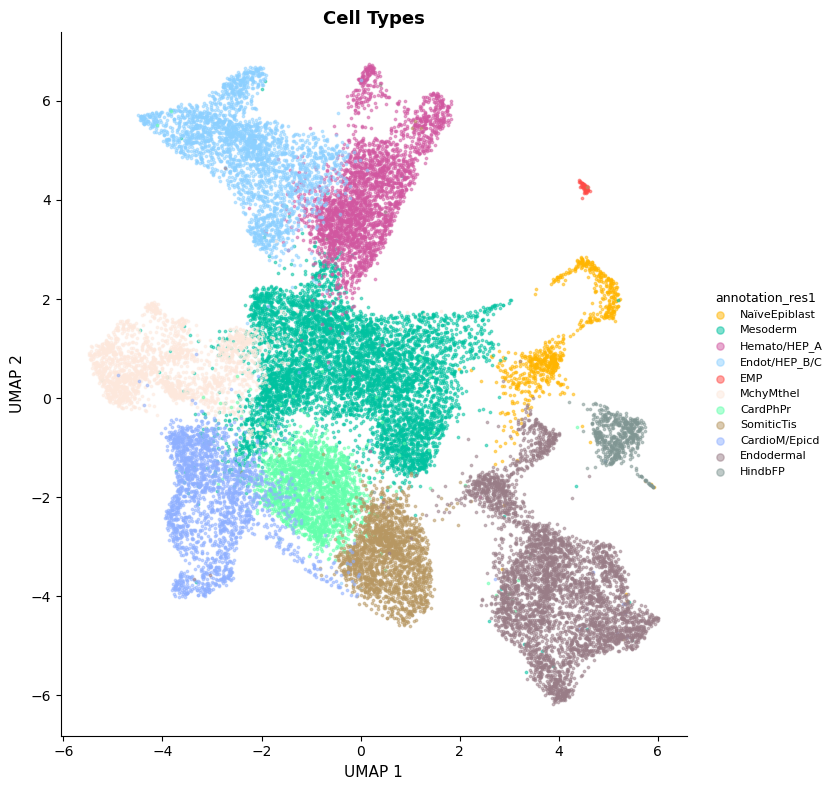

In [22]:
# ==============================================================================
# Section 4b-A1: UMAP — Cell Types
# ==============================================================================
#
# Scatter plot of ALL cells (unfiltered adata_full) coloured by cell type.
# Uses the canonical celltype_order so the legend matches the order used
# in all downstream heatmaps and figures.
#
# Plotting on adata_full (not adata) is intentional: it shows the full
# dataset context so the reader can see where filtered-out cells sit in
# embedding space.
#
# ==============================================================================

# Re-extract for cell independence (same value as Section 4a1)
annot_col = params['annotation_resolution']

fig, ax = plt.subplots(figsize=(10, 8))

# Plot each cell type in canonical order so the legend matches
# the ordering used in heatmaps and other figures.
for ct in celltype_order:
    mask = adata_full.obs[annot_col] == ct
    if mask.sum() == 0:
        continue
    coords = adata_full.obsm[umap_key][mask.values]
    color = celltype_colors.get(ct, '#999999')
    ax.scatter(coords[:, 0], coords[:, 1],
               c=color, s=3, alpha=0.5, label=ct, rasterized=True)

# Legend outside the plot area to avoid occluding data
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5),
          fontsize=8, markerscale=3, frameon=False,
          title=annot_col, title_fontsize=9)
ax.set_xlabel('UMAP 1', fontsize=11)
ax.set_ylabel('UMAP 2', fontsize=11)
ax.set_title('Cell Types', fontsize=13, fontweight='bold')
ax.set_aspect('equal')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()

base = os.path.join(desc_fig_dir, 'umap_celltypes')
_save_multiformat(fig, base)
plt.show()

    → /home/ridvan/scRIPT/008_scLTy/scLTy_002/scLTy_002_part01/D457_res1_Q50u_filtered_all/figures/umap_conditions.png
    → /home/ridvan/scRIPT/008_scLTy/scLTy_002/scLTy_002_part01/D457_res1_Q50u_filtered_all/figures/umap_conditions.svg
    → /home/ridvan/scRIPT/008_scLTy/scLTy_002/scLTy_002_part01/D457_res1_Q50u_filtered_all/figures/umap_conditions.pdf


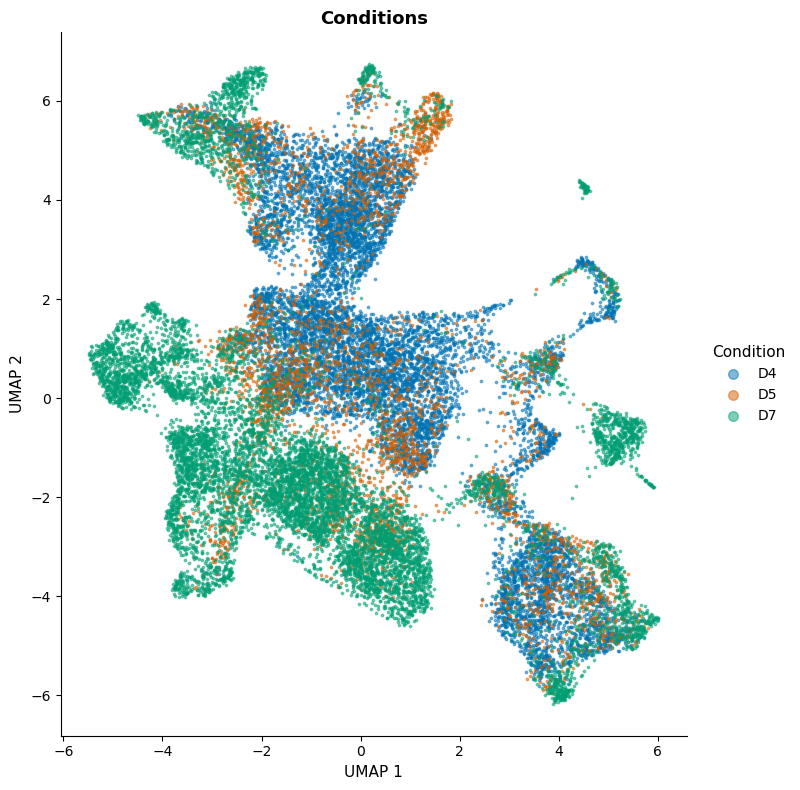

In [23]:
# ==============================================================================
# Section 4b-A2: UMAP — Conditions
# ==============================================================================
#
# Scatter plot of ALL cells (unfiltered adata_full) coloured by
# experimental condition (collection day: D4, D5, D7).
#
# ==============================================================================

# Re-extract for cell independence
condition_col = params["condition_col"]

# Read condition order from params (was hardcoded as ["D4", "D5", "D7"])
conditions_ordered = params["condition"]                    # see REVIEW NOTE 1

fig, ax = plt.subplots(figsize=(10, 8))

# Plot each condition in the order specified in params
for cond in conditions_ordered:
    mask = adata_full.obs[condition_col] == cond
    if mask.sum() == 0:
        continue
    coords = adata_full.obsm[umap_key][mask.values]
    color = condition_colors.get(cond, "#999999")
    ax.scatter(coords[:, 0], coords[:, 1],
               c=color, s=3, alpha=0.5, label=cond, rasterized=True)

ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5),
          fontsize=10, markerscale=4, frameon=False,
          title="Condition", title_fontsize=11)
ax.set_xlabel("UMAP 1", fontsize=11)
ax.set_ylabel("UMAP 2", fontsize=11)
ax.set_title("Conditions", fontsize=13, fontweight="bold")
ax.set_aspect("equal")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()

base = os.path.join(desc_fig_dir, "umap_conditions")
_save_multiformat(fig, base)
plt.show()

    → /home/ridvan/scRIPT/008_scLTy/scLTy_002/scLTy_002_part01/D457_res1_Q50u_filtered_all/figures/umap_barcode_coverage.png
    → /home/ridvan/scRIPT/008_scLTy/scLTy_002/scLTy_002_part01/D457_res1_Q50u_filtered_all/figures/umap_barcode_coverage.svg
    → /home/ridvan/scRIPT/008_scLTy/scLTy_002/scLTy_002_part01/D457_res1_Q50u_filtered_all/figures/umap_barcode_coverage.pdf


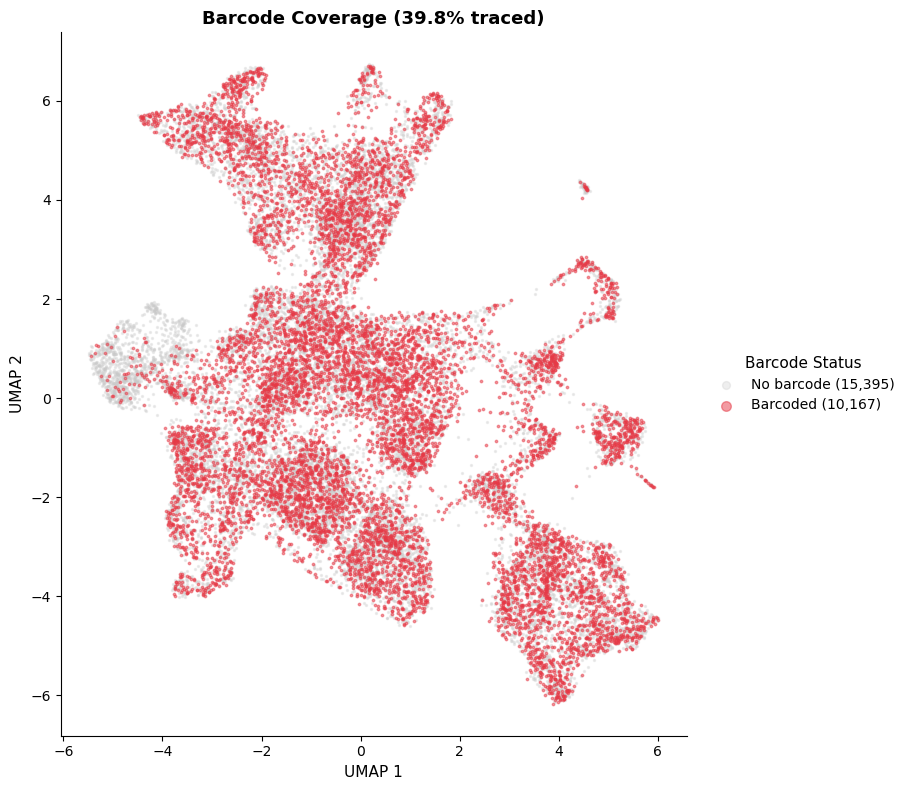

In [24]:
# ==============================================================================
# Section 4b-A3: UMAP — Barcode Coverage
# ==============================================================================
#
# Shows which cells in the FULL (unfiltered) dataset have valid CRISPR
# barcodes (lineage-traced) versus untraced cells.
#
# Grey background  = cells without a valid barcode (untraced)
# Red foreground   = cells with a valid barcode (lineage-traced)
#
# The barcode validity check uses the same logic as the filtering
# pipeline (Section 3a): real NaN + string representations from the
# shared _INVALID_BARCODE_STRINGS constant (Section 2c).  This ensures
# the coverage percentage shown in the title matches the filtering
# step 3 statistics exactly.
#
# ==============================================================================

# Which column contains the CRISPR barcode (clone ID)
lineage_col = params['lineage_data']

# Build a boolean mask: True = cell has a valid barcode
# Step 1: not NaN (pandas native missing)
has_barcode = adata_full.obs[lineage_col].notna()
# Step 2: not a string placeholder for missing ('NA', 'nan', '', etc.)
if _is_string_like_dtype(adata_full.obs[lineage_col]):
    has_barcode = has_barcode & ~adata_full.obs[lineage_col].isin(_INVALID_BARCODE_STRINGS)

fig, ax = plt.subplots(figsize=(10, 8))

# Plot non-barcoded cells first (grey background layer)
coords_no = adata_full.obsm[umap_key][~has_barcode.values]
n_no = (~has_barcode).sum()
ax.scatter(coords_no[:, 0], coords_no[:, 1],
           c='#c9c9c9', s=2, alpha=0.3, label=f'No barcode ({n_no:,})',
           rasterized=True)

# Plot barcoded cells on top (red foreground layer)
coords_yes = adata_full.obsm[umap_key][has_barcode.values]
n_yes = has_barcode.sum()
ax.scatter(coords_yes[:, 0], coords_yes[:, 1],
           c='#E63946', s=3, alpha=0.5, label=f'Barcoded ({n_yes:,})',
           rasterized=True)

ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5),
          fontsize=10, markerscale=4, frameon=False,
          title='Barcode Status', title_fontsize=11)
ax.set_xlabel('UMAP 1', fontsize=11)
ax.set_ylabel('UMAP 2', fontsize=11)
pct_traced = 100 * has_barcode.mean()
ax.set_title(f'Barcode Coverage ({pct_traced:.1f}% traced)',
             fontsize=13, fontweight='bold')
ax.set_aspect('equal')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()

base = os.path.join(desc_fig_dir, 'umap_barcode_coverage')
_save_multiformat(fig, base)
plt.show()

    → /home/ridvan/scRIPT/008_scLTy/scLTy_002/scLTy_002_part01/D457_res1_Q50u_filtered_all/figures/umap_filtered_cells.png
    → /home/ridvan/scRIPT/008_scLTy/scLTy_002/scLTy_002_part01/D457_res1_Q50u_filtered_all/figures/umap_filtered_cells.svg
    → /home/ridvan/scRIPT/008_scLTy/scLTy_002/scLTy_002_part01/D457_res1_Q50u_filtered_all/figures/umap_filtered_cells.pdf


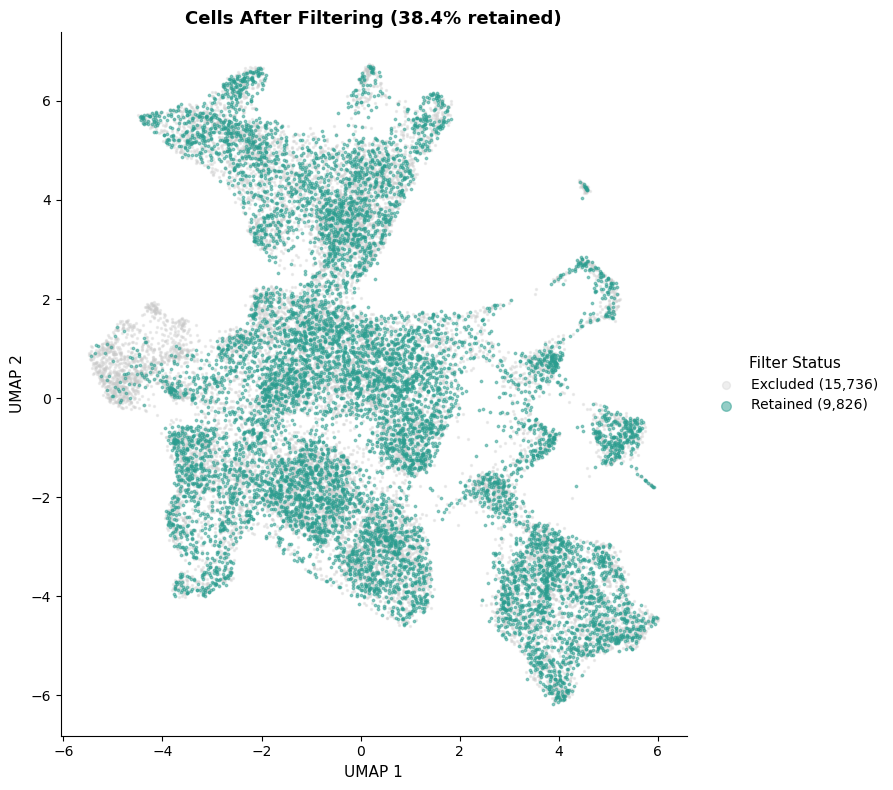

In [25]:
# ==============================================================================
# Section 4b-A4: UMAP — Filtered Cells Overlay
# ==============================================================================
#
# Shows which cells from the full dataset survive the complete filtering
# pipeline (Sections 3a–3b): condition selection, trajectory filter,
# barcode validity, clone size threshold, and cell type coverage.
#
# Grey background  = cells excluded by any filter step
# Teal foreground  = cells retained in the analysis dataset (adata)
#
# The matching uses cell indices (adata.obs.index), which are unique
# identifiers preserved through AnnData subsetting.
#
# ==============================================================================

# Build a set of cell indices that survived filtering
filtered_barcodes = set(adata.obs.index)

# Boolean mask on adata_full: True = cell is in the filtered dataset
is_filtered = adata_full.obs.index.isin(filtered_barcodes)

fig, ax = plt.subplots(figsize=(10, 8))

# Background: all cells NOT in the filtered set (grey)
coords_out = adata_full.obsm[umap_key][~is_filtered]
ax.scatter(coords_out[:, 0], coords_out[:, 1],
           c='#c9c9c9', s=2, alpha=0.3,
           label=f'Excluded ({(~is_filtered).sum():,})',
           rasterized=True)

# Foreground: cells that passed all filters (teal)
coords_in = adata_full.obsm[umap_key][is_filtered]
ax.scatter(coords_in[:, 0], coords_in[:, 1],
           c='#2A9D8F', s=3, alpha=0.5,
           label=f'Retained ({is_filtered.sum():,})',
           rasterized=True)

ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5),
          fontsize=10, markerscale=4, frameon=False,
          title='Filter Status', title_fontsize=11)
ax.set_xlabel('UMAP 1', fontsize=11)
ax.set_ylabel('UMAP 2', fontsize=11)
ax.set_title(f'Cells After Filtering ({100*is_filtered.mean():.1f}% retained)',
             fontsize=13, fontweight='bold')
ax.set_aspect('equal')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()

base = os.path.join(desc_fig_dir, 'umap_filtered_cells')
_save_multiformat(fig, base)
plt.show()

    → /home/ridvan/scRIPT/008_scLTy/scLTy_002/scLTy_002_part01/D457_res1_Q50u_filtered_all/figures/umap_multipanel_overview.png
    → /home/ridvan/scRIPT/008_scLTy/scLTy_002/scLTy_002_part01/D457_res1_Q50u_filtered_all/figures/umap_multipanel_overview.svg
    → /home/ridvan/scRIPT/008_scLTy/scLTy_002/scLTy_002_part01/D457_res1_Q50u_filtered_all/figures/umap_multipanel_overview.pdf


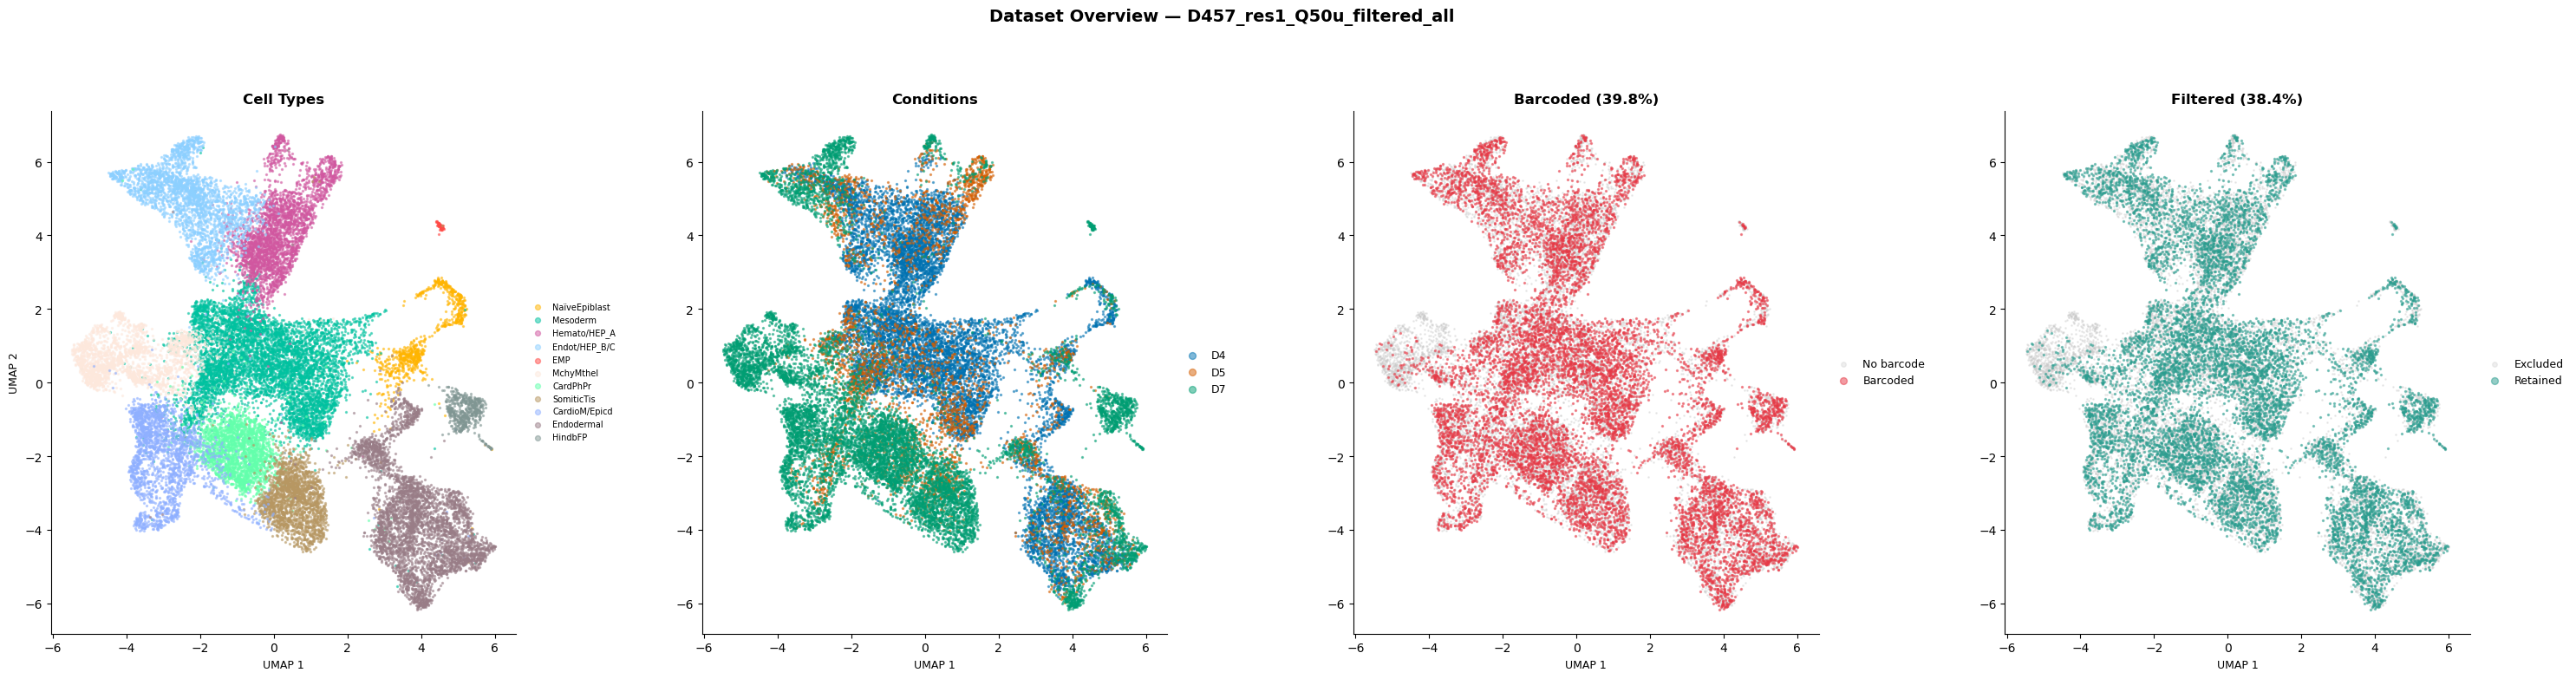

In [27]:
# ==============================================================================
# Section 4b-A5: Multi-Panel UMAP Summary
# ==============================================================================
#
# Combines the four individual UMAP plots (A1–A4) into a single
# four-panel figure for manuscript overview or presentation.
#
# Panels:
#   1. Cell types          (same as Section 4b-A1)
#   2. Conditions          (same as Section 4b-A2)
#   3. Barcode coverage    (same as Section 4b-A3)
#   4. Filtered cells      (same as Section 4b-A4)
#
# Dependencies:
#   - celltype_order, celltype_colors, condition_colors  (Section 4b0)
#   - conditions_ordered  (Section 4b-A2, now reads from params)
#   - has_barcode          (Section 4b-A3)
#   - is_filtered          (Section 4b-A4)
#
# ==============================================================================

fig, axes = plt.subplots(1, 4, figsize=(36, 8))

# ── Panel 1: Cell types ──────────────────────────────────────────────────────
ax = axes[0]
for ct in celltype_order:
    mask = adata_full.obs[annot_col] == ct
    if mask.sum() == 0:
        continue
    coords = adata_full.obsm[umap_key][mask.values]
    ax.scatter(coords[:, 0], coords[:, 1],
               c=celltype_colors.get(ct, '#999999'), s=2, alpha=0.5,
               label=ct, rasterized=True)
ax.legend(fontsize=7, markerscale=3, frameon=False,
          bbox_to_anchor=(1.02, 0.5), loc='center left', borderaxespad=0)
ax.set_title('Cell Types', fontsize=12, fontweight='bold')
ax.set_xlabel('UMAP 1', fontsize=9)
ax.set_ylabel('UMAP 2', fontsize=9)
ax.set_aspect('equal')

# ── Panel 2: Conditions ──────────────────────────────────────────────────────
ax = axes[1]
for cond in conditions_ordered:     # set in Section 4b-A2 from params['condition']
    mask = adata_full.obs[condition_col] == cond
    if mask.sum() == 0:
        continue
    coords = adata_full.obsm[umap_key][mask.values]
    ax.scatter(coords[:, 0], coords[:, 1],
               c=condition_colors.get(cond, '#999999'), s=2, alpha=0.5,
               label=cond, rasterized=True)
ax.legend(fontsize=9, markerscale=4, frameon=False,
          bbox_to_anchor=(1.02, 0.5), loc='center left', borderaxespad=0)
ax.set_title('Conditions', fontsize=12, fontweight='bold')
ax.set_xlabel('UMAP 1', fontsize=9)
ax.set_aspect('equal')

# ── Panel 3: Barcode coverage ────────────────────────────────────────────────
# Uses has_barcode from Section 4b-A3
ax = axes[2]
coords_no = adata_full.obsm[umap_key][~has_barcode.values]
ax.scatter(coords_no[:, 0], coords_no[:, 1], c='#c9c9c9', s=1, alpha=0.3,
           label='No barcode', rasterized=True)
coords_yes = adata_full.obsm[umap_key][has_barcode.values]
ax.scatter(coords_yes[:, 0], coords_yes[:, 1], c='#E63946', s=2, alpha=0.5,
           label='Barcoded', rasterized=True)
ax.legend(fontsize=9, markerscale=4, frameon=False,
          bbox_to_anchor=(1.02, 0.5), loc='center left', borderaxespad=0)
ax.set_title(f'Barcoded ({100*has_barcode.mean():.1f}%)', fontsize=12, fontweight='bold')
ax.set_xlabel('UMAP 1', fontsize=9)
ax.set_aspect('equal')

# ── Panel 4: Filtered cells ──────────────────────────────────────────────────
# Uses is_filtered from Section 4b-A4
ax = axes[3]
coords_out = adata_full.obsm[umap_key][~is_filtered]
ax.scatter(coords_out[:, 0], coords_out[:, 1], c='#c9c9c9', s=1, alpha=0.3,
           label='Excluded', rasterized=True)
coords_in = adata_full.obsm[umap_key][is_filtered]
ax.scatter(coords_in[:, 0], coords_in[:, 1], c='#2A9D8F', s=2, alpha=0.5,
           label='Retained', rasterized=True)
ax.legend(fontsize=9, markerscale=4, frameon=False,
          bbox_to_anchor=(1.02, 0.5), loc='center left', borderaxespad=0)
ax.set_title(f'Filtered ({100*is_filtered.mean():.1f}%)', fontsize=12, fontweight='bold')
ax.set_xlabel('UMAP 1', fontsize=9)
ax.set_aspect('equal')

# ── Shared formatting ────────────────────────────────────────────────────────
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle(f'Dataset Overview — {params["runid"]}', fontsize=14, fontweight='bold', y=1.02)
fig.subplots_adjust(wspace=0.4)

base = os.path.join(desc_fig_dir, 'umap_multipanel_overview')
_save_multiformat(fig, base)
plt.show()

    → /home/ridvan/scRIPT/008_scLTy/scLTy_002/scLTy_002_part01/D457_res1_Q50u_filtered_all/figures/barplot_cellcounts.png
    → /home/ridvan/scRIPT/008_scLTy/scLTy_002/scLTy_002_part01/D457_res1_Q50u_filtered_all/figures/barplot_cellcounts.svg
    → /home/ridvan/scRIPT/008_scLTy/scLTy_002/scLTy_002_part01/D457_res1_Q50u_filtered_all/figures/barplot_cellcounts.pdf


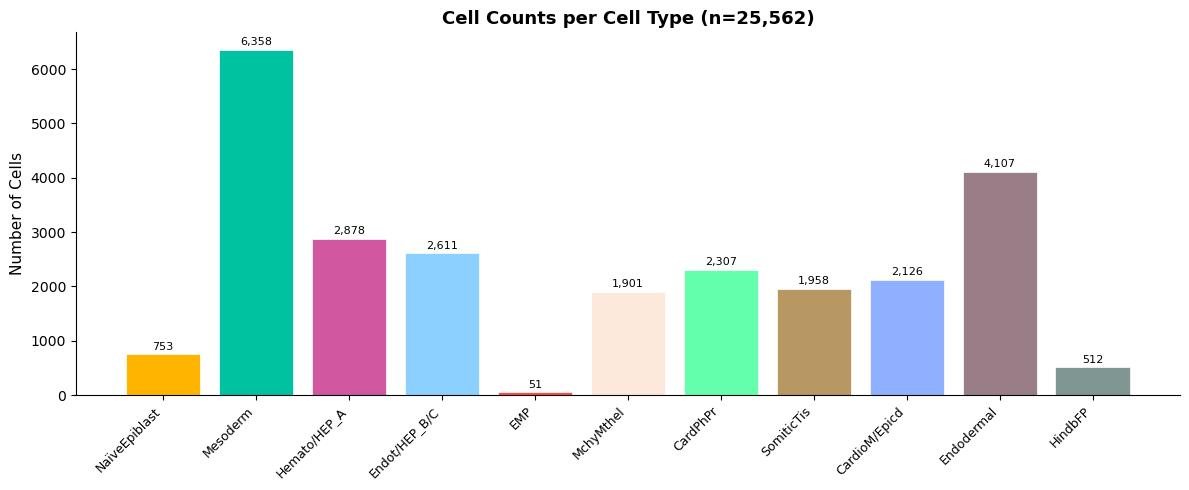

In [29]:
# ==============================================================================
# Section 4b-B1: Cell Count Barplot per Cell Type
# ==============================================================================
#
# Bar chart showing the number of cells per cell type in the FULL
# (unfiltered) dataset, ordered by the canonical celltype_order.
#
# Uses adata_full (not adata) to show the complete picture before
# filtering.  Count labels are placed above each bar.
#
# ==============================================================================

fig, ax = plt.subplots(figsize=(12, 5))

# Count cells per cell type in the unfiltered dataset
counts_full = adata_full.obs[annot_col].value_counts()
counts_ordered = [counts_full.get(ct, 0) for ct in celltype_order]
colors_ordered = [celltype_colors.get(ct, '#999999') for ct in celltype_order]

bars = ax.bar(range(len(celltype_order)), counts_ordered, color=colors_ordered,
              edgecolor='white', linewidth=0.5)

# Add count labels above each bar
for i, (bar, count) in enumerate(zip(bars, counts_ordered)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{count:,}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(range(len(celltype_order)))
ax.set_xticklabels(celltype_order, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Number of Cells', fontsize=11)
ax.set_title(f'Cell Counts per Cell Type (n={adata_full.n_obs:,})',
             fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()

base = os.path.join(desc_fig_dir, 'barplot_cellcounts')
_save_multiformat(fig, base)
plt.show()

    → /home/ridvan/scRIPT/008_scLTy/scLTy_002/scLTy_002_part01/D457_res1_Q50u_filtered_all/figures/barplot_stacked_allcells.png
    → /home/ridvan/scRIPT/008_scLTy/scLTy_002/scLTy_002_part01/D457_res1_Q50u_filtered_all/figures/barplot_stacked_allcells.svg
    → /home/ridvan/scRIPT/008_scLTy/scLTy_002/scLTy_002_part01/D457_res1_Q50u_filtered_all/figures/barplot_stacked_allcells.pdf


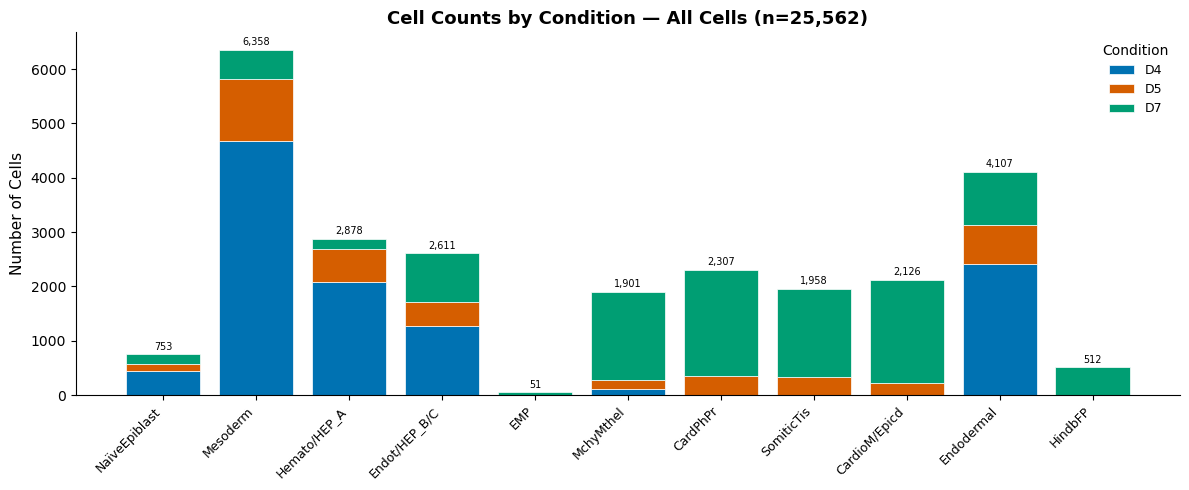

(<Figure size 1200x500 with 1 Axes>,
 <Axes: title={'center': 'Cell Counts by Condition — All Cells (n=25,562)'}, ylabel='Number of Cells'>)

In [31]:
# ==============================================================================
# Section 4b-B2: Stacked Barplot — Cell Counts per Cell Type × Condition
#                (All Cells)
# ==============================================================================
#
# Stacked bar chart showing cell counts per cell type, with conditions
# (D4, D5, D7) stacked within each bar.  Uses the FULL unfiltered
# dataset (adata_full) to show the complete picture.
#
# Defines a reusable function plot_stacked_barplot() that is called
# again in Section 4b-B3 for the filtered dataset.
#
# ==============================================================================


def plot_stacked_barplot(obs_df, annot_col, condition_col, celltype_order,
                         conditions_ordered, condition_colors, title,
                         figsize=(12, 5), save_path=None):
    """
    Stacked barplot: cell types on x-axis, conditions stacked.

    Parameters
    ----------
    obs_df : pd.DataFrame
        adata.obs (or adata_full.obs).
    annot_col : str
        Column name for cell type annotations.
    condition_col : str
        Column name for experimental conditions.
    celltype_order : list of str
        Canonical ordering of cell types for the x-axis.
    conditions_ordered : list of str
        Ordering of conditions for the stacking (bottom to top).
    condition_colors : dict
        Mapping condition name -> hex colour string.
    title : str
        Figure title.
    figsize : tuple, default (12, 5)
        Figure dimensions (width, height) in inches.
    save_path : str or None
        If provided, save the figure via _save_multiformat().
        Can include or omit a file extension (handled by
        _save_multiformat).

    Returns
    -------
    fig, ax : matplotlib Figure and Axes
    """
    # Cross-tabulate cell counts: rows = cell types, columns = conditions
    ct = pd.crosstab(obs_df[annot_col], obs_df[condition_col])
    ct = ct.reindex(index=celltype_order, columns=conditions_ordered, fill_value=0)

    fig, ax = plt.subplots(figsize=figsize)

    # Stack conditions bottom-to-top in the order given
    bottom = np.zeros(len(celltype_order))
    for cond in conditions_ordered:
        values = ct[cond].values
        color = condition_colors.get(cond, '#999999')
        ax.bar(range(len(celltype_order)), values, bottom=bottom,
               color=color, edgecolor='white', linewidth=0.5, label=cond)
        bottom += values

    # Total count labels above each stacked bar
    totals = ct.sum(axis=1).values
    for i, total in enumerate(totals):
        ax.text(i, total + 50, f'{total:,}', ha='center', va='bottom', fontsize=7)

    ax.set_xticks(range(len(celltype_order)))
    ax.set_xticklabels(celltype_order, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Number of Cells', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(title='Condition', frameon=False, fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()

    if save_path:
        _save_multiformat(fig, save_path)       # extension-stripping now internal

    plt.show()
    return fig, ax


# ── Plot: all cells (unfiltered) ─────────────────────────────────────────────
plot_stacked_barplot(
    adata_full.obs, annot_col, condition_col, celltype_order,
    conditions_ordered, condition_colors,
    title=f'Cell Counts by Condition — All Cells (n={adata_full.n_obs:,})',
    save_path=os.path.join(desc_fig_dir, 'barplot_stacked_allcells'),
)

    → /home/ridvan/scRIPT/008_scLTy/scLTy_002/scLTy_002_part01/D457_res1_Q50u_filtered_all/figures/barplot_stacked_filtered.png
    → /home/ridvan/scRIPT/008_scLTy/scLTy_002/scLTy_002_part01/D457_res1_Q50u_filtered_all/figures/barplot_stacked_filtered.svg
    → /home/ridvan/scRIPT/008_scLTy/scLTy_002/scLTy_002_part01/D457_res1_Q50u_filtered_all/figures/barplot_stacked_filtered.pdf


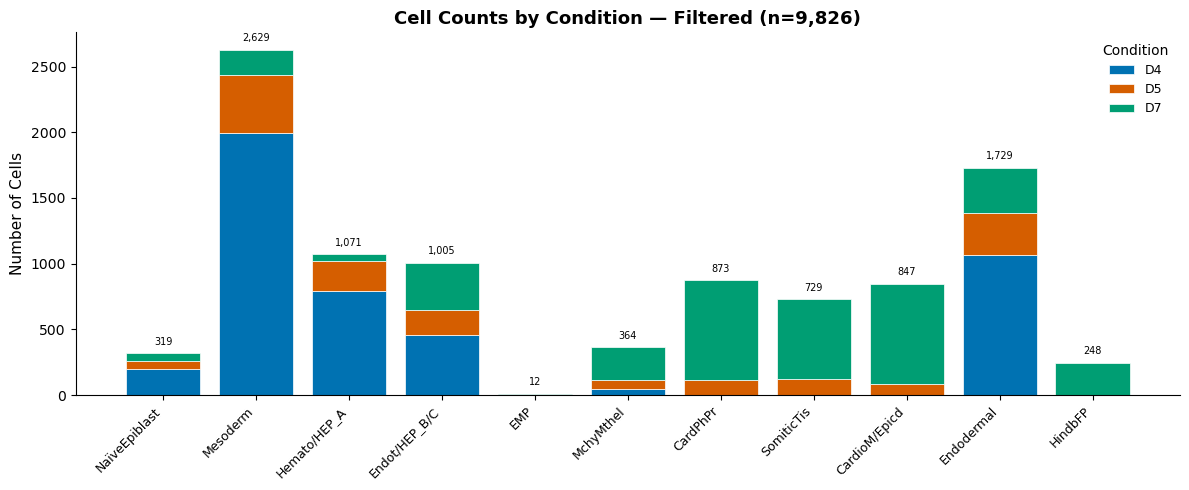

(<Figure size 1200x500 with 1 Axes>,
 <Axes: title={'center': 'Cell Counts by Condition — Filtered (n=9,826)'}, ylabel='Number of Cells'>)

In [32]:
# ==============================================================================
# Section 4b-B3: Stacked Barplot — Filtered Cells Only
# ==============================================================================
#
# Same stacked bar chart as Section 4b-B2, but using the filtered
# dataset (adata).  Comparing this side-by-side with 4b-B2 shows
# which cell types lost the most cells during filtering and whether
# the condition composition shifted.
#
# ==============================================================================

plot_stacked_barplot(
    adata.obs, annot_col, condition_col, celltype_order,
    conditions_ordered, condition_colors,
    title=f'Cell Counts by Condition — Filtered (n={adata.n_obs:,})',
    save_path=os.path.join(desc_fig_dir, 'barplot_stacked_filtered'),
)

    → /home/ridvan/scRIPT/008_scLTy/scLTy_002/scLTy_002_part01/D457_res1_Q50u_filtered_all/figures/barcode_coverage_per_celltype.png
    → /home/ridvan/scRIPT/008_scLTy/scLTy_002/scLTy_002_part01/D457_res1_Q50u_filtered_all/figures/barcode_coverage_per_celltype.svg
    → /home/ridvan/scRIPT/008_scLTy/scLTy_002/scLTy_002_part01/D457_res1_Q50u_filtered_all/figures/barcode_coverage_per_celltype.pdf


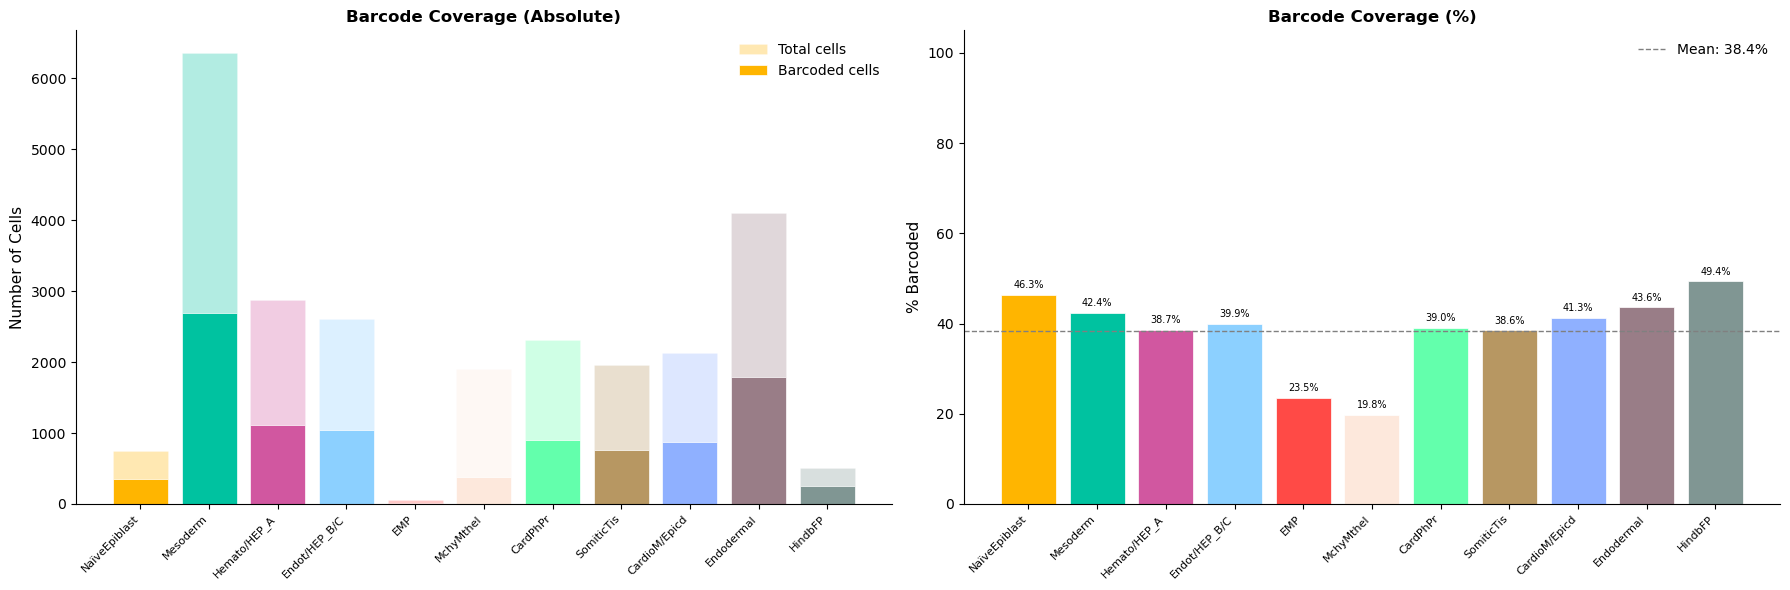

In [34]:
# ==============================================================================
# Section 4b-B4: Barcode Coverage per Cell Type (Unfiltered Dataset)
# ==============================================================================
#
# Two-panel figure showing barcode coverage per cell type in the
# FULL (unfiltered) dataset:
#   Panel 1: Absolute counts (total cells vs barcoded cells)
#   Panel 2: Percentage barcoded per cell type, with mean line
#
# ==============================================================================

lineage_col = params['lineage_data']

# ── Compute per-cell-type barcode coverage (unfiltered) ──────────────────────
# Reuse the has_barcode mask from Section 4b-A3, which correctly handles
# both real NaN and string representations of missing barcodes.
coverage_full = []
for ct in celltype_order:
    mask_ct = adata_full.obs[annot_col] == ct
    n_total = mask_ct.sum()
    # has_barcode was computed in Section 4b-A3 with full invalid checks
    n_barcoded = (has_barcode & mask_ct).sum()
    coverage_full.append({
        'celltype':   ct,
        'n_total':    n_total,
        'n_barcoded': n_barcoded,
        'pct':        100 * n_barcoded / n_total if n_total > 0 else 0,
    })
df_cov = pd.DataFrame(coverage_full)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# ── Panel 1: Absolute counts ─────────────────────────────────────────────────
# Light bars = total cells, solid bars = barcoded cells
x = range(len(celltype_order))
colors_ct = [celltype_colors.get(ct, '#999999') for ct in celltype_order]

ax1.bar(x, df_cov['n_total'], color=colors_ct, alpha=0.3, edgecolor='white',
        linewidth=0.5, label='Total cells')
ax1.bar(x, df_cov['n_barcoded'], color=colors_ct, edgecolor='white',
        linewidth=0.5, label='Barcoded cells')
ax1.set_xticks(x)
ax1.set_xticklabels(celltype_order, rotation=45, ha='right', fontsize=8)
ax1.set_ylabel('Number of Cells', fontsize=11)
ax1.set_title('Barcode Coverage (Absolute)', fontsize=12, fontweight='bold')
ax1.legend(frameon=False)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ── Panel 2: Percentage barcoded ─────────────────────────────────────────────
bars = ax2.bar(x, df_cov['pct'], color=colors_ct, edgecolor='white', linewidth=0.5)
for i, (bar, pct) in enumerate(zip(bars, df_cov['pct'])):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{pct:.1f}%', ha='center', va='bottom', fontsize=7)

# Dashed horizontal line at the mean coverage across cell types
ax2.axhline(y=df_cov['pct'].mean(), color='gray', linestyle='--', linewidth=1,
            label=f'Mean: {df_cov["pct"].mean():.1f}%')
ax2.set_xticks(x)
ax2.set_xticklabels(celltype_order, rotation=45, ha='right', fontsize=8)
ax2.set_ylabel('% Barcoded', fontsize=11)
ax2.set_title('Barcode Coverage (%)', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 105)
ax2.legend(frameon=False)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()

base = os.path.join(desc_fig_dir, 'barcode_coverage_per_celltype')
_save_multiformat(fig, base)
plt.show()

In [ ]:
# ==============================================================================
# 4b-C1: Barcode Heatmap Implementation
# ==============================================================================

from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist
from matplotlib.gridspec import GridSpec

def plot_barcode_heatmap(obs_df, annot_col, lineage_col, celltype_order,
                         celltype_colors, title, normalize=True,
                         min_clone_size=1, figsize=(10, 12),
                         save_path=None, max_clones_display=500):
    """
    Plot barcode heatmap: clones (rows) × cell types (columns).

    Clones are ordered by dominant cell type (block-diagonal structure),
    then by hierarchical clustering within each block.
    """
    # ── Filter to cells with valid barcodes ───────────────────────────────────
    df = obs_df[[annot_col, lineage_col]].dropna(subset=[lineage_col]).copy()

    if len(df) == 0:
        print(f"  No barcoded cells found")
        return None, None, 0

    # ── Filter by clone size ──────────────────────────────────────────────────
    clone_sizes = df[lineage_col].value_counts()
    valid_clones = clone_sizes[clone_sizes >= min_clone_size].index
    df = df[df[lineage_col].isin(valid_clones)]

    if len(df) == 0:
        print(f"  No clones with ≥{min_clone_size} cells")
        return None, None, 0

    # ── Build clone × celltype matrix ─────────────────────────────────────────
    ct_matrix = pd.crosstab(df[lineage_col], df[annot_col])
    ct_present = [ct for ct in celltype_order if ct in ct_matrix.columns]
    ct_matrix = ct_matrix.reindex(columns=ct_present, fill_value=0)

    n_clones = len(ct_matrix)

    # ── Normalize rows if requested ───────────────────────────────────────────
    mat_raw = ct_matrix.values.astype(np.float64)
    if normalize:
        row_sums = mat_raw.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1  # avoid division by zero
        mat = mat_raw / row_sums
    else:
        mat = mat_raw

    # ── Order clones: group by dominant cell type, then sort within group ─────
    # For each clone, find the cell type with highest contribution
    dominant_ct_idx = np.argmax(mat, axis=1)
    # Secondary sort: fraction in dominant cell type (descending)
    dominant_ct_val = np.max(mat, axis=1)

    # Build sort key: primary = cell type index (follows celltype_order),
    # secondary = -fraction (so highest fraction first within group)
    sort_keys = np.column_stack([dominant_ct_idx, -dominant_ct_val])
    clone_order = np.lexsort((sort_keys[:, 1], sort_keys[:, 0]))

    mat_ordered = mat[clone_order]

    # ── Subsample if too many clones ──────────────────────────────────────────
    display_note = ''
    if n_clones > max_clones_display:
        step = max(1, n_clones // max_clones_display)
        mat_display = mat_ordered[::step]
        display_note = f' (showing {len(mat_display)}/{n_clones})'
    else:
        mat_display = mat_ordered

    # ── Plot with GridSpec: dedicated colorbar column for alignment ───────────
    # Using GridSpec ensures the color bar row and heatmap share the same
    # column width — the legend colorbar gets its own column so it doesn't
    # steal space from ax_main (which would misalign ax_color above it).
    fig = plt.figure(figsize=figsize)
    gs = GridSpec(2, 2, figure=fig,
                  width_ratios=[40, 1],
                  height_ratios=[1, 40],
                  hspace=0.02, wspace=0.05)

    ax_color = fig.add_subplot(gs[0, 0])
    ax_main  = fig.add_subplot(gs[1, 0])
    ax_cbar  = fig.add_subplot(gs[1, 1])

    # Hide the unused top-right cell
    ax_empty = fig.add_subplot(gs[0, 1])
    ax_empty.axis('off')

    cmap = 'YlOrRd'
    vmax = 1.0 if normalize else mat_display.max()

    # ── Color indicator bar (top) ─────────────────────────────────────────────
    color_bar_data = np.arange(len(ct_present)).reshape(1, -1)
    ct_cmap_colors = [celltype_colors.get(ct, '#999999') for ct in ct_present]
    ct_cmap = colors.ListedColormap(ct_cmap_colors)

    ax_color.imshow(color_bar_data, cmap=ct_cmap, aspect='auto',
                    interpolation='none')
    ax_color.set_xticks(range(len(ct_present)))
    ax_color.set_xticklabels(ct_present, rotation=45, ha='left', fontsize=9)
    ax_color.xaxis.set_ticks_position('top')
    ax_color.set_yticks([])
    ax_color.tick_params(length=0)

    # ── Main heatmap ──────────────────────────────────────────────────────────
    im = ax_main.imshow(mat_display, aspect='auto', cmap=cmap, vmin=0, vmax=vmax,
                        interpolation='none')

    # Colorbar in dedicated axis (doesn't steal space from ax_main)
    cbar = fig.colorbar(im, cax=ax_cbar)
    cbar.set_label('Fraction of clone' if normalize else 'Cell count', fontsize=10)

    ax_main.set_xticks(range(len(ct_present)))
    ax_main.set_xticklabels([])  # Labels already on top via color bar
    ax_main.set_ylabel(f'Clones (n={n_clones:,}){display_note}', fontsize=11)
    ax_main.set_yticks([])

    # ── Add block boundary lines ──────────────────────────────────────────────
    # Show where dominant cell type changes in the ordered clone list
    dominant_ordered = dominant_ct_idx[clone_order]
    if n_clones <= max_clones_display:
        for i in range(1, len(dominant_ordered)):
            if dominant_ordered[i] != dominant_ordered[i-1]:
                ax_main.axhline(y=i - 0.5, color='white', linewidth=0.5, alpha=0.8)

    fig.suptitle(title, fontsize=13, fontweight='bold', y=0.98)

    if save_path:
        for ext in ['.png', '.svg', '.pdf']:
            if save_path.endswith(ext):
                save_path = save_path[:-len(ext)]
                break
        _save_multiformat(fig, save_path)

    plt.show()
    return fig, ax_main, n_clones

In [ ]:
# ==============================================================================
# 4b-C2: Barcode Heatmaps — Three Versions
# ==============================================================================

annot_col = params['annotation_resolution']
lineage_col = params['lineage_data']

# ── 1. All clones, unfiltered (any clone size including singletons) ───────────
print("=" * 60)
print("Barcode Heatmap — All Clones (Unfiltered)")
print("=" * 60)

# Count clones first for title
bc_all = adata_full.obs[lineage_col].dropna()
n_clones_all = bc_all.nunique()

fig, ax, n1 = plot_barcode_heatmap(
    adata_full.obs, annot_col, lineage_col, celltype_order, celltype_colors,
    title=f'Clone × Cell Type — All Clones (n={n_clones_all:,}, unfiltered)',
    normalize=True, min_clone_size=1,
    save_path=os.path.join(desc_fig_dir, 'barcode_heatmap_all_unfiltered'),
)

# ── 2. Clones ≥2 cells, unfiltered ───────────────────────────────────────────
print(f"\n{'=' * 60}")
print("Barcode Heatmap — Clones ≥2 Cells (Unfiltered)")
print("=" * 60)

# Count clones ≥2 for title
clone_sizes_all = bc_all.value_counts()
n_clones_ge2 = (clone_sizes_all >= 2).sum()

fig, ax, n2 = plot_barcode_heatmap(
    adata_full.obs, annot_col, lineage_col, celltype_order, celltype_colors,
    title=f'Clone × Cell Type — Clones ≥2 Cells (n={n_clones_ge2:,}, unfiltered)',
    normalize=True, min_clone_size=2,
    save_path=os.path.join(desc_fig_dir, 'barcode_heatmap_clonesize2_unfiltered'),
)

# ── 3. After our full filtering pipeline ──────────────────────────────────────
print(f"\n{'=' * 60}")
print("Barcode Heatmap — After Filtering")
print("=" * 60)

# Filtered adata already has clone_size ≥ 2 and celltype barcode ≥ 5
n_clones_filt = adata.obs[lineage_col].nunique()

fig, ax, n3 = plot_barcode_heatmap(
    adata.obs, annot_col, lineage_col, celltype_order, celltype_colors,
    title=f'Clone × Cell Type — Filtered (n={n_clones_filt:,} clones, {adata.n_obs:,} cells)',
    normalize=True, min_clone_size=1,  # Already filtered to ≥2 in Section 3
    save_path=os.path.join(desc_fig_dir, 'barcode_heatmap_filtered'),
)

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\n  Clone count progression:")
print(f"    All clones (incl. singletons): {n_clones_all:,}")
print(f"    Clones ≥2 cells (unfiltered):  {n_clones_ge2:,}")
print(f"    After full filtering:          {n_clones_filt:,}")

In [ ]:
# ==============================================================================
# 4b-C3: Clone Size Distribution (Before and After Filtering)
# ==============================================================================
# "Before" = all barcoded cells from the unfiltered dataset (includes singletons).
# "After"  = filtered dataset (clone size ≥2, cell type barcode ≥5).
# ==============================================================================

lineage_col = params['lineage_data']

# ── Clone sizes: unfiltered (all barcoded cells) ─────────────────────────────
bc_full = adata_full.obs[lineage_col].dropna()
sizes_full = bc_full.value_counts().values  # includes singletons

# ── Clone sizes: after filtering ──────────────────────────────────────────────
bc_filt = adata.obs[lineage_col]  # no NaN in filtered adata
sizes_filt = bc_filt.value_counts().values

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

max_size = max(sizes_full.max(), sizes_filt.max())

# ── Panel 1: Histogram (log y-axis, full resolution) ─────────────────────────
ax = axes[0]
bins = np.arange(0.5, max_size + 1.5, 1)  # Full range — no silent truncation

ax.hist(sizes_full, bins=bins, histtype='step', color='#4A90D9', linewidth=1.5,
        label=f'Unfiltered (n={len(sizes_full):,})')
ax.hist(sizes_filt, bins=bins, histtype='step', color='#E63946', linewidth=1.5,
        label=f'Filtered (n={len(sizes_filt):,})')

ax.axvline(x=2, color='black', linestyle='--', linewidth=1, alpha=0.5,
           label='min_clone_size = 2')
ax.set_xlabel('Clone Size (cells)', fontsize=11)
ax.set_ylabel('Number of Clones', fontsize=11)
ax.set_title('Clone Size Distribution', fontsize=12, fontweight='bold')
ax.set_yscale('log')
ax.set_xlim(0, min(max_size + 2, 80))  # Zoom x-axis but nothing is hidden in y
ax.legend(frameon=False, fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ── Panel 2: Cumulative distribution ─────────────────────────────────────────
ax = axes[1]
sorted_full_asc = np.sort(sizes_full)
sorted_filt_asc = np.sort(sizes_filt)

# Fraction of clones with size ≤ x
ax.step(sorted_full_asc, np.arange(1, len(sorted_full_asc) + 1) / len(sorted_full_asc),
        color='#4A90D9', linewidth=2, where='post', label='Unfiltered')
ax.step(sorted_filt_asc, np.arange(1, len(sorted_filt_asc) + 1) / len(sorted_filt_asc),
        color='#E63946', linewidth=2, where='post', label='Filtered')

ax.axvline(x=2, color='black', linestyle='--', linewidth=1, alpha=0.5)

# Annotate key quantiles for unfiltered
for q, ls in [(0.5, ':'), (0.9, '-.')]:
    val = np.percentile(sizes_full, q * 100)
    ax.axhline(y=q, color='grey', linestyle=ls, linewidth=0.8, alpha=0.5)
    ax.text(max_size * 0.95, q + 0.02, f'{int(q*100)}%: size ≤ {val:.0f}',
            ha='right', fontsize=7, color='grey')

ax.set_xlabel('Clone Size (cells)', fontsize=11)
ax.set_ylabel('Cumulative Fraction of Clones', fontsize=11)
ax.set_title('Cumulative Distribution (ECDF)', fontsize=12, fontweight='bold')
ax.set_xscale('log')
ax.set_xlim(0.8, max_size * 1.5)
ax.legend(frameon=False, fontsize=8, loc='lower right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ── Panel 3: Rank plot (clone size vs rank, log-log) ─────────────────────────
ax = axes[2]
sorted_full_desc = np.sort(sizes_full)[::-1]
sorted_filt_desc = np.sort(sizes_filt)[::-1]

ax.plot(range(1, len(sorted_full_desc)+1), sorted_full_desc, color='#4A90D9',
        linewidth=2, label=f'Unfiltered ({len(sorted_full_desc):,})')
ax.plot(range(1, len(sorted_filt_desc)+1), sorted_filt_desc, color='#E63946',
        linewidth=2, label=f'Filtered ({len(sorted_filt_desc):,})')

ax.set_xlabel('Clone Rank', fontsize=11)
ax.set_ylabel('Clone Size (cells)', fontsize=11)
ax.set_title('Clone Size Rank Plot', fontsize=12, fontweight='bold')
ax.set_yscale('log')
ax.set_xscale('log')
ax.grid(True, which='major', alpha=0.2, linewidth=0.5)
ax.legend(frameon=False, fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.suptitle(f'Clone Size Analysis — {params["runid"]}', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout()
base = os.path.join(desc_fig_dir, 'clone_size_distribution')
_save_multiformat(fig, base)
plt.show()

# ── Summary statistics table ──────────────────────────────────────────────────
print(f"\n  Clone size statistics:")
print(f"  {'':>20s} {'Unfiltered':>12s} {'Filtered':>12s}")
print(f"  {'─'*20} {'─'*12} {'─'*12}")
print(f"  {'Total clones':>20s} {len(sizes_full):>12,} {len(sizes_filt):>12,}")
print(f"  {'Total cells':>20s} {sizes_full.sum():>12,} {sizes_filt.sum():>12,}")
print(f"  {'Mean size':>20s} {sizes_full.mean():>12.1f} {sizes_filt.mean():>12.1f}")
print(f"  {'Median size':>20s} {np.median(sizes_full):>12.1f} {np.median(sizes_filt):>12.1f}")
print(f"  {'Max size':>20s} {sizes_full.max():>12d} {sizes_filt.max():>12d}")
print(f"  {'Singletons':>20s} {(sizes_full==1).sum():>12,} {(sizes_filt==1).sum():>12,}")
print(f"  {'Clones ≥2':>20s} {(sizes_full>=2).sum():>12,} {(sizes_filt>=2).sum():>12,}")
print(f"  {'Clones ≥10':>20s} {(sizes_full>=10).sum():>12,} {(sizes_filt>=10).sum():>12,}")

In [ ]:
# ==============================================================================
# Cleanup: Free memory from unfiltered adata
# ==============================================================================
# Keep adata_full available if needed later, but note it uses ~memory.
# Uncomment the next line to free memory if running on limited resources:
# del adata_full

print(f"✓ Section 4b complete — all descriptive plots generated")
print(f"  Figures saved to: {desc_fig_dir}")

# Count saved figures
fig_files = [f for f in os.listdir(desc_fig_dir) if os.path.isfile(os.path.join(desc_fig_dir, f))]
print(f"  Total figure files: {len(fig_files)}")

## Section 5: Clone Matrix Construction

Build the one-hot encoded clone matrix `X_clone` (n_cells × n_clones).  
Each cell is assigned to exactly one clone (one-to-one cell-to-barcode mapping).

This matrix is the foundation for all downstream coupling analyses.

In [ ]:
# ==============================================================================
# Section 5a: Clone Matrix Construction
# ==============================================================================
# Build a one-hot encoded sparse matrix mapping cells to clones.
#
# Key design decisions:
#   - Sparse format (csr_matrix): memory-efficient for ~0.01% density
#   - float64 dtype: prevents integer division truncation in downstream
#     CoSpar operations (known bug with .astype(int))
#   - Vectorized construction: no Python loops over cells
#   - Validation: every cell maps to 0 or 1 clones, no duplicates
#
# The matrix is stored in adata.obsm['X_clone'] for CoSpar compatibility.
# ==============================================================================

def create_clone_matrix(adata, params, verbose=True):
    """
    Create one-hot encoded clone matrix from lineage barcode data.
    
    Each cell has at most one barcode (one-to-one mapping). The resulting
    matrix X_clone has shape (n_cells, n_clones) where X_clone[i, j] = 1.0
    if cell i belongs to clone j, else 0.0.
    
    Parameters
    ----------
    adata : AnnData
        Filtered AnnData object. Must contain the barcode column in .obs.
        All cells are expected to have valid (non-NaN) barcodes — NaN cells
        should have been removed during filtering.
    params : dict
        Configuration dictionary. Required keys:
        - lineage_data: column name in adata.obs containing barcode strings
        - min_clone_size: minimum cells per clone (used for validation)
        - runid: run identifier for logging
    verbose : bool
        Print progress and validation information.
    
    Returns
    -------
    dict with keys:
        'X_clone': scipy.sparse.csr_matrix, shape (n_cells, n_clones), dtype float64
        'clone_names': np.ndarray of clone identifier strings
        'clone_to_idx': dict mapping clone name to column index
        'clone_sizes': pd.Series with clone sizes indexed by clone name
    
    Side effects
    ------------
    Adds to adata:
        - adata.obsm['X_clone']: the sparse clone matrix
        - adata.uns['clone_names']: array of clone identifiers
        - adata.uns['clone_to_idx']: mapping dict
        - adata.uns['n_clones']: number of clones
        - adata.uns['clone_matrix_params']: metadata dict
    
    Raises
    ------
    AssertionError
        If validation checks fail (NaN barcodes found, cells assigned to
        multiple clones, clones below minimum size, etc.)
    """
    barcode_col   = params['lineage_data']
    min_clone_size = params['min_clone_size']
    runid         = params['runid']
    
    if verbose:
        print("=" * 60)
        print(f"Creating Clone Matrix — {runid}")
        print("=" * 60)
        print(f"  Barcode column: '{barcode_col}'")
        print(f"  Min clone size: {min_clone_size}")
    
    # ── Pre-check: all cells should have valid barcodes ───────────────────────
    # (NaN removal should have happened during filtering)
    barcode_values = adata.obs[barcode_col].copy()
    n_cells = len(barcode_values)
    
    n_na = barcode_values.isna().sum()
    n_invalid_str = 0
    if _is_string_like_dtype(barcode_values):
        n_invalid_str = barcode_values.isin(_INVALID_BARCODE_STRINGS).sum()
    
    if n_na > 0 or n_invalid_str > 0:
        raise AssertionError(
            f"Found {n_na} NaN and {n_invalid_str} invalid string barcodes. "
            f"These should have been removed during filtering. "
            f"Do not pass unfiltered adata to this function."
        )
    
    if verbose:
        print(f"\n  ✓ All {n_cells:,} cells have valid barcodes")
    
    # ── Count clones and validate sizes ───────────────────────────────────────
    clone_counts = barcode_values.value_counts()
    n_unique_clones = len(clone_counts)
    
    # Check that all clones meet minimum size
    clones_below_min = clone_counts[clone_counts < min_clone_size]
    if len(clones_below_min) > 0:
        raise AssertionError(
            f"{len(clones_below_min)} clones have fewer than {min_clone_size} cells. "
            f"Clone size filtering should have been applied before this step. "
            f"Offending clones: {clones_below_min.to_dict()}"
        )
    
    if verbose:
        print(f"  ✓ All {n_unique_clones:,} clones have size ≥ {min_clone_size}")
    
    # ── Build clone name mappings ─────────────────────────────────────────────
    # Sort clone names for deterministic column ordering across runs
    clone_names = np.sort(clone_counts.index.values)
    n_clones = len(clone_names)
    clone_to_idx = {clone: idx for idx, clone in enumerate(clone_names)}
    
    if verbose:
        print(f"\n{'─' * 60}")
        print(f"Building Matrix: {n_cells:,} cells × {n_clones:,} clones")
        print(f"{'─' * 60}")
    
    # ── Construct sparse matrix (vectorized — no Python loop) ─────────────────
    # Map each cell's barcode to its column index using pandas .map()
    col_indices = barcode_values.map(clone_to_idx).values.astype(np.int32)
    row_indices = np.arange(n_cells, dtype=np.int32)
    data_values = np.ones(n_cells, dtype=np.float64)
    
    X_clone = csr_matrix(
        (data_values, (row_indices, col_indices)),
        shape=(n_cells, n_clones),
        dtype=np.float64   # CRITICAL: float64 prevents integer division truncation
    )                       # in downstream CoSpar coupling calculations
    
    # ── Validation ────────────────────────────────────────────────────────────
    if verbose:
        print(f"\n{'─' * 60}")
        print(f"Validation")
        print(f"{'─' * 60}")
    
    # Check 1: Every cell should be assigned to exactly 1 clone
    # (since we verified no NaN above and every cell has a valid barcode)
    cells_per_row = np.array(X_clone.sum(axis=1)).flatten()
    n_unassigned = (cells_per_row == 0).sum()
    n_multi = (cells_per_row > 1).sum()
    
    assert n_unassigned == 0, (
        f"{n_unassigned} cells have no clone assignment. "
        f"This should not happen — all cells have valid barcodes."
    )
    assert n_multi == 0, (
        f"{n_multi} cells are assigned to >1 clone. "
        f"One-to-one cell-to-barcode mapping is violated."
    )
    
    if verbose:
        print(f"  ✓ All {n_cells:,} cells assigned to exactly 1 clone")
    
    # Check 2: Every clone should have ≥ min_clone_size cells
    cells_per_clone = np.array(X_clone.sum(axis=0)).flatten()
    assert cells_per_clone.min() >= min_clone_size, (
        f"Clone with {cells_per_clone.min()} cells found in matrix — "
        f"expected minimum {min_clone_size}"
    )
    
    if verbose:
        print(f"  ✓ All {n_clones:,} clones have ≥ {min_clone_size} cells")
    
    # Check 3: Matrix dimensions match expectations
    assert X_clone.shape == (n_cells, n_clones), (
        f"Shape mismatch: got {X_clone.shape}, expected ({n_cells}, {n_clones})"
    )
    
    # Check 4: Total non-zero entries should equal n_cells (one per cell)
    assert X_clone.nnz == n_cells, (
        f"Expected {n_cells} non-zero entries, got {X_clone.nnz}"
    )
    
    if verbose:
        print(f"  ✓ Matrix shape: {X_clone.shape}")
        print(f"  ✓ Non-zero entries: {X_clone.nnz:,} (= n_cells, as expected)")
        print(f"  ✓ Dtype: {X_clone.dtype}")
        density = 100 * X_clone.nnz / (n_cells * n_clones)
        print(f"  ✓ Density: {density:.4f}%")
    
    # Clone size statistics from matrix
    if verbose:
        print(f"\n  Clone size distribution (from matrix):")
        print(f"    Min:    {cells_per_clone.min():.0f}")
        print(f"    Max:    {cells_per_clone.max():.0f}")
        print(f"    Mean:   {cells_per_clone.mean():.1f}")
        print(f"    Median: {np.median(cells_per_clone):.1f}")
    
    # ── Store in adata ────────────────────────────────────────────────────────
    adata.obsm['X_clone'] = X_clone
    adata.uns['clone_names'] = clone_names
    adata.uns['clone_to_idx'] = clone_to_idx
    adata.uns['n_clones'] = n_clones
    adata.uns['clone_source'] = barcode_col
    adata.uns['clone_matrix_params'] = {
        'barcode_col':    barcode_col,
        'min_clone_size': min_clone_size,
        'runid':          runid,
        'n_cells':        n_cells,
        'n_clones':       n_clones,
        'dtype':          str(X_clone.dtype),
        'sparse_format':  type(X_clone).__name__,
        'nnz':            X_clone.nnz,
    }
    
    if verbose:
        print(f"\n{'─' * 60}")
        print(f"Stored in AnnData")
        print(f"{'─' * 60}")
        print(f"  adata.obsm['X_clone']:           {X_clone.shape} ({type(X_clone).__name__}, {X_clone.dtype})")
        print(f"  adata.uns['clone_names']:         {n_clones} clones")
        print(f"  adata.uns['clone_to_idx']:        mapping dict")
        print(f"  adata.uns['n_clones']:            {n_clones}")
        print(f"  adata.uns['clone_matrix_params']:  metadata dict")
        print(f"\n{'=' * 60}")
        print(f"✓ Clone matrix created successfully")
        print(f"{'=' * 60}")
    
    return {
        'X_clone':      X_clone,
        'clone_names':  clone_names,
        'clone_to_idx': clone_to_idx,
        'clone_sizes':  pd.Series(cells_per_clone, index=clone_names),
    }

In [ ]:
# ==============================================================================
# Section 5b: Build Clone Matrix
# ==============================================================================
clone_result = create_clone_matrix(adata, params)

In [ ]:
# ==============================================================================
# Section 5c: Independent Verification of Clone Matrix
# ==============================================================================
# Cross-check the matrix against the raw barcode data in adata.obs.
# This verification uses a completely different code path to confirm
# the matrix was built correctly.
# ==============================================================================

barcode_col = params['lineage_data']
X_clone = adata.obsm['X_clone']
clone_names = adata.uns['clone_names']

print("=" * 60)
print("Independent Verification")
print("=" * 60)

errors = []

# ── Test 1: Pick random cells and verify their clone assignment ───────────────
np.random.seed(params['random_seed'])
n_test = min(100, adata.n_obs)
test_indices = np.random.choice(adata.n_obs, size=n_test, replace=False)

for idx in test_indices:
    barcode = adata.obs[barcode_col].iloc[idx]
    
    # From matrix: which clone is this cell assigned to?
    row = X_clone[idx]
    if sparse.issparse(row):
        row = row.toarray().flatten()
    else:
        row = np.asarray(row).flatten()
    
    assigned_clones = np.where(row > 0)[0]
    
    # Should be exactly 1 clone
    if len(assigned_clones) != 1:
        errors.append(f"Cell {idx}: assigned to {len(assigned_clones)} clones")
        continue
    
    # Clone name from matrix should match barcode
    matrix_clone = clone_names[assigned_clones[0]]
    if matrix_clone != barcode:
        errors.append(f"Cell {idx}: barcode='{barcode}', matrix clone='{matrix_clone}'")

if errors:
    print(f"  ✗ {len(errors)} errors found in {n_test} random cells:")
    for e in errors[:10]:
        print(f"    {e}")
    raise AssertionError("Clone matrix verification failed!")
else:
    print(f"  ✓ {n_test} random cells verified: barcode ↔ matrix assignment match")

# ── Test 2: Verify clone sizes match value_counts ─────────────────────────────
obs_clone_sizes = adata.obs[barcode_col].value_counts()
matrix_clone_sizes = clone_result['clone_sizes']

size_mismatches = 0
for clone_name in clone_names:
    obs_size = obs_clone_sizes.get(clone_name, 0)
    mat_size = matrix_clone_sizes.get(clone_name, 0)
    if obs_size != mat_size:
        size_mismatches += 1
        if size_mismatches <= 5:
            print(f"  ✗ Clone '{clone_name}': obs={obs_size}, matrix={mat_size}")

if size_mismatches > 0:
    raise AssertionError(f"Clone size mismatch for {size_mismatches} clones!")
else:
    print(f"  ✓ All {len(clone_names):,} clone sizes match between obs and matrix")

# ── Test 3: Matrix dtype is float (critical for CoSpar bug avoidance) ─────────
actual_dtype = X_clone.dtype
assert np.issubdtype(actual_dtype, np.floating), (
    f"X_clone dtype is {actual_dtype}, expected float. "
    f"Integer dtype causes truncation in CoSpar fate_coupling."
)
print(f"  ✓ Matrix dtype is {actual_dtype} (float — safe for CoSpar)")

# ── Test 4: Sparsity format ──────────────────────────────────────────────────
assert sparse.issparse(X_clone), "X_clone should be sparse"
print(f"  ✓ Matrix is sparse ({type(X_clone).__name__})")

print(f"\n{'=' * 60}")
print("✓ All verification checks passed")
print("=" * 60)

## Section 6: CoSpar Preparation

CoSpar expects specific column names in `adata.obs`:
- `state_info`: cell type annotations
- `time_info`: developmental stage (NOT experimental collection day)

The developmental time mapping (`time_maps`) assigns each cell type to a
developmental stage. At res1: NaïveEpiblast = t0 (progenitor),
all other cell types = t1 (differentiated). This controls per-stage
clone normalization in CoSpar's coarse-graining step.

In [ ]:
# ==============================================================================
# Section 6a: Map Column Names to CoSpar Conventions
# ==============================================================================
# CoSpar's internal functions read from hardcoded column names:
#   - adata.obs['state_info']  →  cell type annotations
#   - adata.obs['time_info']   →  developmental stage (t0, t1, ...)
#
# IMPORTANT: time_info is the DEVELOPMENTAL stage of each cell type,
# NOT the experimental collection day (D4/D5/D7). This distinction matters
# because CoSpar normalizes clone contributions separately within each
# developmental stage when normalize=True.
#
# At res1:
#   t0 = NaïveEpiblast (progenitor)
#   t1 = all other 10 cell types (differentiated)
#
# The time_maps are stored in the analysis metadata, pre-computed for each
# annotation resolution.
# ==============================================================================

annot_col     = params['annotation_resolution']
condition_col = params['condition_col']

# ── Load time map for current resolution ──────────────────────────────────────
assert 'time_maps' in metadata, "metadata missing 'time_maps' key"
assert annot_col in metadata['time_maps'], (
    f"No time_map found for '{annot_col}'. "
    f"Available: {list(metadata['time_maps'].keys())}"
)

time_map = metadata['time_maps'][annot_col]

print("=" * 60)
print(f"Developmental Time Map — {annot_col}")
print("=" * 60)
for ct, t in time_map.items():
    print(f"  {ct:<35s} → {t}")

# ── Verify all cell types in adata have a time mapping ────────────────────────
celltypes_in_adata = set(adata.obs[annot_col].unique())
celltypes_in_map   = set(time_map.keys())

missing_from_map = celltypes_in_adata - celltypes_in_map
if missing_from_map:
    raise ValueError(
        f"Cell types in adata but NOT in time_map: {missing_from_map}. "
        f"The time_map must cover all cell types."
    )

extra_in_map = celltypes_in_map - celltypes_in_adata
if extra_in_map:
    print(f"\n  Note: {len(extra_in_map)} cell types in time_map but not in adata "
          f"(filtered out): {extra_in_map}")

print(f"\n  ✓ All {len(celltypes_in_adata)} cell types have developmental time assignments")

# ── Set state_info ────────────────────────────────────────────────────────────
adata.obs['state_info'] = adata.obs[annot_col].values

# ── Set time_info from developmental time map ─────────────────────────────────
adata.obs['time_info'] = adata.obs[annot_col].map(time_map).values

# ── Verify no NaN in time_info (would mean unmapped cell types) ───────────────
n_na_time = adata.obs['time_info'].isna().sum()
assert n_na_time == 0, (
    f"{n_na_time} cells have NaN time_info — unmapped cell types exist"
)

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\n{'─' * 60}")
print(f"CoSpar Column Mapping")
print(f"{'─' * 60}")
print(f"  state_info ← {annot_col}")
print(f"  time_info  ← developmental time map (NOT experimental day)")

time_info_counts = adata.obs['time_info'].value_counts().sort_index()
print(f"\n  Developmental stage distribution:")
for stage, n in time_info_counts.items():
    celltypes_at_stage = [ct for ct, t in time_map.items() if t == stage and ct in celltypes_in_adata]
    print(f"    {stage}: {n:>6,} cells  ({len(celltypes_at_stage)} cell types: {celltypes_at_stage})")

print(f"\n  ✓ CoSpar columns set correctly")

In [ ]:
# ==============================================================================
# Section 6b: Cell Type Ordering and Additional Metadata
# ==============================================================================
# Load the canonical cell type ordering from metadata. This ensures
# consistent ordering across all heatmaps and figures.
# ==============================================================================

# ── Cell type order ───────────────────────────────────────────────────────────
assert 'celltype_orders' in metadata, "metadata missing 'celltype_orders' key"
assert annot_col in metadata['celltype_orders'], (
    f"No celltype_order found for '{annot_col}'. "
    f"Available: {list(metadata['celltype_orders'].keys())}"
)

celltype_order = metadata['celltype_orders'][annot_col]

# Filter to only cell types present in filtered adata
celltypes_in_adata = set(adata.obs['state_info'].unique())
celltype_order_filtered = [ct for ct in celltype_order if ct in celltypes_in_adata]

# Check no cell types in adata are missing from the order
missing_from_order = celltypes_in_adata - set(celltype_order_filtered)
if missing_from_order:
    raise ValueError(
        f"Cell types in adata but NOT in celltype_order: {missing_from_order}"
    )

print("=" * 60)
print(f"Cell Type Ordering — {annot_col}")
print("=" * 60)
for i, ct in enumerate(celltype_order_filtered):
    present = "✓" if ct in celltypes_in_adata else "✗ (filtered out)"
    print(f"  {i+1:>2}. {ct:<35s} {present}")

# Store in adata.uns for consistent downstream use
adata.uns['celltype_order'] = celltype_order_filtered

print(f"\n  ✓ Cell type order stored in adata.uns['celltype_order']")
print(f"    {len(celltype_order_filtered)} cell types in canonical order")

In [ ]:
# ==============================================================================
# Section 6c: Register X_clone and Verify CoSpar Readiness
# ==============================================================================

# ── Register available map ────────────────────────────────────────────────────
if 'available_map' not in adata.uns:
    adata.uns['available_map'] = []

print("=" * 60)
print("CoSpar Readiness Check")
print("=" * 60)
print(f"  adata.obsm['X_clone']:      {adata.obsm['X_clone'].shape} "
      f"({type(adata.obsm['X_clone']).__name__}, {adata.obsm['X_clone'].dtype})")
print(f"  adata.obs['state_info']:    {adata.obs['state_info'].nunique()} categories")
print(f"  adata.obs['time_info']:     {adata.obs['time_info'].nunique()} stages")
print(f"  adata.uns['available_map']: {adata.uns['available_map']}")
print(f"  adata.uns['celltype_order']: {len(adata.uns['celltype_order'])} cell types")
print(f"\n  ✓ Ready for CoSpar analysis")

In [ ]:
# ==============================================================================
# Section 6d: Test CoSpar Coarse-Graining
# ==============================================================================
# Verify that CoSpar can build the coarse_X_clone matrix from our data.
# This tests the full pipeline: state_info, time_info, X_clone, and
# the normalization path.
#
# With developmental time_info (t0, t1) and each cell type mapping to
# exactly one stage, CoSpar should take the per-timepoint normalization
# path: "each selected cluster has a unique time point. Normalize per
# time point"
#
# Sanity check before fate coupling analysis.
#
# Coarse-graining collapses the single-cell X_clone matrix (cells × clones)
# into a cell type × clone matrix, where each entry is the fractional
# contribution of a clone to a cell type, normalized per developmental
# stage (t0/t1). This matrix is the direct input to all five coupling
# methods (SW, Jaccard, Weinreb).
#
# This test verifies:
#   1. Correct dimensions (n_celltypes × n_clones)
#   2. Per-timepoint normalization (column sums ≈ 1.0 within each stage)
#   3. No NaN/Inf values
#   4. Biologically plausible sparsity (not every clone in every cell type)
#
# Results are discarded after validation — the actual coupling functions
# call coarse_grain_clone_over_cell_clusters internally.
# ==============================================================================

from cospar.tool import _clone as cospar_clone

try:
    coarse_X_clone_test, fate_names_test = cospar_clone.coarse_grain_clone_over_cell_clusters(
        adata,
        selected_times=None,
        selected_fates=None,
        normalize=params['coupling_normalize'],
        fate_normalize_source='X_clone',
    )

    print("=" * 60)
    print("CoSpar Coarse-Graining Test — SUCCESS")
    print("=" * 60)
    print(f"  coarse_X_clone shape: {coarse_X_clone_test.shape}")
    print(f"  Fate names ({len(fate_names_test)}): {list(fate_names_test)}")
    print(f"  dtype: {coarse_X_clone_test.dtype}")
    print(f"  Value range: [{coarse_X_clone_test.min():.6f}, {coarse_X_clone_test.max():.6f}]")

    n_celltypes_cg = coarse_X_clone_test.shape[0]
    n_clones_cg = coarse_X_clone_test.shape[1]
    n_nonzero = np.count_nonzero(coarse_X_clone_test)
    n_total = coarse_X_clone_test.size
    avg_fates_per_clone = n_nonzero / n_clones_cg
    print(f"  Non-zero entries: {n_nonzero:,} / {n_total:,} "
          f"({100*n_nonzero/n_total:.1f}% of cell type–clone pairs)")
    print(f"  → Average clone spans {avg_fates_per_clone:.1f} / {n_celltypes_cg} cell types")

    # ── Verify dimensions ─────────────────────────────────────────────────────
    expected_rows = adata.obs['state_info'].nunique()
    expected_cols = adata.uns['n_clones']
    assert coarse_X_clone_test.shape == (expected_rows, expected_cols), (
        f"Shape mismatch: got {coarse_X_clone_test.shape}, "
        f"expected ({expected_rows}, {expected_cols})"
    )
    print(f"\n  ✓ Dimensions: {expected_rows} cell types × {expected_cols} clones")

    # ── Verify normalization path ─────────────────────────────────────────────
    # With per-timepoint normalization, columns (clones) within each stage
    # should sum to 1.0 (or 0.0 if the clone has no cells at that stage).
    # Check this for the t1 stage (which has 10 cell types).
    t1_celltypes = [ct for ct, t in time_map.items() if t == 't1' and ct in celltypes_in_adata]
    t1_indices = [list(fate_names_test).index(ct) for ct in t1_celltypes]
    t1_col_sums = coarse_X_clone_test[t1_indices, :].sum(axis=0)

    # Non-zero column sums should be close to 1.0 (within floating point tolerance)
    nonzero_sums = t1_col_sums[t1_col_sums > 1e-10]
    if len(nonzero_sums) > 0:
        max_deviation = np.max(np.abs(nonzero_sums - 1.0))
        print(f"\n  Per-timepoint normalization check (t1 stage):")
        print(f"    Non-zero column sums range: [{nonzero_sums.min():.6f}, {nonzero_sums.max():.6f}]")
        print(f"    Max deviation from 1.0: {max_deviation:.2e}")
        if max_deviation < 1e-6:
            print(f"    ✓ Per-timepoint clone normalization confirmed")
        else:
            print(f"    ⚠ Column sums deviate from 1.0 — check normalization logic")

    # ── Check for NaN / Inf ───────────────────────────────────────────────────
    assert not np.any(np.isnan(coarse_X_clone_test)), "NaN values in coarse_X_clone!"
    assert not np.any(np.isinf(coarse_X_clone_test)), "Inf values in coarse_X_clone!"
    print(f"  ✓ No NaN or Inf values")

    # ── Per cell type summary ─────────────────────────────────────────────────
    print(f"\n  Per cell type (rows of coarse_X_clone):")
    print(f"  {'Cell type':<35s} {'Stage':>5s} {'Row sum':>10s} {'Non-zero clones':>16s}")
    print(f"  {'─'*35} {'─'*5} {'─'*10} {'─'*16}")
    for i, ct in enumerate(fate_names_test):
        stage = time_map.get(ct, '?')
        row_sum = coarse_X_clone_test[i, :].sum()
        n_nz = np.count_nonzero(coarse_X_clone_test[i, :])
        print(f"  {ct:<35s} {stage:>5s} {row_sum:>10.4f} {n_nz:>16,}")

except Exception as e:
    print(f"✗ CoSpar coarse-graining FAILED: {e}")
    raise
finally:
    # Clean up — don't use test variables downstream
    if 'coarse_X_clone_test' in dir():
        del coarse_X_clone_test
    if 'fate_names_test' in dir():
        del fate_names_test

## Section 7: Fate Coupling Analysis

Compute fate coupling matrices using three similarity methods, each in
weighted and/or binary mode:

| # | Method  | Mode     | CoSpar | Status |
|---|---------|----------|--------|--------|
| 1 | SW      | Weighted | Direct | ✓ Works |
| 2 | SW      | Binary   | Custom | ✗ CoSpar bug (int dtype truncation) |
| 3 | Jaccard | Binary   | Direct | ✓ Works (always binary internally) |
| 4 | Weinreb | Weighted | Direct | ✓ Works |
| 5 | Weinreb | Binary   | Direct | ✓ Works (np.cov handles int) |

### CoSpar Bug Documentation (SW + ignore_cell_number=True)

In CoSpar v0.3.4, `fate_coupling()` binarizes the coarse clone matrix via  
`(coarse_X_clone > 0).astype(int)`. The subsequent `get_normalized_covariance()`  
computes `X = data.T.dot(data)` which preserves the int dtype. The normalization  
loop `X[j, k] = X[j, k] / (diag * diag)` assigns float values into an int  
array, truncating all off-diagonal values to 0. Result: identity matrix.

**Fix:** We re-implement the coarse-graining + coupling pipeline for the binary  
case, ensuring float64 dtype throughout. We validate against CoSpar for the  
cases where CoSpar works correctly.

In [ ]:
# ==============================================================================
# Section 7a: Fate Coupling Implementation
# ==============================================================================
# We implement the full coarse-graining → coupling pipeline ourselves,
# rather than relying on CoSpar's fate_coupling() function. This gives us:
#
#   1. Control over dtype (fixes the SW binary bug)
#   2. Ability to run all 5 method×mode combinations consistently
#   3. Full transparency of every computation step
#   4. Validation against CoSpar for the working cases
#
# The implementation follows CoSpar's logic exactly (verified by reading
# the source code), with the sole exception of using float64 throughout.
# ==============================================================================

def build_coarse_clone_matrix(adata, normalize=True, verbose=True):
    """
    Build the coarse-grained clone matrix: (n_celltypes × n_clones).
    
    Aggregates the per-cell X_clone matrix by cell type, then optionally
    normalizes (1) row-wise by cell type and (2) column-wise by clone
    within each developmental stage.
    
    This replicates CoSpar's coarse_grain_clone_over_cell_clusters()
    with explicit float64 dtype to avoid integer truncation bugs.
    
    Parameters
    ----------
    adata : AnnData
        Must contain:
        - adata.obsm['X_clone']: sparse clone matrix (n_cells × n_clones)
        - adata.obs['state_info']: cell type annotations
        - adata.obs['time_info']: developmental stage labels
    normalize : bool
        If True, apply two-step normalization:
        1. Row-normalize (each cell type's row sums to 1)
        2. Column-normalize within each developmental stage
    verbose : bool
        Print progress information.
    
    Returns
    -------
    coarse_X_clone : np.ndarray, shape (n_celltypes, n_clones), dtype float64
        The aggregated (and optionally normalized) clone matrix.
    fate_names : np.ndarray
        Cell type names corresponding to rows.
    """
    PSEUDOCOUNT = 1e-10  # Matches CoSpar's default
    
    X_clone = adata.obsm['X_clone']
    state_info = adata.obs['state_info'].values
    time_info = adata.obs['time_info'].values
    
    # Get unique cell types and their indices
    fate_names = np.array(sorted(set(state_info)))
    n_fates = len(fate_names)
    n_clones = X_clone.shape[1]
    
    if verbose:
        print(f"  Building coarse clone matrix: {n_fates} cell types × {n_clones} clones")
    
    # ── Step 1: Aggregate X_clone by cell type (sum cells within each type) ───
    coarse_X_clone = np.zeros((n_fates, n_clones), dtype=np.float64)
    
    for j, fate in enumerate(fate_names):
        mask = state_info == fate
        if sparse.issparse(X_clone):
            coarse_X_clone[j, :] = np.array(X_clone[mask].sum(axis=0)).flatten()
        else:
            coarse_X_clone[j, :] = X_clone[mask].sum(axis=0)
    
    if verbose:
        print(f"  Aggregated. dtype={coarse_X_clone.dtype}, "
              f"value range=[{coarse_X_clone.min():.1f}, {coarse_X_clone.max():.1f}]")
    
    if not normalize:
        if verbose:
            print(f"  Normalization: OFF")
        return coarse_X_clone, fate_names
    
    # ── Step 2: Row-normalize (per cell type) ─────────────────────────────────
    row_sums = coarse_X_clone.sum(axis=1, keepdims=True) + PSEUDOCOUNT
    norm_X = coarse_X_clone / row_sums
    
    if verbose:
        print(f"  Row-normalized (per cell type)")
    
    # ── Step 3: Column-normalize within each developmental stage ──────────────
    # Build mapping: cell type → developmental stage
    ct_to_time = {}
    for ct, t in zip(state_info, time_info):
        ct_to_time[ct] = t
    
    # Check that each cell type has a unique time point
    unique_times = sorted(set(ct_to_time.values()))
    
    # Group cell types by stage
    stage_groups = {}
    for ct in fate_names:
        stage = ct_to_time[ct]
        if stage not in stage_groups:
            stage_groups[stage] = []
        stage_groups[stage].append(np.where(fate_names == ct)[0][0])
    
    if verbose:
        print(f"  Column-normalizing within {len(unique_times)} stages: {unique_times}")
        for stage, indices in sorted(stage_groups.items()):
            cts = [fate_names[i] for i in indices]
            print(f"    {stage}: {cts}")
    
    # Normalize columns within each stage
    result_rows = {}
    for stage, row_indices in sorted(stage_groups.items()):
        sub_matrix = norm_X[row_indices, :]
        col_sums = sub_matrix.sum(axis=0, keepdims=True) + PSEUDOCOUNT
        sub_normalized = sub_matrix / col_sums
        for local_idx, global_idx in enumerate(row_indices):
            result_rows[global_idx] = sub_normalized[local_idx, :]
    
    # Reconstruct the full matrix
    coarse_X_clone = np.zeros((n_fates, n_clones), dtype=np.float64)
    for idx, row in result_rows.items():
        coarse_X_clone[idx, :] = row
    
    if verbose:
        print(f"  ✓ Normalization complete. "
              f"Value range=[{coarse_X_clone.min():.6f}, {coarse_X_clone.max():.6f}]")
    
    return coarse_X_clone, fate_names


def compute_coupling(coarse_X_clone, method, binarize=False, verbose=True):
    """
    Compute fate coupling matrix from coarse clone matrix.
    
    Parameters
    ----------
    coarse_X_clone : np.ndarray, shape (n_celltypes, n_clones), dtype float64
        Coarse-grained clone matrix. Rows = cell types, columns = clones.
    method : str
        Coupling method: 'SW', 'Jaccard', or 'Weinreb'.
    binarize : bool
        If True, binarize the matrix before computing coupling
        (set all non-zero entries to 1.0).
    verbose : bool
        Print computation details.
    
    Returns
    -------
    X_coupling : np.ndarray, shape (n_celltypes, n_celltypes), dtype float64
        Symmetric coupling matrix.
    """
    from scipy.spatial import distance
    
    n_fates, n_clones = coarse_X_clone.shape
    
    if verbose:
        print(f"  Method: {method}, Binarize: {binarize}")
        print(f"  Input: {n_fates} cell types × {n_clones} clones, dtype={coarse_X_clone.dtype}")
    
    # ── Optional binarization ─────────────────────────────────────────────────
    # CRITICAL: use float64, not int. Integer dtype causes truncation in SW.
    matrix = coarse_X_clone.copy()
    if binarize:
        matrix = (matrix > 0).astype(np.float64)
        if verbose:
            n_nonzero = np.count_nonzero(matrix)
            print(f"  Binarized: {n_nonzero:,} non-zero entries (float64)")
    
    # ── Transpose to match CoSpar convention ──────────────────────────────────
    # CoSpar calls: get_normalized_covariance(coarse_X_clone.T, method)
    # So the coupling functions expect data as (n_clones × n_celltypes),
    # where each row is a clone and each column is a cell type.
    data = matrix.T  # shape: (n_clones, n_celltypes)
    
    if verbose:
        print(f"  Transposed for computation: {data.shape} (clones × celltypes)")
    
    # ── Compute coupling ──────────────────────────────────────────────────────
    if method == 'SW':
        # Cosine similarity
        # data.T @ data = (n_celltypes × n_clones) @ (n_clones × n_celltypes)
        #               = (n_celltypes × n_celltypes)
        X = data.T.dot(data)
        
        # Verify float dtype (the bug was int truncation here)
        assert X.dtype in [np.float64, np.float32], (
            f"CRITICAL: dot product dtype is {X.dtype} — expected float. "
            f"Integer dtype causes truncation in normalization."
        )
        
        diag_temp = np.sqrt(np.diag(X))
        # Prevent division by zero
        diag_temp[diag_temp == 0] = 1e-10
        
        # Normalize: X[j,k] /= diag[j] * diag[k]  (vectorized)
        X_coupling = X / np.outer(diag_temp, diag_temp)
        
        # Clamp diagonal to exactly 1.0. Cosine self-similarity is
        # algebraically 1.0, but a/(sqrt(a)*sqrt(a)) can deviate by
        # ±2.22e-16 (machine epsilon) due to float64 rounding. Without
        # clamping, the >= comparison in the permutation test treats
        # diagonal elements as coin flips, yielding p ≈ 0.2–0.8
        # instead of the expected 1.0.
        np.fill_diagonal(X_coupling, 1.0)
        
    elif method == 'Jaccard':
        # Jaccard similarity: operates on binary presence/absence
        # Transpose back: need (n_celltypes × n_clones) for row iteration
        data_binary = (np.array(data.T) > 0)  # (n_celltypes, n_clones)
        
        X_coupling = np.zeros((n_fates, n_fates), dtype=np.float64)
        for j in range(n_fates):
            for k in range(n_fates):
                X_coupling[j, k] = 1.0 - distance.jaccard(
                    data_binary[j, :], data_binary[k, :]
                )
        
    elif method == 'Weinreb':
        # Normalized covariance: cov(a,b) / (mean(a) * mean(b))
        # np.cov(data.T) where data is (n_clones × n_celltypes)
        # → data.T is (n_celltypes × n_clones), np.cov treats rows as variables
        # → result is (n_celltypes × n_celltypes)
        #
        # Guard: np.cov with ddof=1 requires n_clones >= 2 (divides by N-1).
        # With n_clones == 1, np.cov returns NaN (0/0 division).
        if data.shape[0] < 2:
            raise ValueError(
                f"Weinreb coupling requires ≥2 clones (np.cov uses ddof=1). "
                f"Got n_clones={data.shape[0]} after filtering."
            )
        cc = np.cov(data.T)
        # Weinreb denominator epsilon (1e-4) is intentionally larger than the
        # normalization pseudocount (1e-10). The normalization pseudocount only
        # prevents division-by-zero in sum-based normalizations where sums are
        # typically >> 1e-10. The Weinreb epsilon stabilizes cov(a,b)/mean(a)*mean(b)
        # for low-coverage cell types where mean(a) can approach zero after
        # normalization, which would cause the coupling to explode. This value
        # matches CoSpar's default (validated: max diff < 1.5e-14).
        mm = np.mean(data, axis=0) + 0.0001
        X_outer = np.outer(mm, mm)
        X_coupling = cc / X_outer
        
    else:
        raise ValueError(f"Unknown method: '{method}'. Expected 'SW', 'Jaccard', or 'Weinreb'.")
    
    # ── Validation ────────────────────────────────────────────────────────────
    assert X_coupling.shape == (n_fates, n_fates), (
        f"Coupling matrix shape {X_coupling.shape}, expected ({n_fates}, {n_fates})"
    )
    assert X_coupling.dtype == np.float64, (
        f"Coupling matrix dtype {X_coupling.dtype}, expected float64"
    )
    assert not np.any(np.isnan(X_coupling)), "NaN in coupling matrix"
    assert not np.any(np.isinf(X_coupling)), "Inf in coupling matrix"
    
    # Check symmetry
    max_asymmetry = np.max(np.abs(X_coupling - X_coupling.T))
    if max_asymmetry > 1e-10:
        if verbose:
            print(f"  ⚠ Matrix not perfectly symmetric (max diff: {max_asymmetry:.2e})")
        # Force symmetry
        X_coupling = (X_coupling + X_coupling.T) / 2.0
    
    if verbose:
        print(f"  ✓ Coupling matrix: {X_coupling.shape}, "
              f"range=[{X_coupling.min():.4f}, {X_coupling.max():.4f}]")
    
    return X_coupling

In [ ]:
# ==============================================================================
# Section 7b: Validate Our Implementation Against CoSpar
# ==============================================================================
# For the cases where CoSpar works correctly (SW weighted, Jaccard,
# Weinreb weighted, Weinreb binary), verify that our implementation
# produces identical results.
# ==============================================================================
# The CoSpar bug produces a matrix with ALL off-diagonal values = 0.
# This is because float values (0 < x < 1) assigned to an integer array
# truncate to 0. The diagonal may or may not be exactly 1 depending on
# edge cases in integer division.

print("=" * 60)
print("Validation: Our Implementation vs CoSpar")
print("=" * 60)

# Build our coarse matrix (normalized)
print("\n── Building coarse clone matrix (our implementation) ──")
our_coarse, our_fate_names = build_coarse_clone_matrix(
    adata, normalize=params['coupling_normalize'], verbose=True
)

# Run CoSpar for comparison
print("\n── Running CoSpar coarse-graining for comparison ──")
from cospar.tool import _clone as cospar_clone
cs_coarse, cs_fate_names = cospar_clone.coarse_grain_clone_over_cell_clusters(
    adata,
    selected_times=None,
    selected_fates=None,
    normalize=params['coupling_normalize'],
    fate_normalize_source='X_clone',
)

# ── Compare coarse matrices ───────────────────────────────────────────────────
# Fate names may be in different order — align them
print(f"\n── Comparing coarse matrices ──")
print(f"  Our fate order:    {list(our_fate_names)}")
print(f"  CoSpar fate order: {list(cs_fate_names)}")

# Reorder CoSpar matrix to match our order
cs_reorder_idx = [list(cs_fate_names).index(ct) for ct in our_fate_names]
cs_coarse_aligned = cs_coarse[cs_reorder_idx, :]

max_diff = np.max(np.abs(our_coarse - cs_coarse_aligned))
print(f"  Max absolute difference: {max_diff:.2e}")

if max_diff < 1e-6:
    print(f"  ✓ Coarse matrices match (diff < 1e-6)")
else:
    print(f"  ⚠ Coarse matrices differ! Investigating...")
    for i, ct in enumerate(our_fate_names):
        row_diff = np.max(np.abs(our_coarse[i, :] - cs_coarse_aligned[i, :]))
        if row_diff > 1e-6:
            print(f"    {ct}: max row diff = {row_diff:.2e}")

# ── Compare coupling matrices for working methods ─────────────────────────────
validation_cases = [
    ('SW',      False, 'SW weighted'),
    ('Jaccard', False, 'Jaccard (always binary)'),
    ('Weinreb', False, 'Weinreb weighted'),
    ('Weinreb', True,  'Weinreb binary'),
]

print(f"\n── Comparing coupling matrices ──")
all_passed = True

for method, binarize, label in validation_cases:
    # Our implementation
    our_coupling = compute_coupling(our_coarse, method=method, binarize=binarize, verbose=False)
    
    # CoSpar implementation
    cs.tl.fate_coupling(
        adata,
        source='X_clone',
        method=method,
        normalize=params['coupling_normalize'],
        ignore_cell_number=binarize,
        silence=True,
    )
    cs_result = adata.uns['fate_coupling_X_clone']
    cs_coupling = cs_result['X_coupling']
    cs_names = cs_result['fate_names']
    
    # Align ordering
    cs_reorder = [list(cs_names).index(ct) for ct in our_fate_names]
    cs_coupling_aligned = cs_coupling[np.ix_(cs_reorder, cs_reorder)]
    
    max_diff = np.max(np.abs(our_coupling - cs_coupling_aligned))
    
    if max_diff < 1e-6:
        print(f"  ✓ {label:<25s} match (max diff: {max_diff:.2e})")
    else:
        print(f"  ✗ {label:<25s} MISMATCH (max diff: {max_diff:.2e})")
        all_passed = False

# ── Verify the SW binary bug ─────────────────────────────────────────────────
print(f"\n── Verifying CoSpar SW binary bug ──")
cs.tl.fate_coupling(
    adata,
    source='X_clone',
    method='SW',
    normalize=params['coupling_normalize'],
    ignore_cell_number=True,
    silence=True,
)
cs_sw_binary = adata.uns['fate_coupling_X_clone']['X_coupling']

# Check if it's an identity matrix (the known bug)
# The CoSpar bug produces a matrix with ALL off-diagonal values = 0.
# This is because float values (0 < x < 1) assigned to an integer array
# truncate to 0. The diagonal may or may not be exactly 1 depending on
# edge cases in integer division.

off_diag_max = np.max(np.abs(cs_sw_binary - np.diag(np.diag(cs_sw_binary))))
diag_vals = np.diag(cs_sw_binary)
is_identity = np.allclose(cs_sw_binary, np.eye(cs_sw_binary.shape[0]))

print(f"  CoSpar SW binary result:")
print(f"    Diagonal range: [{diag_vals.min():.6f}, {diag_vals.max():.6f}]")
print(f"    Max off-diagonal value: {off_diag_max:.6f}")
if off_diag_max < 1e-6:
    print(f"  ✓ Bug confirmed: integer dtype truncation zeroed all off-diagonal coupling")
    if not is_identity:
        print(f"    (Diagonal also affected — not exactly 1.0, due to integer division)")
else:
    print(f"  ⚠ Unexpected: CoSpar SW binary has non-zero off-diagonal values")

# Our fixed version
our_sw_binary = compute_coupling(our_coarse, method='SW', binarize=True, verbose=False)
our_off_diag_max = np.max(np.abs(our_sw_binary - np.diag(np.diag(our_sw_binary))))
print(f"\n  Our SW binary result:")
print(f"    Max off-diagonal value: {our_off_diag_max:.6f}")
print(f"    Range: [{our_sw_binary.min():.4f}, {our_sw_binary.max():.4f}]")
if our_off_diag_max > 0.01:
    print(f"  ✓ Our implementation produces meaningful off-diagonal coupling values")

if all_passed:
    print(f"\n{'=' * 60}")
    print(f"✓ All validations passed — our implementation matches CoSpar")
    print(f"  for all working cases, and correctly fixes the SW binary bug.")
    print(f"{'=' * 60}")

### Section 7c: Run All Fate Coupling Analyses

Execute all 5 valid method × mode combinations and store results
in a structured dictionary for downstream analysis.

| # | Method  | Mode     | Key in results dict |
|---|---------|----------|---------------------|
| 1 | SW      | Weighted | SW_weighted         |
| 2 | SW      | Binary   | SW_binary           |
| 3 | Jaccard | Binary   | Jaccard_binary      |
| 4 | Weinreb | Weighted | Weinreb_weighted    |
| 5 | Weinreb | Binary   | Weinreb_binary      |

In [ ]:
# ==============================================================================
# Section 7c: Run All Fate Coupling Analyses
# ==============================================================================
# We use our own implementation (validated against CoSpar) for all
# combinations. This ensures:
#   1. Consistent handling across all methods
#   2. Correct SW binary computation (CoSpar bug fixed)
#   3. Float64 throughout — no dtype truncation
#
# The coarse clone matrix is built once, then reused for all methods.
# Binarization happens inside compute_coupling, operating on a copy.
# ==============================================================================

# ── Define the 5 analysis combinations ────────────────────────────────────────
# Each tuple: (method, binarize, result_key, description)
coupling_analyses = [
    ('SW',      False, 'SW_weighted',      'SW cosine similarity — weighted clone contributions'),
    ('SW',      True,  'SW_binary',        'SW cosine similarity — binary clone presence (our fix)'),
    ('Jaccard', False, 'Jaccard_binary',   'Jaccard similarity — always binary internally'),
    #          ^^^^^ binarize=False because Jaccard binarizes internally (data > 0);
    #                pre-binarization is redundant since normalized values preserve zero structure.
    ('Weinreb', False, 'Weinreb_weighted', 'Weinreb normalized covariance — weighted'),
    ('Weinreb', True,  'Weinreb_binary',   'Weinreb normalized covariance — binary'),
]

# ── Build coarse clone matrix (once) ─────────────────────────────────────────
print("=" * 60)
print("Building Coarse Clone Matrix")
print("=" * 60)
coarse_X_clone, fate_names = build_coarse_clone_matrix(
    adata,
    normalize=params['coupling_normalize'],
    verbose=True,
)

# Store for later use (permutation testing, visualization)
adata.uns['coarse_X_clone'] = coarse_X_clone
adata.uns['coarse_fate_names'] = fate_names

# ── Run all coupling analyses ─────────────────────────────────────────────────
coupling_results = {}

print(f"\n{'=' * 60}")
print("Running Fate Coupling Analyses (5 combinations)")
print(f"{'=' * 60}")

for method, binarize, key, description in coupling_analyses:
    print(f"\n{'─' * 60}")
    print(f"[{key}] {description}")
    print(f"{'─' * 60}")
    
    X_coupling = compute_coupling(
        coarse_X_clone,
        method=method,
        binarize=binarize,
        verbose=True,
    )
    
    coupling_results[key] = {
        'X_coupling':  X_coupling,
        'fate_names':  fate_names.copy(),
        'method':      method,
        'binarize':    binarize,
        'description': description,
        'normalize':   params['coupling_normalize'],
    }

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\n{'=' * 60}")
print("Coupling Analysis Summary")
print(f"{'=' * 60}")
print(f"\n  {'Key':<25s} {'Shape':>10s} {'Min':>10s} {'Max':>10s} {'Mean off-diag':>15s}")
print(f"  {'─'*25} {'─'*10} {'─'*10} {'─'*10} {'─'*15}")

for key, result in coupling_results.items():
    X = result['X_coupling']
    # Off-diagonal statistics (more informative than full matrix stats)
    mask_offdiag = ~np.eye(X.shape[0], dtype=bool)
    offdiag_vals = X[mask_offdiag]
    print(f"  {key:<25s} {str(X.shape):>10s} {X.min():>10.4f} {X.max():>10.4f} "
          f"{offdiag_vals.mean():>15.4f}")

print(f"\n  ✓ All 5 coupling analyses complete")

In [ ]:
# ==============================================================================
# Section 7d: Detailed Coupling Matrix Inspection
# ==============================================================================
# Print each coupling matrix in the canonical cell type order.
# This allows direct comparison across methods.
# ==============================================================================

celltype_order = adata.uns['celltype_order']

print("=" * 60)
print("Coupling Matrices (Canonical Cell Type Order)")
print("=" * 60)

for key, result in coupling_results.items():
    X = result['X_coupling']
    fnames = result['fate_names']
    
    # Reorder to canonical order
    reorder_idx = [list(fnames).index(ct) for ct in celltype_order]
    X_ordered = X[np.ix_(reorder_idx, reorder_idx)]
    
    # Store the ordered version back
    coupling_results[key]['X_coupling_ordered'] = X_ordered
    coupling_results[key]['celltype_order'] = celltype_order
    
    print(f"\n{'─' * 60}")
    print(f"[{key}] {result['description']}")
    print(f"{'─' * 60}")
    
    # Format as DataFrame for readable output
    df = pd.DataFrame(
        X_ordered,
        index=celltype_order,
        columns=celltype_order,
    ).round(4)
    
    # Print with abbreviated column names for readability
    print(df.to_string())

In [ ]:
# ==============================================================================
# Section 7e: Cross-Method Concordance
# ==============================================================================
# Compare all 5 methods pairwise using Spearman correlation on the
# upper-triangle elements (55 unique pairs for 11 cell types).
# High concordance means results are robust to method choice.
# ==============================================================================

from scipy.stats import spearmanr

method_keys = list(coupling_results.keys())
n_methods = len(method_keys)

# Extract upper-triangle values from each method (in canonical order)
# Using upper triangle only to avoid double-counting symmetric pairs,
# which would inflate effective sample size for p-value computation.
offdiag_vectors = {}
for key in method_keys:
    X = coupling_results[key]['X_coupling_ordered']
    mask = np.triu(np.ones(X.shape[0], dtype=bool), k=1)  # strict upper triangle
    offdiag_vectors[key] = X[mask]

# ── Pairwise Spearman correlation ─────────────────────────────────────────────
print("=" * 60)
print("Cross-Method Concordance (Spearman ρ on off-diagonal elements)")
print("=" * 60)

concordance_matrix = np.zeros((n_methods, n_methods))
pvalue_matrix = np.zeros((n_methods, n_methods))

for i, key_i in enumerate(method_keys):
    for j, key_j in enumerate(method_keys):
        rho, pval = spearmanr(offdiag_vectors[key_i], offdiag_vectors[key_j])
        concordance_matrix[i, j] = rho
        pvalue_matrix[i, j] = pval

df_concordance = pd.DataFrame(
    concordance_matrix,
    index=method_keys,
    columns=method_keys,
).round(4)

print(f"\n{df_concordance.to_string()}")

# ── Highlight key comparisons ─────────────────────────────────────────────────
print(f"\n{'─' * 60}")
print("Key Comparisons")
print(f"{'─' * 60}")

key_pairs = [
    ('SW_weighted', 'SW_binary',        'SW: weighted vs binary'),
    ('Weinreb_weighted', 'Weinreb_binary', 'Weinreb: weighted vs binary'),
    ('SW_weighted', 'Weinreb_weighted', 'Weighted: SW vs Weinreb'),
    ('SW_binary', 'Jaccard_binary',     'Binary: SW vs Jaccard'),
    ('SW_binary', 'Weinreb_binary',     'Binary: SW vs Weinreb'),
]

for key_a, key_b, label in key_pairs:
    rho, pval = spearmanr(offdiag_vectors[key_a], offdiag_vectors[key_b])
    print(f"  {label:<35s}  ρ = {rho:.4f}  (p = {pval:.2e})")

print(f"\n  ✓ Concordance analysis complete")

## Section 8: Permutation Testing (P-Values)

Determine statistical significance of each coupling value using a
permutation test.

**Null hypothesis:** Clone identity is independent of cell type fate.

**Procedure:**
1. Shuffle cell type labels (`state_info`) among all cells
2. Rebuild the coarse clone matrix from shuffled labels
3. Apply the same normalization procedure
4. Compute coupling for all 5 method×mode combinations
5. Repeat 10,000 times
6. P-value = fraction of permutations where null coupling ≥ observed coupling

**Efficiency:** All 5 coupling methods are computed from each permuted
coarse matrix (one aggregation per permutation, not one per method).
Parallelized via joblib.

In [ ]:
# ==============================================================================
# Section 8a: Permutation Test Implementation
# ==============================================================================
# All 5 coupling methods share the same permuted coarse matrix per
# iteration. This avoids redundant aggregation (the bottleneck).
#
# NULL HYPOTHESIS:
#   Cell type labels are exchangeable across all cells regardless of
#   condition (D4/D5/D7). This is a GLOBAL (unstratified) shuffle.
#   Since barcodes are condition-specific, the global null does not
#   preserve condition-specific cell type composition. This is the
#   more conservative choice: it is harder to reach significance
#   because the null can generate clone-sharing patterns that are
#   biologically impossible (cross-condition sharing).
#   A condition-stratified shuffle would test a tighter null but is
#   not implemented here. Both approaches are defensible.
#
# TEST DIRECTION:
#   We test only the UPPER TAIL: is observed coupling ≥ null coupling?
#   This tests "more coupled than expected by chance" for all methods.
#   For Weinreb (which can be negative), a small p-value means the
#   observed value is less negative than typical null values — i.e.,
#   the pair is more coupled than chance, not that it is positively
#   coupled in absolute terms. We do NOT test for significant
#   anti-coupling (avoidance); that would require a lower-tail test.
#
# NORMALIZATION:
#   After shuffling, the full normalization pipeline (row-normalize,
#   then column-normalize within developmental stages) is reapplied.
#   The stage_groups mapping is preserved from the original data,
#   meaning the normalization structure is fixed across permutations.
#
# NOTE: Since NaïveEpiblast is the sole t0 cell type, its coupling
# values are effectively untestable — under permutation, a random
# subset of cells becomes "NaïveEpiblast" each time. The permutation
# null for NaïveEpiblast coupling is therefore valid but has different
# statistical properties than t1-t1 pairs.
# ==============================================================================

def _build_coarse_and_normalize(X_clone, cell_fate_indices, n_fates, n_clones,
                                 stage_groups, normalize):
    """
    Build coarse clone matrix from cell-to-fate index mapping and normalize.
    
    This is the inner loop of the permutation test — optimized for speed.
    Uses sparse indicator matrix multiplication for fast aggregation.
    
    Parameters
    ----------
    X_clone : sparse matrix, shape (n_cells, n_clones)
    cell_fate_indices : np.ndarray of int, shape (n_cells,)
        Index into fate_names for each cell.
    n_fates : int
    n_clones : int
    stage_groups : dict
        Mapping of stage name → list of fate indices.
    normalize : bool
    
    Returns
    -------
    coarse : np.ndarray, shape (n_fates, n_clones), dtype float64
    """
    PSEUDOCOUNT = 1e-10
    n_cells = X_clone.shape[0]
    
    # Build sparse indicator matrix: (n_fates × n_cells)
    # indicator[j, i] = 1 if cell i is assigned to fate j
    indicator = csr_matrix(
        (np.ones(n_cells, dtype=np.float64),
         (cell_fate_indices, np.arange(n_cells))),
        shape=(n_fates, n_cells)
    )
    
    # Aggregate: indicator @ X_clone → (n_fates, n_clones)
    coarse = np.asarray((indicator @ X_clone).todense())
    
    if not normalize:
        return coarse
    
    # Row-normalize (per cell type)
    row_sums = coarse.sum(axis=1, keepdims=True) + PSEUDOCOUNT
    norm_X = coarse / row_sums
    
    # Column-normalize within each developmental stage
    result = np.zeros_like(norm_X)
    for stage, indices in stage_groups.items():
        sub = norm_X[indices, :]
        col_sums = sub.sum(axis=0, keepdims=True) + PSEUDOCOUNT
        result[indices, :] = sub / col_sums
    
    return result


def _single_permutation(perm_idx, X_clone, state_labels, fate_to_idx,
                         n_fates, n_clones, stage_groups, normalize,
                         coupling_specs, seed):
    """
    Execute one permutation: shuffle labels → aggregate → normalize → couple.
    
    Returns dict mapping analysis key → coupling matrix.
    """
    rng = np.random.RandomState(seed + perm_idx)
    
    # Shuffle cell type labels
    shuffled_labels = rng.permutation(state_labels)
    
    # Convert to fate indices
    cell_fate_indices = np.array([fate_to_idx[s] for s in shuffled_labels],
                                 dtype=np.int32)
    
    # Build coarse matrix and normalize
    coarse_perm = _build_coarse_and_normalize(
        X_clone, cell_fate_indices, n_fates, n_clones,
        stage_groups, normalize
    )
    
    # Compute all coupling methods from this one coarse matrix
    results = {}
    for method, binarize, key in coupling_specs:
        results[key] = compute_coupling(
            coarse_perm, method=method, binarize=binarize, verbose=False
        )
    
    return results


def run_permutation_test(adata, coupling_analyses, coupling_results,
                         params, metadata, verbose=True):
    """
    Run permutation test for all coupling methods simultaneously.
    
    Parameters
    ----------
    adata : AnnData
        With X_clone in obsm and state_info in obs.
    coupling_analyses : list of tuples
        Each: (method, binarize, key, description).
    coupling_results : dict
        Observed coupling results (from Section 7c).
    params : dict
        Must contain: n_permutations, n_jobs, random_seed,
        coupling_normalize, annotation_resolution.
    metadata : dict
        Must contain time_maps for the current resolution.
    verbose : bool
    
    Returns
    -------
    pvalue_results : dict
        For each analysis key: dict with 'pvalues', 'null_mean', 'null_std',
        'observed', 'n_permutations'.
    null_distributions : dict
        For each analysis key: np.ndarray of shape (n_perms, n_fates, n_fates).
    """
    n_perms    = params['n_permutations']
    n_jobs     = params['n_jobs']
    seed       = params['random_seed']
    normalize  = params['coupling_normalize']
    annot_col  = params['annotation_resolution']
    
    # ── Prepare data ──────────────────────────────────────────────────────────
    X_clone      = adata.obsm['X_clone']
    state_labels = adata.obs['state_info'].values.copy()
    time_map     = metadata['time_maps'][annot_col]
    
    # Use the same fate ordering as our observed results
    # (alphabetically sorted from build_coarse_clone_matrix)
    fate_names = np.array(sorted(set(state_labels)))
    n_fates    = len(fate_names)
    n_clones   = X_clone.shape[1]
    fate_to_idx = {name: i for i, name in enumerate(fate_names)}
    
    # Pre-compute stage groups (for normalization)
    stage_groups = {}
    for fate in fate_names:
        stage = time_map[fate]
        if stage not in stage_groups:
            stage_groups[stage] = []
        stage_groups[stage].append(fate_to_idx[fate])
    
    # Coupling specs: (method, binarize, key) — stripped of description
    coupling_specs = [(m, b, k) for m, b, k, _ in coupling_analyses]
    
    if verbose:
        print("=" * 60)
        print(f"Permutation Test — {n_perms:,} permutations")
        print("=" * 60)
        print(f"  Cells:       {X_clone.shape[0]:,}")
        print(f"  Clones:      {n_clones:,}")
        print(f"  Cell types:  {n_fates}")
        print(f"  Methods:     {[s[2] for s in coupling_specs]}")
        print(f"  Normalize:   {normalize}")
        print(f"  Parallel:    {n_jobs} jobs")
        print(f"  Seed:        {seed}")
        print(f"\n  Running permutations...")
    
    t_start = time.time()
    
    # ── Run permutations in parallel ──────────────────────────────────────────
    perm_outputs = Parallel(n_jobs=n_jobs, verbose=5)(
        delayed(_single_permutation)(
            i, X_clone, state_labels, fate_to_idx,
            n_fates, n_clones, stage_groups, normalize,
            coupling_specs, seed
        )
        for i in range(n_perms)
    )
    
    t_elapsed = time.time() - t_start
    
    if verbose:
        print(f"\n  ✓ Completed in {t_elapsed:.1f}s "
              f"({t_elapsed/n_perms*1000:.1f}ms per permutation)")
    
    # ── Aggregate null distributions ──────────────────────────────────────────
    analysis_keys = [s[2] for s in coupling_specs]
    null_distributions = {
        key: np.zeros((n_perms, n_fates, n_fates), dtype=np.float64)
        for key in analysis_keys
    }
    
    for i, perm_result in enumerate(perm_outputs):
        for key in analysis_keys:
            null_distributions[key][i] = perm_result[key]
    
    # ── Compute p-values ──────────────────────────────────────────────────────
    if verbose:
        print(f"\n  Computing p-values...")
    
    pvalue_results = {}
    
    for key in analysis_keys:
        # Get observed coupling in the same fate ordering
        observed = coupling_results[key]['X_coupling']
        obs_fate_names = coupling_results[key]['fate_names']
        
        # Align ordering: reorder observed to match our alphabetical fate_names
        reorder_idx = [list(obs_fate_names).index(ct) for ct in fate_names]
        observed_aligned = observed[np.ix_(reorder_idx, reorder_idx)]
        
        null_dist = null_distributions[key]  # (n_perms, n_fates, n_fates)
        
        # One-tailed p-value (UPPER TAIL ONLY): fraction of null ≥ observed
        # Tests: "is this pair MORE coupled than expected by chance?"
        # Does NOT test anti-coupling / avoidance (would need lower tail).
        # For Weinreb negative values: a small p means the observed is less
        # negative than the null — the pair shares more clones than chance.
        # Formula: Phipson & Smyth (2010) — (r+1)/(n+1) estimator
        #   p[i,j] = (# permutations where null[i,j] >= observed[i,j] + 1) / (n_perms + 1)
        # The +1 in numerator and denominator avoids p=0 and includes the
        # observed value in the reference distribution.
        pvalues = (np.sum(null_dist >= observed_aligned[np.newaxis, :, :], axis=0) + 1) / (n_perms + 1)
        
        # Null distribution statistics
        null_mean = null_dist.mean(axis=0)
        null_std  = null_dist.std(axis=0)
        
        pvalue_results[key] = {
            'pvalues':          pvalues,
            'observed':         observed_aligned,
            'null_mean':        null_mean,
            'null_std':         null_std,
            'n_permutations':   n_perms,
            'fate_names':       fate_names.copy(),
        }
    
    if verbose:
        print(f"  ✓ P-values computed for all {len(analysis_keys)} methods")
    
    return pvalue_results, null_distributions

In [ ]:
# ==============================================================================
# Section 8b: Run Permutation Test
# ==============================================================================
# This will take several minutes depending on CPU cores available.
# Progress is printed by joblib (verbose=5 → updates every ~10%).
# ==============================================================================

pvalue_results, null_distributions = run_permutation_test(
    adata=adata,
    coupling_analyses=coupling_analyses,
    coupling_results=coupling_results,
    params=params,
    metadata=metadata,
    verbose=True,
)

In [ ]:
# ==============================================================================
# Section 8c: P-Value Summary
# ==============================================================================
# For each method, show the p-value matrix and count significant pairs.
# ==============================================================================

celltype_order = adata.uns['celltype_order']
alpha = 0.05  # Significance threshold (before multiple testing correction)

print("=" * 60)
print(f"P-Value Summary (α = {alpha})")
print("=" * 60)

for key, pv_result in pvalue_results.items():
    pvals = pv_result['pvalues']
    fate_names_pv = pv_result['fate_names']
    
    # Reorder to canonical cell type order
    reorder_idx = [list(fate_names_pv).index(ct) for ct in celltype_order]
    pvals_ordered = pvals[np.ix_(reorder_idx, reorder_idx)]
    
    # Store ordered p-values
    pvalue_results[key]['pvalues_ordered'] = pvals_ordered
    pvalue_results[key]['celltype_order'] = celltype_order
    
    # Count significant pairs (upper triangle only — matrix is symmetric)
    n_fates = len(celltype_order)
    triu_mask = np.triu(np.ones((n_fates, n_fates), dtype=bool), k=1)
    pvals_triu = pvals_ordered[triu_mask]
    n_pairs = len(pvals_triu)
    n_sig = (pvals_triu < alpha).sum()
    
    print(f"\n{'─' * 60}")
    print(f"[{key}]")
    print(f"{'─' * 60}")
    print(f"  Total unique pairs:      {n_pairs}")
    print(f"  Significant (p < {alpha}):  {n_sig} ({100*n_sig/n_pairs:.1f}%)")
    
    # Show significant pairs
    if n_sig > 0:
        print(f"\n  Significant pairs:")
        sig_pairs = []
        for i in range(n_fates):
            for j in range(i+1, n_fates):
                p = pvals_ordered[i, j]
                if p < alpha:
                    ct_i = celltype_order[i]
                    ct_j = celltype_order[j]
                    # Get observed coupling value
                    obs = coupling_results[key]['X_coupling_ordered'][i, j]
                    sig_pairs.append((ct_i, ct_j, obs, p))
        
        # Sort by p-value
        sig_pairs.sort(key=lambda x: x[3])
        
        print(f"  {'Cell Type A':<20s} {'Cell Type B':<20s} {'Coupling':>10s} {'p-value':>10s}")
        print(f"  {'─'*20} {'─'*20} {'─'*10} {'─'*10}")
        for ct_a, ct_b, obs, p in sig_pairs:
            p_str = f"{p:.4f}" if p >= 0.0001 else f"{p:.2e}"
            print(f"  {ct_a:<20s} {ct_b:<20s} {obs:>10.4f} {p_str:>10s}")
    
    # P-value matrix as DataFrame
    df_pvals = pd.DataFrame(
        pvals_ordered,
        index=celltype_order,
        columns=celltype_order,
    ).round(4)
    print(f"\n  P-value matrix:")
    print(f"  {df_pvals.to_string()}")

In [ ]:
# ==============================================================================
# Section 8d: Multiple Testing Correction (Bonferroni & FDR)
# ==============================================================================
# Apply both Bonferroni and Benjamini-Hochberg FDR correction.
# Both are standard; Bonferroni is conservative, FDR is more powerful.
#
# Correction is applied to the unique pairs (upper triangle) across
# ALL pairs within each method, NOT across methods.
# ==============================================================================

from statsmodels.stats.multitest import multipletests

celltype_order = adata.uns['celltype_order']
n_fates = len(celltype_order)
triu_mask = np.triu(np.ones((n_fates, n_fates), dtype=bool), k=1)
n_pairs = triu_mask.sum()

alpha = 0.05

print("=" * 60)
print(f"Multiple Testing Correction (α = {alpha})")
print("=" * 60)
print(f"  Pairs per method: {n_pairs}")
print(f"  Bonferroni threshold: {alpha/n_pairs:.6f}")

for key, pv_result in pvalue_results.items():
    pvals_ordered = pv_result['pvalues_ordered']
    pvals_triu = pvals_ordered[triu_mask]
    
    # ── Bonferroni ────────────────────────────────────────────────────────────
    reject_bonf, pvals_bonf, _, _ = multipletests(pvals_triu, alpha=alpha, method='bonferroni')
    
    # ── Benjamini-Hochberg FDR ────────────────────────────────────────────────
    reject_fdr, pvals_fdr, _, _ = multipletests(pvals_triu, alpha=alpha, method='fdr_bh')
    
    n_sig_raw  = (pvals_triu < alpha).sum()
    n_sig_bonf = reject_bonf.sum()
    n_sig_fdr  = reject_fdr.sum()
    
    print(f"\n{'─' * 60}")
    print(f"[{key}]")
    print(f"{'─' * 60}")
    print(f"  Significant pairs (uncorrected p < {alpha}): {n_sig_raw}")
    print(f"  Significant pairs (Bonferroni):              {n_sig_bonf}")
    print(f"  Significant pairs (FDR BH):                  {n_sig_fdr}")
    
    # Reconstruct full matrices for corrected p-values
    pvals_bonf_matrix = np.ones((n_fates, n_fates), dtype=np.float64)
    pvals_fdr_matrix  = np.ones((n_fates, n_fates), dtype=np.float64)
    reject_bonf_matrix = np.zeros((n_fates, n_fates), dtype=bool)
    reject_fdr_matrix  = np.zeros((n_fates, n_fates), dtype=bool)
    
    # Fill upper triangle
    idx = 0
    for i in range(n_fates):
        for j in range(i+1, n_fates):
            pvals_bonf_matrix[i, j] = pvals_bonf[idx]
            pvals_bonf_matrix[j, i] = pvals_bonf[idx]
            pvals_fdr_matrix[i, j]  = pvals_fdr[idx]
            pvals_fdr_matrix[j, i]  = pvals_fdr[idx]
            reject_bonf_matrix[i, j] = reject_bonf[idx]
            reject_bonf_matrix[j, i] = reject_bonf[idx]
            reject_fdr_matrix[i, j]  = reject_fdr[idx]
            reject_fdr_matrix[j, i]  = reject_fdr[idx]
            idx += 1
    
    # Store results
    pvalue_results[key]['pvals_bonferroni']  = pvals_bonf_matrix
    pvalue_results[key]['pvals_fdr']         = pvals_fdr_matrix
    pvalue_results[key]['reject_bonferroni'] = reject_bonf_matrix
    pvalue_results[key]['reject_fdr']        = reject_fdr_matrix
    
    # Show FDR-significant pairs
    if n_sig_fdr > 0:
        print(f"\n  FDR-significant pairs:")
        sig_pairs = []
        for i in range(n_fates):
            for j in range(i+1, n_fates):
                if reject_fdr_matrix[i, j]:
                    ct_i = celltype_order[i]
                    ct_j = celltype_order[j]
                    obs = coupling_results[key]['X_coupling_ordered'][i, j]
                    p_raw = pvals_ordered[i, j]
                    p_fdr = pvals_fdr_matrix[i, j]
                    sig_pairs.append((ct_i, ct_j, obs, p_raw, p_fdr))
        
        sig_pairs.sort(key=lambda x: x[4])
        
        print(f"  {'Cell Type A':<20s} {'Cell Type B':<20s} {'Coupling':>10s} "
              f"{'p-raw':>10s} {'p-FDR':>10s}")
        print(f"  {'─'*20} {'─'*20} {'─'*10} {'─'*10} {'─'*10}")
        for ct_a, ct_b, obs, p_raw, p_fdr in sig_pairs:
            p_raw_str = f"{p_raw:.4f}" if p_raw >= 0.0001 else f"{p_raw:.2e}"
            p_fdr_str = f"{p_fdr:.4f}" if p_fdr >= 0.0001 else f"{p_fdr:.2e}"
            print(f"  {ct_a:<20s} {ct_b:<20s} {obs:>10.4f} {p_raw_str:>10s} {p_fdr_str:>10s}")

print(f"\n{'=' * 60}")
print(f"✓ Multiple testing correction complete")
print(f"{'=' * 60}")

## Section 9: Save Results

Save all analysis outputs: coupling matrices, p-values, coarse clone matrix,
filter log, and parameters. Each method's results are saved both in the
main data directory and in method-specific subdirectories.

In [ ]:
# ==============================================================================
# Section 9a: Save All Results
# ==============================================================================
# Save structured outputs for reproducibility and downstream use.
# Everything needed to recreate figures or run further analyses
# is saved — no need to re-run the permutation test.
# ==============================================================================

def save_results(coupling_results, pvalue_results, coarse_X_clone, fate_names,
                 filter_log, params, adata, null_distributions=None, verbose=True):
    """
    Save all analysis results to disk.
    
    Saves:
        data/
        ├── params.pkl                    — analysis parameters
        ├── filter_log.pkl                — filtering step counts
        ├── coarse_X_clone.npy            — coarse clone matrix
        ├── fate_names.npy                — cell type names (coarse matrix order)
        ├── celltype_order.npy            — canonical display order
        ├── coupling_summary.pkl          — all coupling + p-value results
        ├── coupling_results.pkl          — standalone coupling results
        ├── pvalue_results.pkl            — standalone p-value results
        ├── null_distributions.npz        — null distribution arrays (compressed)
        ├── {method}_coupling.npy         — coupling matrix per method
        ├── {method}_pvalues.npy          — raw p-values per method
        ├── {method}_pvalues_fdr.npy      — FDR-corrected p-values
        └── {method}_pvalues_bonf.npy     — Bonferroni-corrected p-values
        
        {method}/data/
        └── (same per-method files duplicated for standalone access)
    
    Parameters
    ----------
    coupling_results : dict
        Output from Section 7c.
    pvalue_results : dict
        Output from Section 8b.
    coarse_X_clone : np.ndarray
    fate_names : np.ndarray
    filter_log : dict
    params : dict
    adata : AnnData
    verbose : bool
    """
    data_dir = os.path.expanduser(params['data_output_dir'])
    celltype_order = adata.uns['celltype_order']
    
    if verbose:
        print("=" * 60)
        print(f"Saving Results — {params['runid']}")
        print("=" * 60)
    
    # ── Global files ──────────────────────────────────────────────────────────
    # Parameters
    with open(os.path.join(data_dir, 'params.pkl'), 'wb') as f:
        pickle.dump(params, f)
    
    # Filter log
    with open(os.path.join(data_dir, 'filter_log.pkl'), 'wb') as f:
        pickle.dump(filter_log, f)
    
    # Coarse clone matrix and fate names
    np.save(os.path.join(data_dir, 'coarse_X_clone.npy'), coarse_X_clone)
    np.save(os.path.join(data_dir, 'fate_names.npy'), fate_names)
    np.save(os.path.join(data_dir, 'celltype_order.npy'), np.array(celltype_order))
    
    if verbose:
        print(f"  Saved: params.pkl, filter_log.pkl, coarse_X_clone.npy, "
              f"fate_names.npy, celltype_order.npy")
    
    # ── Comprehensive summary pickle ──────────────────────────────────────────
    # Contains everything needed to recreate figures
    summary = {
        'coupling_results': {},
        'pvalue_results': {},
        'coarse_X_clone': coarse_X_clone,
        'fate_names': fate_names,
        'celltype_order': celltype_order,
        'params': params,
        'filter_log': filter_log,
    }
    
    for key in coupling_results:
        summary['coupling_results'][key] = {
            'X_coupling':         coupling_results[key]['X_coupling'],
            'X_coupling_ordered': coupling_results[key]['X_coupling_ordered'],
            'fate_names':         coupling_results[key]['fate_names'],
            'method':             coupling_results[key]['method'],
            'binarize':           coupling_results[key]['binarize'],
            'description':        coupling_results[key]['description'],
            'celltype_order':     coupling_results[key]['celltype_order'],
        }
    
    for key in pvalue_results:
        summary['pvalue_results'][key] = {
            'pvalues':            pvalue_results[key]['pvalues'],
            'pvalues_ordered':    pvalue_results[key]['pvalues_ordered'],
            'pvals_bonferroni':   pvalue_results[key]['pvals_bonferroni'],
            'pvals_fdr':          pvalue_results[key]['pvals_fdr'],
            'reject_bonferroni':  pvalue_results[key]['reject_bonferroni'],
            'reject_fdr':         pvalue_results[key]['reject_fdr'],
            'observed':           pvalue_results[key]['observed'],
            'null_mean':          pvalue_results[key]['null_mean'],
            'null_std':           pvalue_results[key]['null_std'],
            'n_permutations':     pvalue_results[key]['n_permutations'],
            'fate_names':         pvalue_results[key]['fate_names'],
            'celltype_order':     pvalue_results[key]['celltype_order'],
        }
    
    with open(os.path.join(data_dir, 'coupling_summary.pkl'), 'wb') as f:
        pickle.dump(summary, f)
    
    if verbose:
        print(f"  Saved: coupling_summary.pkl (comprehensive)")
    
    # ── Standalone pickle files (for reload_results compatibility) ────────────
    with open(os.path.join(data_dir, 'coupling_results.pkl'), 'wb') as f:
        pickle.dump(summary['coupling_results'], f)
    with open(os.path.join(data_dir, 'pvalue_results.pkl'), 'wb') as f:
        pickle.dump(summary['pvalue_results'], f)
    if verbose:
        print(f"  Saved: coupling_results.pkl, pvalue_results.pkl (standalone)")
    
    # ── Null distributions (compressed — can be large) ────────────────────────
    if null_distributions is not None:
        null_path = os.path.join(data_dir, 'null_distributions.npz')
        np.savez_compressed(null_path, **{k: v for k, v in null_distributions.items()})
        if verbose:
            total_mb = sum(v.nbytes for v in null_distributions.values()) / 1e6
            print(f"  Saved: null_distributions.npz ({total_mb:.1f} MB uncompressed)")
    
    # ── Per-method files (main data dir + method subdirs) ─────────────────────
    saved_count = 0
    for key in coupling_results:
        X_ordered = coupling_results[key]['X_coupling_ordered']
        
        # Determine method name for subdirectory
        method_name = coupling_results[key]['method']  # SW, Jaccard, or Weinreb
        method_data_dir = os.path.expanduser(
            f"{params[f'output_dir_{method_name}']}data/"
        )
        
        # Determine mode suffix for filename
        mode = 'binary' if coupling_results[key]['binarize'] else 'weighted'
        if key == 'Jaccard_binary':
            mode = 'binary'  # Jaccard is always binary
        
        fname_coupling = f"{key}_coupling.npy"
        fname_pvals    = f"{key}_pvalues.npy"
        fname_fdr      = f"{key}_pvalues_fdr.npy"
        fname_bonf     = f"{key}_pvalues_bonf.npy"
        
        # Save to main data dir
        np.save(os.path.join(data_dir, fname_coupling), X_ordered)
        
        if key in pvalue_results:
            np.save(os.path.join(data_dir, fname_pvals),
                    pvalue_results[key]['pvalues_ordered'])
            np.save(os.path.join(data_dir, fname_fdr),
                    pvalue_results[key]['pvals_fdr'])
            np.save(os.path.join(data_dir, fname_bonf),
                    pvalue_results[key]['pvals_bonferroni'])
        
        # Save to method-specific subdirectory
        np.save(os.path.join(method_data_dir, fname_coupling), X_ordered)
        
        if key in pvalue_results:
            np.save(os.path.join(method_data_dir, fname_pvals),
                    pvalue_results[key]['pvalues_ordered'])
            np.save(os.path.join(method_data_dir, fname_fdr),
                    pvalue_results[key]['pvals_fdr'])
            np.save(os.path.join(method_data_dir, fname_bonf),
                    pvalue_results[key]['pvals_bonferroni'])
        
        saved_count += 1
        if verbose:
            print(f"  Saved: {key} → {data_dir} + {method_data_dir}")
    
    # ── Save filtered adata ───────────────────────────────────────────────────
    adata_path = os.path.join(data_dir, 'adata_filtered.h5ad')
    adata.write_h5ad(adata_path)
    
    if verbose:
        print(f"  Saved: adata_filtered.h5ad ({adata.n_obs:,} cells)")
    
    # ── Verify all files exist ────────────────────────────────────────────────
    expected_files = [
        'params.pkl', 'filter_log.pkl', 'coarse_X_clone.npy',
        'fate_names.npy', 'celltype_order.npy', 'coupling_summary.pkl',
        'coupling_results.pkl', 'pvalue_results.pkl',
        'adata_filtered.h5ad',
    ]
    for fname in expected_files:
        fpath = os.path.join(data_dir, fname)
        assert os.path.isfile(fpath), f"Missing file: {fpath}"
    
    if verbose:
        print(f"\n  ✓ All {saved_count} method results saved")
        print(f"  ✓ Global files verified")
        print(f"  Output directory: {data_dir}")
        print(f"{'=' * 60}")
    
    return data_dir

# ── Execute ───────────────────────────────────────────────────────────────────
save_dir = save_results(
    coupling_results=coupling_results,
    pvalue_results=pvalue_results,
    coarse_X_clone=adata.uns['coarse_X_clone'],
    fate_names=adata.uns['coarse_fate_names'],
    filter_log=filter_log,
    params=params,
    adata=adata,
    null_distributions=null_distributions,
)

## Section 10: Visualization

Coupling heatmaps with significance markers for all 5 method×mode combinations.

**Primary analyses** (main figures):
- SW weighted: clone commitment strength
- Jaccard binary: shared clone repertoire

**Supplementary** (robustness):
- SW binary, Weinreb weighted, Weinreb binary

In [ ]:
# ==============================================================================
# Section 10a: Coupling Heatmap with Significance (Multi-Format)
# ==============================================================================
#
# Significance markers:
#   *** = FDR p < 0.001
#   **  = FDR p < 0.01
#   *   = FDR p < 0.05
#   †   = uncorrected p < 0.05 (suggestive, not FDR-significant)
#
# Showing both FDR-corrected and uncorrected significance is intentional:
# FDR correction (Benjamini-Hochberg) is standard for testing multiple
# cell type pairs (55 pairs per method). CoSpar's original implementation
# reports only uncorrected p-values; we improve on this by applying FDR
# correction while still indicating suggestive associations (†) for
# transparency.
#
# Notes on statistical validity:
#   - BH-FDR is applied per method (55 tests), not across methods (5×55)
#     because each method is a separate analysis, not 275 joint hypotheses.
#   - Permutation p-values are discrete (resolution = 1/(n_perms+1)) but
#     with 10,000 permutations the resolution (~1e-4) is sufficient for
#     BH to function correctly (Phipson & Smyth, 2010).
#   - The p-value estimator (count + 1)/(n_perms + 1) is the standard
#     conservative form that avoids p = 0.
# ==============================================================================

def plot_coupling_heatmap(coupling_result, pvalue_result, celltype_order,
                          title=None, figsize=(10, 8.5), cmap='RdBu_r',
                          vmin=None, vmax=None, symmetric_cbar=False,
                          annot_fontsize=8, save_path=None, show=True):
    """
    Plot coupling heatmap with significance markers.
    
    Parameters
    ----------
    coupling_result : dict
        Must contain 'X_coupling_ordered' and 'celltype_order'.
    pvalue_result : dict
        Must contain 'pvalues_ordered', 'pvals_fdr'.
    celltype_order : list
        Canonical cell type ordering.
    title : str, optional
    figsize : tuple
    cmap : str
        Colormap. 'RdBu_r' for methods with negative values (Weinreb),
        'YlOrRd' or 'viridis' for [0,1] range methods.
    vmin, vmax : float, optional
        Colorbar range. If None, auto-determined.
    symmetric_cbar : bool
        If True, set vmin=-vmax for symmetric colorbar (useful for Weinreb).
    annot_fontsize : int
    save_path : str, optional
        Base path without extension. Saves in PNG, SVG, and PDF.
        If ends with an extension (.png, .svg, .pdf), the extension is
        stripped and all three formats are saved.
    show : bool
    
    Returns
    -------
    fig, ax
    """
    X = coupling_result['X_coupling_ordered'].copy()
    pvals_raw = pvalue_result['pvalues_ordered']
    pvals_fdr = pvalue_result['pvals_fdr']
    n = len(celltype_order)
    
    # ── Determine colorbar range ──────────────────────────────────────────────
    mask_offdiag = ~np.eye(n, dtype=bool)
    offdiag = X[mask_offdiag]
    
    if vmin is None and vmax is None:
        if symmetric_cbar:
            abs_max = max(abs(offdiag.min()), abs(offdiag.max()))
            vmin, vmax = -abs_max, abs_max
        else:
            vmin = np.percentile(offdiag, 2)
            vmax = np.percentile(offdiag, 98)
            if offdiag.min() >= 0:
                vmin = 0
    
    # ── Build annotation matrix (significance markers) ────────────────────────
    annot_matrix = np.full((n, n), '', dtype=object)
    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            p_fdr = pvals_fdr[i, j]
            p_raw = pvals_raw[i, j]
            
            if p_fdr < 0.001:
                annot_matrix[i, j] = '***'
            elif p_fdr < 0.01:
                annot_matrix[i, j] = '**'
            elif p_fdr < 0.05:
                annot_matrix[i, j] = '*'
            elif p_raw < 0.05:
                annot_matrix[i, j] = '†'
    
    # ── Create figure ─────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=figsize)
    
    mask_diag = np.eye(n, dtype=bool)
    X_plot = X.copy()
    X_plot[mask_diag] = np.nan
    
    im = ax.imshow(X_plot, cmap=cmap, vmin=vmin, vmax=vmax, aspect='equal')
    
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Coupling', fontsize=11)
    
    # ── Add significance annotations ──────────────────────────────────────────
    for i in range(n):
        for j in range(n):
            if annot_matrix[i, j]:
                val = X[i, j]
                if vmax is not None and vmin is not None:
                    normalized_val = (val - vmin) / (vmax - vmin + 1e-10)
                else:
                    normalized_val = 0.5
                text_color = 'white' if (normalized_val > 0.7 or normalized_val < 0.3) else 'black'
                
                ax.text(j, i, annot_matrix[i, j],
                        ha='center', va='center',
                        fontsize=annot_fontsize, fontweight='bold',
                        color=text_color)
    
    # ── Labels ────────────────────────────────────────────────────────────────
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(celltype_order, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(celltype_order, fontsize=9)
    
    if title:
        ax.set_title(title, fontsize=13, fontweight='bold', pad=15)
    
    legend_text = '*** FDR<0.001  ** FDR<0.01  * FDR<0.05  † uncorrected p<0.05'
    ax.text(0.5, -0.15, legend_text, transform=ax.transAxes,
            ha='center', va='top', fontsize=10, style='italic', color='gray')
    
    plt.tight_layout()
    
    # ── Save in all formats ───────────────────────────────────────────────────
    if save_path:
        # Strip extension if present
        for ext in ['.png', '.svg', '.pdf']:
            if save_path.endswith(ext):
                save_path = save_path[:-len(ext)]
                break
        _save_multiformat(fig, save_path)
    
    if show:
        plt.show()
    else:
        plt.close(fig)
    
    return fig, ax

In [ ]:
# ==============================================================================
# Section 10b: Generate All Coupling Heatmaps (PNG + SVG + PDF)
# ==============================================================================

celltype_order = adata.uns['celltype_order']
figures_dir = os.path.expanduser(params['figures_output_dir'])

plot_configs = [
    ('SW_weighted',
     'Fate Coupling — SW Cosine Similarity (Weighted)',
     'YlOrRd', False, True),
    ('Jaccard_binary',
     'Fate Coupling — Jaccard Similarity (Binary)',
     'YlOrRd', False, True),
    ('SW_binary',
     'Fate Coupling — SW Cosine Similarity (Binary)',
     'YlOrRd', False, False),
    ('Weinreb_weighted',
     'Fate Coupling — Weinreb Normalized Covariance (Weighted)',
     'RdBu_r', True, False),
    ('Weinreb_binary',
     'Fate Coupling — Weinreb Normalized Covariance (Binary)',
     'RdBu_r', True, False),
]

print("=" * 60)
print("Generating Coupling Heatmaps (PNG + SVG + PDF)")
print("=" * 60)

for key, title, cmap, symmetric, is_primary in plot_configs:
    label = "PRIMARY" if is_primary else "Supplementary"
    print(f"\n{'─' * 60}")
    print(f"[{label}] {key}")
    print(f"{'─' * 60}")
    
    # Base path (no extension) — main figures directory
    base_main = os.path.join(figures_dir, f'coupling_heatmap_{key}')
    
    # Method-specific figures directory
    method_name = coupling_results[key]['method']
    method_fig_dir = os.path.expanduser(
        f"{params[f'output_dir_{method_name}']}figures/"
    )
    base_method = os.path.join(method_fig_dir, f'coupling_heatmap_{key}')
    
    fig, ax = plot_coupling_heatmap(
        coupling_result=coupling_results[key],
        pvalue_result=pvalue_results[key],
        celltype_order=celltype_order,
        title=title,
        cmap=cmap,
        symmetric_cbar=symmetric,
        save_path=base_main,  # Saves PNG + SVG + PDF
    )
    
    # Save copies to method directory
    print(f"  Method directory:")
    _save_multiformat(fig, base_method)

print(f"\n{'=' * 60}")
print(f"✓ All heatmaps generated ({len(SAVE_FORMATS)} formats each)")
print(f"  Formats: {', '.join(SAVE_FORMATS)}")
print(f"{'=' * 60}")

In [ ]:
# ==============================================================================
# Section 10b+: Multi-Method Comparison Panel
# ==============================================================================
# All 5 coupling heatmaps side by side for direct comparison.
# This is a supplementary figure showing robustness across methods.
# ==============================================================================

celltype_order = adata.uns['celltype_order']
n = len(celltype_order)

fig, axes = plt.subplots(1, 5, figsize=(32, 7))

method_configs = [
    ('SW_weighted',      'SW\n(Weighted)',      'YlOrRd', False),
    ('SW_binary',        'SW\n(Binary)',        'YlOrRd', False),
    ('Jaccard_binary',   'Jaccard\n(Binary)',   'YlOrRd', False),
    ('Weinreb_weighted', 'Weinreb\n(Weighted)', 'RdBu_r', True),
    ('Weinreb_binary',   'Weinreb\n(Binary)',   'RdBu_r', True),
]

for ax_idx, (key, title, cmap, symmetric) in enumerate(method_configs):
    ax = axes[ax_idx]
    
    X = coupling_results[key]['X_coupling_ordered'].copy()
    pvals_fdr = pvalue_results[key]['pvals_fdr']
    pvals_raw = pvalue_results[key]['pvalues_ordered']
    
    # Mask diagonal
    mask_diag = np.eye(n, dtype=bool)
    X_plot = X.copy()
    X_plot[mask_diag] = np.nan
    
    # Determine colorbar range from off-diagonal
    offdiag = X[~mask_diag]
    if symmetric:
        abs_max = max(abs(np.percentile(offdiag, 2)), abs(np.percentile(offdiag, 98)))
        vmin, vmax = -abs_max, abs_max
    else:
        vmin = 0
        vmax = np.percentile(offdiag, 98)
    
    im = ax.imshow(X_plot, cmap=cmap, vmin=vmin, vmax=vmax, aspect='equal')
    
    # Significance markers
    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            p_fdr = pvals_fdr[i, j]
            p_raw = pvals_raw[i, j]
            
            marker = ''
            if p_fdr < 0.001:
                marker = '***'
            elif p_fdr < 0.01:
                marker = '**'
            elif p_fdr < 0.05:
                marker = '*'
            elif p_raw < 0.05:
                marker = '†'
            
            if marker:
                val = X[i, j]
                normalized_val = (val - vmin) / (vmax - vmin + 1e-10)
                text_color = 'white' if (normalized_val > 0.7 or normalized_val < 0.3) else 'black'
                ax.text(j, i, marker, ha='center', va='center',
                        fontsize=6, fontweight='bold', color=text_color)
    
    # Labels
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(celltype_order, rotation=90, ha='center', fontsize=6)
    if ax_idx == 0:
        ax.set_yticklabels(celltype_order, fontsize=7)
    else:
        ax.set_yticklabels([])
    
    ax.set_title(title, fontsize=10, fontweight='bold')
    
    # Colorbar
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, shrink=0.8)
    cbar.ax.tick_params(labelsize=6)

fig.suptitle(f'Fate Coupling — All Methods ({params["runid"]})',
             fontsize=14, fontweight='bold', y=1.02)

legend_text = '*** FDR<0.001   ** FDR<0.01   * FDR<0.05   † uncorrected p<0.05'
fig.text(0.5, -0.02, legend_text, ha='center', fontsize=8, style='italic', color='gray')

plt.tight_layout()

# Save in all formats
comparison_base = os.path.join(figures_dir, 'coupling_comparison_all_methods')
_save_multiformat(fig, comparison_base)
plt.show()

In [ ]:
# ==============================================================================
# Section 10c: P-Value and FDR Heatmaps
# ==============================================================================
#
# Visualize raw permutation p-values and BH-FDR corrected p-values as
# heatmaps using -log10 transform. This complements the coupling heatmaps
# (Section 10a-b) by showing the statistical evidence directly.
#
# Color scale: -log10(p) on magma_r — dark/hot = significant, light = not.
# Threshold reference lines at p = 0.05, 0.01, 0.001 are marked on the
# colorbar for intuitive reading without mental conversion.
#
# Cell annotations show the actual p/FDR value (e.g., .003, <.001) rather
# than stars, since stars are already on the coupling heatmaps.
# ==============================================================================

def _format_pval(p):
    """Format p-value for heatmap cell annotation."""
    if p < 0.001:
        return '<.001'
    elif p < 0.01:
        return f'.{int(p*1000):03d}'[:4]  # e.g., .003, .007
    elif p < 0.1:
        return f'{p:.3f}'[1:]              # e.g., .012, .048
    elif p < 0.995:
        return f'{p:.2f}'[1:]              # e.g., .12, .54
    else:
        # p >= 0.995: f'{p:.2f}' rounds to '1.00', and [1:] would
        # produce '.00' — misleading. Return '1.0' instead.
        return '1.0'


def plot_pvalue_heatmap(pvalue_result, celltype_order, title_prefix=None,
                        figsize=(20, 8.5), cmap='magma_r',
                        annot_fontsize=9, save_path=None, show=True):
    """
    Plot raw p-value and FDR-corrected p-value heatmaps side by side.

    Uses -log10(p) color scale with threshold reference lines.

    Parameters
    ----------
    pvalue_result : dict
        Must contain 'pvalues_ordered', 'pvals_fdr', and 'fate_names'.
    celltype_order : list
        Canonical cell type ordering.
    title_prefix : str, optional
        Prefix for panel titles (e.g., 'SW Weighted').
    figsize : tuple
    cmap : str
        Sequential colormap. Default 'magma_r' (dark = significant).
    annot_fontsize : int
    save_path : str, optional
        Base path without extension.
    show : bool

    Returns
    -------
    fig, (ax_raw, ax_fdr)
    """
    pvals_raw = pvalue_result['pvalues_ordered']
    pvals_fdr = pvalue_result['pvals_fdr']
    n = len(celltype_order)

    # ── -log10 transform ──────────────────────────────────────────────────────
    # Clip floor to avoid -log10(0) = inf
    # With 10,000 permutations, minimum p = 1/10001 ≈ 1e-4 → -log10 ≈ 4.0
    floor = 1e-5
    neg_log_raw = -np.log10(np.clip(pvals_raw, floor, 1.0))
    neg_log_fdr = -np.log10(np.clip(pvals_fdr, floor, 1.0))

    # Mask diagonal
    mask_diag = np.eye(n, dtype=bool)
    neg_log_raw[mask_diag] = np.nan
    neg_log_fdr[mask_diag] = np.nan

    # ── Shared color range ────────────────────────────────────────────────────
    # Use same vmax for both panels so colors are directly comparable
    vmin = 0
    vmax = max(np.nanmax(neg_log_raw), np.nanmax(neg_log_fdr))
    vmax = max(vmax, 3.5)  # Ensure at least up to p=0.001 line is visible

    # ── Significance thresholds for colorbar ──────────────────────────────────
    thresholds = [
        (0.05,  '0.05'),
        (0.01,  '0.01'),
        (0.001, '0.001'),
    ]

    # ── Create figure ─────────────────────────────────────────────────────────
    fig, (ax_raw, ax_fdr) = plt.subplots(1, 2, figsize=figsize)

    panels = [
        (ax_raw, neg_log_raw, pvals_raw, 'Raw p-value'),
        (ax_fdr, neg_log_fdr, pvals_fdr, 'FDR-corrected'),
    ]

    for ax, neg_log_data, pval_data, panel_label in panels:
        im = ax.imshow(neg_log_data, cmap=cmap, vmin=vmin, vmax=vmax,
                       aspect='equal', interpolation='none')

        # ── Colorbar with threshold markers ───────────────────────────────────
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label('$-\\log_{10}(p)$', fontsize=11, labelpad=10)

        # Add threshold reference lines and use ticks for labels
        threshold_ticks = []
        threshold_labels = []
        for p_thresh, p_label in thresholds:
            neg_log_thresh = -np.log10(p_thresh)
            if neg_log_thresh <= vmax:
                cbar.ax.axhline(y=neg_log_thresh, color='white',
                                linestyle='--', linewidth=1.0, alpha=0.8)
                threshold_ticks.append(neg_log_thresh)
                threshold_labels.append(f'p = {p_label}')

        # Set threshold values as colorbar ticks (left side)
        cbar.set_ticks(threshold_ticks)
        cbar.set_ticklabels(threshold_labels)
        cbar.ax.tick_params(labelsize=8)

        # ── Cell annotations: actual p-values ─────────────────────────────────
        for i in range(n):
            for j in range(n):
                if i == j:
                    continue
                p = pval_data[i, j]
                val = neg_log_data[i, j]

                # Text color: white on dark background, black on light
                normalized_val = (val - vmin) / (vmax - vmin + 1e-10)
                text_color = 'white' if normalized_val > 0.45 else 'black'

                ax.text(j, i, _format_pval(p),
                        ha='center', va='center',
                        fontsize=annot_fontsize, color=text_color)

        # ── Labels ────────────────────────────────────────────────────────────
        ax.set_xticks(range(n))
        ax.set_yticks(range(n))
        ax.set_xticklabels(celltype_order, rotation=45, ha='right', fontsize=9)
        ax.set_yticklabels(celltype_order, fontsize=9)

        panel_title = f'{panel_label}'
        if title_prefix:
            panel_title = f'{title_prefix} — {panel_label}'
        ax.set_title(panel_title, fontsize=13, fontweight='bold', pad=15)

    # ── Shared legend ─────────────────────────────────────────────────────────
    legend_text = (
        f'Color: $-\\log_{{10}}(p)$  |  '
        f'Dashed lines: significance thresholds  |  '
        f'n = {pvalue_result["n_permutations"]:,} permutations'
    )
    fig.text(0.5, -0.02, legend_text, ha='center', va='top',
             fontsize=9, style='italic', color='gray')

    plt.tight_layout()

    # ── Save ──────────────────────────────────────────────────────────────────
    if save_path:
        for ext in ['.png', '.svg', '.pdf']:
            if save_path.endswith(ext):
                save_path = save_path[:-len(ext)]
                break
        _save_multiformat(fig, save_path)

    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig, (ax_raw, ax_fdr)


# ==============================================================================
# Section 10d: Generate All P-Value Heatmaps (PNG + SVG + PDF)
# ==============================================================================

celltype_order = adata.uns['celltype_order']
figures_dir = os.path.expanduser(params['figures_output_dir'])

pval_plot_configs = [
    ('SW_weighted',      'SW Cosine Similarity (Weighted)',           True),
    ('Jaccard_binary',   'Jaccard Similarity (Binary)',               True),
    ('SW_binary',        'SW Cosine Similarity (Binary)',             False),
    ('Weinreb_weighted', 'Weinreb Normalized Covariance (Weighted)',  False),
    ('Weinreb_binary',   'Weinreb Normalized Covariance (Binary)',    False),
]

print("=" * 60)
print("Generating P-Value / FDR Heatmaps (PNG + SVG + PDF)")
print("=" * 60)

for key, title_prefix, is_primary in pval_plot_configs:
    label = "PRIMARY" if is_primary else "Supplementary"
    print(f"\n{'─' * 60}")
    print(f"[{label}] {key}")
    print(f"{'─' * 60}")

    # Base path — main figures directory
    base_main = os.path.join(figures_dir, f'pvalue_heatmap_{key}')

    # Method-specific figures directory
    method_name = coupling_results[key]['method']
    method_fig_dir = os.path.expanduser(
        f"{params[f'output_dir_{method_name}']}figures/"
    )
    base_method = os.path.join(method_fig_dir, f'pvalue_heatmap_{key}')

    fig, (ax_raw, ax_fdr) = plot_pvalue_heatmap(
        pvalue_result=pvalue_results[key],
        celltype_order=celltype_order,
        title_prefix=title_prefix,
        save_path=base_main,
    )

    # Save copies to method directory
    print(f"  Method directory:")
    _save_multiformat(fig, base_method)

print(f"\n{'=' * 60}")
print(f"✓ All p-value heatmaps generated ({len(SAVE_FORMATS)} formats each)")
print(f"  Formats: {', '.join(SAVE_FORMATS)}")
print(f"{'=' * 60}")

In [ ]:
# ==============================================================================
# Section 10d: Consensus Significance Across Methods
# ==============================================================================
# Identify which cell type pairs are significant in how many methods.
# This is the key robustness result for the paper.
# ==============================================================================

celltype_order = adata.uns['celltype_order']
n = len(celltype_order)
method_keys = list(pvalue_results.keys())

print("=" * 60)
print("Consensus Significance Analysis")
print("=" * 60)

# ── Count significance per pair across methods ────────────────────────────────
# Using FDR correction
consensus_count_fdr = np.zeros((n, n), dtype=int)
# Using uncorrected
consensus_count_raw = np.zeros((n, n), dtype=int)

for key in method_keys:
    pvals_fdr = pvalue_results[key]['pvals_fdr']
    pvals_raw = pvalue_results[key]['pvalues_ordered']
    consensus_count_fdr += (pvals_fdr < 0.05).astype(int)
    consensus_count_raw += (pvals_raw < 0.05).astype(int)

# ── Display consensus table ───────────────────────────────────────────────────
print(f"\n  Number of methods (out of {len(method_keys)}) where pair is significant (FDR < 0.05):")
print(f"\n  {'Cell Type A':<20s} {'Cell Type B':<20s} {'FDR sig count':>14s} {'Uncorr sig count':>17s}")
print(f"  {'─'*20} {'─'*20} {'─'*14} {'─'*17}")

pair_consensus = []
for i in range(n):
    for j in range(i+1, n):
        n_fdr = consensus_count_fdr[i, j]
        n_raw = consensus_count_raw[i, j]
        if n_raw > 0:  # At least suggestive in one method
            pair_consensus.append((
                celltype_order[i], celltype_order[j], n_fdr, n_raw
            ))

# Sort by FDR count descending, then raw count
pair_consensus.sort(key=lambda x: (-x[2], -x[3]))

for ct_a, ct_b, n_fdr, n_raw in pair_consensus:
    marker = " ★" if n_fdr >= 3 else ""
    print(f"  {ct_a:<20s} {ct_b:<20s} {n_fdr:>14d} {n_raw:>17d}{marker}")

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\n{'─' * 60}")
print(f"Consensus Summary (FDR < 0.05)")
print(f"{'─' * 60}")
for threshold in [5, 4, 3, 2, 1]:
    n_pairs = sum(1 for _, _, n_fdr, _ in pair_consensus if n_fdr >= threshold)
    if n_pairs > 0:
        pairs = [(a, b) for a, b, n_fdr, _ in pair_consensus if n_fdr >= threshold]
        print(f"  Significant in ≥{threshold}/5 methods: {n_pairs} pairs")
        for a, b in pairs:
            print(f"    • {a} ↔ {b}")

print(f"\n  ★ = significant in ≥3/5 methods (robust)")
print(f"\n{'=' * 60}")
print(f"✓ Consensus analysis complete")
print(f"{'=' * 60}")

### Section 10e: Iterative Fate Hierarchy

Build lineage trees using iterative agglomerative clustering, following
CoSpar's algorithm:

1. Compute coupling matrix for all cell types
2. Identify the pair with maximum coupling (most related)
3. Merge that pair into a single mega-cluster (pool their cells)
4. Recompute coupling from scratch with the merged cluster
5. Repeat until 2 nodes remain

The key feature is **recomputation after each merge**: the coarse clone
matrix is re-aggregated from pooled cells, not approximated by linkage
formulas. This is biologically motivated — merging two cell types changes
how clone contributions are normalized.

We run this for all 5 method×mode combinations and validate against
CoSpar for the working cases.

In [ ]:
# ==============================================================================
# Section 10e: Iterative Fate Hierarchy Implementation
# ==============================================================================

def build_fate_hierarchy_iterative(adata, method, binarize, normalize=True,
                                   metadata=None, params=None, verbose=True):
    """
    Build fate hierarchy by iterative agglomerative clustering.
    
    Replicates CoSpar's fate_hierarchy() algorithm using our fixed
    coupling functions. At each step, the most coupled pair is merged
    and coupling is recomputed from scratch.
    
    Parameters
    ----------
    adata : AnnData
        Must contain X_clone in obsm and state_info in obs.
    method : str
        'SW', 'Jaccard', or 'Weinreb'.
    binarize : bool
        If True, binarize clone matrix before coupling.
    normalize : bool
        Apply two-step normalization.
    metadata : dict
        Must contain time_maps for developmental stage mapping.
    params : dict
        Must contain annotation_resolution.
    verbose : bool
    
    Returns
    -------
    hierarchy : dict with keys:
        'linkage_matrix' : np.ndarray, shape (n_fates-1, 4)
            Scipy-compatible linkage matrix [idx1, idx2, distance, n_elements].
        'merge_history' : list of tuples
            Each: (step, node_a, node_b, coupling_value, merged_node_id).
        'coupling_history' : list of np.ndarray
            Coupling matrix at each step.
        'fate_names' : np.ndarray
            Original leaf node names (cell types).
        'node_mapping' : dict
            Maps each internal node ID to list of leaf cell types.
        'parent_map' : dict
            Maps each node to its parent.
    """
    annot_col = params['annotation_resolution']
    time_map = metadata['time_maps'][annot_col]
    
    X_clone = adata.obsm['X_clone']
    original_state_info = adata.obs['state_info'].values.copy()
    
    # Initial cell types (sorted alphabetically, matching our convention)
    fate_names = np.array(sorted(set(original_state_info)))
    n_fates = len(fate_names)
    
    if verbose:
        print(f"  Building hierarchy: {n_fates} cell types, method={method}, binarize={binarize}")
    
    # ── Initialize tracking structures ────────────────────────────────────────
    # Current grouping: maps group_label → list of original cell type names
    # Initially each cell type is its own group
    current_groups = {ct: [ct] for ct in fate_names}
    
    # For scipy linkage matrix: [idx1, idx2, distance, n_elements]
    # Leaf nodes are indexed 0..n_fates-1 (alphabetical order of fate_names)
    leaf_to_idx = {ct: i for i, ct in enumerate(fate_names)}
    next_node_id = n_fates  # Internal nodes start at n_fates
    
    # Label mapping: current group label → node ID in linkage
    label_to_node = {ct: leaf_to_idx[ct] for ct in fate_names}
    # Node ID → list of original cell types
    node_mapping = {i: [fate_names[i]] for i in range(n_fates)}
    # Parent map
    parent_map = {}
    
    linkage_rows = []
    merge_history = []
    coupling_history = []
    
    # Working copy of state_info (will be modified as groups merge)
    working_state = np.array(original_state_info, dtype=object)
    
    # ── Iterative merging ─────────────────────────────────────────────────────
    current_labels = list(fate_names)  # Labels of current groups
    
    for step in range(n_fates - 1):
        n_current = len(current_labels)
        
        if n_current <= 1:
            break
        
        if verbose and (step < 3 or step == n_fates - 2):
            print(f"    Step {step+1}/{n_fates-1}: {n_current} groups remaining")
        
        # ── Build coarse clone matrix for current grouping ────────────────────
        # Determine stage for each current group
        # A merged group inherits the stage of its constituents
        # (all t1 constituents → t1; if contains t0, it's mixed)
        # For normalization, we need a stage per group
        current_time_map = {}
        for label in current_labels:
            constituent_cts = current_groups[label]
            stages = set(time_map[ct] for ct in constituent_cts)
            if len(stages) == 1:
                current_time_map[label] = stages.pop()
            else:
                # Mixed group (contains both t0 and t1 cell types)
                # Assign to the later stage for normalization purposes
                current_time_map[label] = sorted(stages)[-1]
        
        # Build stage groups for normalization
        stage_groups_current = {}
        for i, label in enumerate(sorted(current_labels)):
            stage = current_time_map[label]
            if stage not in stage_groups_current:
                stage_groups_current[stage] = []
            stage_groups_current[stage].append(i)
        
        # Map each cell to its current group index
        sorted_labels = sorted(current_labels)
        label_to_group_idx = {label: i for i, label in enumerate(sorted_labels)}
        
        cell_group_indices = np.array([
            label_to_group_idx[working_state[c]] for c in range(len(working_state))
        ], dtype=np.int32)
        
        n_groups = len(sorted_labels)
        n_clones = X_clone.shape[1]
        
        # Aggregate using sparse indicator
        coarse = _build_coarse_and_normalize(
            X_clone, cell_group_indices, n_groups, n_clones,
            stage_groups_current, normalize
        )
        
        # ── Compute coupling ──────────────────────────────────────────────────
        coupling = compute_coupling(coarse, method=method, binarize=binarize, verbose=False)
        coupling_history.append(coupling.copy())
        
        # ── Find maximum coupling pair (upper triangle only) ──────────────────
        # Set diagonal and lower triangle to -inf
        coupling_search = coupling.copy()
        for i in range(n_groups):
            for j in range(n_groups):
                if i >= j:
                    coupling_search[i, j] = -np.inf
        
        # Find max
        max_idx = np.unravel_index(np.argmax(coupling_search), coupling_search.shape)
        ii, jj = max_idx
        max_coupling = coupling[ii, jj]
        
        label_a = sorted_labels[ii]
        label_b = sorted_labels[jj]
        
        node_a = label_to_node[label_a]
        node_b = label_to_node[label_b]
        
        # ── Record merge ──────────────────────────────────────────────────────
        # Convert coupling to distance for linkage matrix
        # Raw transform: distance = 1 - coupling
        # Negative distances are possible for Weinreb (coupling > 1)
        # These are handled after the loop by shifting all distances
        distance = 1.0 - max_coupling
        
        # Count leaves in merged cluster
        n_leaves = len(current_groups[label_a]) + len(current_groups[label_b])
        
        linkage_rows.append([node_a, node_b, distance, n_leaves])
        merge_history.append((step, label_a, label_b, max_coupling, next_node_id))
        
        if verbose and (step < 3 or step == n_fates - 2):
            print(f"      Merging: {current_groups[label_a]} + {current_groups[label_b]} "
                  f"(coupling={max_coupling:.4f})")
        
        # ── Update structures ─────────────────────────────────────────────────
        # New merged label
        new_label = f"_merged_{next_node_id}"
        
        # Update node tracking
        node_mapping[next_node_id] = current_groups[label_a] + current_groups[label_b]
        parent_map[node_a] = next_node_id
        parent_map[node_b] = next_node_id
        label_to_node[new_label] = next_node_id
        
        # Update current groups
        current_groups[new_label] = current_groups[label_a] + current_groups[label_b]
        del current_groups[label_a]
        del current_groups[label_b]
        
        # Update working_state: relabel cells from both groups to new label
        for c in range(len(working_state)):
            if working_state[c] == label_a or working_state[c] == label_b:
                working_state[c] = new_label
        
        # Update current labels
        current_labels = list(current_groups.keys())
        
        next_node_id += 1
    
    # NOTE: The main loop (n_fates - 1 iterations) handles ALL merges including
    # the final 2→1 merge. No post-loop handling is needed.

    # ── Build linkage matrix ──────────────────────────────────────────────────
    Z = np.array(linkage_rows, dtype=np.float64)
    
    # ── Fix distances for scipy compatibility ─────────────────────────────────
    # 1. Shift all distances so minimum is >= 0
    #    (Weinreb coupling can exceed 1.0, giving negative distances)
    min_dist = Z[:, 2].min()
    if min_dist < 0:
        Z[:, 2] -= min_dist  # Shift so min becomes 0
        if verbose:
            print(f"  Distance shift: +{-min_dist:.4f} (Weinreb coupling > 1.0)")
    
    # 2. Enforce monotonicity (scipy requires non-decreasing distances)
    #    NOTE: Non-monotonic distances are biologically meaningful (a later merge
    #    having higher coupling than an earlier one). We force monotonicity only
    #    because scipy.cluster.hierarchy.dendrogram requires it. The original
    #    (unmodified) distances are preserved in merge_history/coupling_history.
    n_monotonicity_fixes = 0
    max_monotonicity_violation = 0.0
    for i in range(1, len(Z)):
        if Z[i, 2] < Z[i-1, 2]:
            violation = Z[i-1, 2] - Z[i, 2]
            max_monotonicity_violation = max(max_monotonicity_violation, violation)
            Z[i, 2] = Z[i-1, 2] + 1e-6
            n_monotonicity_fixes += 1
    if n_monotonicity_fixes > 0 and verbose:
        print(f"  ⚠ Monotonicity enforced: {n_monotonicity_fixes} distance(s) adjusted "
              f"(max violation: {max_monotonicity_violation:.4f})")
    
    if verbose:
        print(f"\n  ✓ Hierarchy complete: {len(Z)} merges, "
              f"distance range [{Z[:,2].min():.4f}, {Z[:,2].max():.4f}]")
    
    return {
        'linkage_matrix':    Z,
        'merge_history':     merge_history,
        'coupling_history':  coupling_history,
        'fate_names':        fate_names,
        'node_mapping':      node_mapping,
        'parent_map':        parent_map,
    }

In [ ]:
# ==============================================================================
# Run iterative hierarchy for all 5 method×mode combinations
# ==============================================================================

hierarchy_results = {}

print("=" * 60)
print("Building Fate Hierarchies (Iterative)")
print("=" * 60)

for method, binarize, key, description in coupling_analyses:
    print(f"\n{'─' * 60}")
    print(f"[{key}] {description}")
    print(f"{'─' * 60}")
    
    hierarchy = build_fate_hierarchy_iterative(
        adata=adata,
        method=method,
        binarize=binarize,
        normalize=params['coupling_normalize'],
        metadata=metadata,
        params=params,
        verbose=True,
    )
    hierarchy_results[key] = hierarchy

print(f"\n{'=' * 60}")
print(f"✓ All 5 hierarchies built")
print(f"{'=' * 60}")

In [ ]:
# ==============================================================================
# Validate iterative hierarchy against CoSpar (SW weighted)
# ==============================================================================
# CoSpar's fate_hierarchy only works correctly with SW weighted
# (ignore_cell_number=False). We compare merge order.
# ==============================================================================

print("=" * 60)
print("Validation: Our Hierarchy vs CoSpar (SW weighted)")
print("=" * 60)

# Run CoSpar's version
cs.tl.fate_coupling(
    adata, source='X_clone', method='SW',
    normalize=True, ignore_cell_number=False, silence=True,
)
cs.tl.fate_hierarchy(
    adata, source='X_clone', method='SW',
    normalize=True, ignore_cell_number=False,
)

cs_hierarchy = adata.uns['fate_hierarchy_X_clone']
cs_merge_history = cs_hierarchy['history']
cs_node_mapping = cs_hierarchy['node_mapping']
cs_fate_names = cs_hierarchy['fate_names']

our_hierarchy = hierarchy_results['SW_weighted']
our_merge_history = our_hierarchy['merge_history']
our_fate_names = our_hierarchy['fate_names']

# Compare merge sequences
print(f"\n  CoSpar fate names order: {list(cs_fate_names)}")
print(f"  Our fate names order:    {list(our_fate_names)}")

print(f"\n  Merge-by-merge comparison:")
print(f"  {'Step':>4s}  {'Our merge':<50s}  {'Coupling':>10s}")
print(f"  {'─'*4}  {'─'*50}  {'─'*10}")

for step, label_a, label_b, coupling_val, node_id in our_merge_history:
    # Get constituent cell types for readability
    groups_a = our_hierarchy['node_mapping'].get(
        our_hierarchy['parent_map'].get(node_id - 1, node_id), [label_a]
    )
    print(f"  {step+1:>4d}  {str(label_a) + ' + ' + str(label_b):<50s}  {coupling_val:>10.4f}")

# Compare final tree structure by checking node_mapping
print(f"\n  Our internal node composition:")
for node_id in sorted(our_hierarchy['node_mapping'].keys()):
    members = our_hierarchy['node_mapping'][node_id]
    if len(members) > 1:  # Only internal nodes
        print(f"    Node {node_id}: {members}")

print(f"\n  CoSpar internal node composition:")
for node_id in sorted(cs_node_mapping.keys()):
    members = cs_node_mapping[node_id]
    if len(members) > 1:
        print(f"    Node {node_id}: {members}")

# Check if the tree topologies match (compare sets of internal clades)
our_clades = {
    frozenset(our_hierarchy['node_mapping'][k])
    for k in our_hierarchy['node_mapping']
    if len(our_hierarchy['node_mapping'][k]) > 1
}
cs_clades = {
    frozenset(cs_node_mapping[k])
    for k in cs_node_mapping
    if len(cs_node_mapping[k]) > 1
}

matching = our_clades == cs_clades
print(f"\n  Tree topologies match: {matching}")
if not matching:
    only_ours = our_clades - cs_clades
    only_cs = cs_clades - our_clades
    if only_ours:
        print(f"  Clades only in our tree: {[set(c) for c in only_ours]}")
    if only_cs:
        print(f"  Clades only in CoSpar tree: {[set(c) for c in only_cs]}")

### Section 10f: Dendrogram Visualization

Plot dendrograms for all methods using scipy's dendrogram function
with our iterative linkage matrices. Primary analyses (SW weighted,
Jaccard binary) are plotted individually; all 5 are shown in a
comparison panel.

In [ ]:
# ==============================================================================
# Section 10f: Dendrogram Visualization
# ==============================================================================

from scipy.cluster.hierarchy import dendrogram

def plot_fate_dendrogram(hierarchy_result, title=None, figsize=(12, 6),
                         color_threshold=None, save_path=None, show=True,
                         leaf_fontsize=10, orientation='top'):
    """
    Plot dendrogram from iterative hierarchy result.
    
    Parameters
    ----------
    hierarchy_result : dict
        Output from build_fate_hierarchy_iterative.
    title : str, optional
    figsize : tuple
    color_threshold : float, optional
        Distance threshold for coloring branches.
    save_path : str, optional
        Base path without extension. Saves PNG, SVG, PDF.
    show : bool
    leaf_fontsize : int
    orientation : str
        'top' (default), 'bottom', 'left', 'right'.
    
    Returns
    -------
    fig, ax, dendro_data
    """
    Z = hierarchy_result['linkage_matrix']
    fate_names = hierarchy_result['fate_names']
    
    fig, ax = plt.subplots(figsize=figsize)
    
    dendro = dendrogram(
        Z,
        labels=fate_names,
        leaf_rotation=45 if orientation in ['top', 'bottom'] else 0,
        leaf_font_size=leaf_fontsize,
        above_threshold_color='gray',
        color_threshold=color_threshold if color_threshold else 0.7 * Z[:, 2].max(),
        ax=ax,
        orientation=orientation,
    )
    
    if orientation in ['top', 'bottom']:
        ax.set_ylabel('Distance (1 − coupling)', fontsize=11)
        ax.set_xlabel('')
        plt.xticks(ha='right')
    else:
        ax.set_xlabel('Distance (1 − coupling)', fontsize=11)
    
    if title:
        ax.set_title(title, fontsize=13, fontweight='bold', pad=15)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    
    if save_path:
        for ext in ['.png', '.svg', '.pdf']:
            if save_path.endswith(ext):
                save_path = save_path[:-len(ext)]
                break
        _save_multiformat(fig, save_path)
    
    if show:
        plt.show()
    else:
        plt.close(fig)
    
    return fig, ax, dendro


# ── Plot primary analyses ─────────────────────────────────────────────────────
figures_dir = os.path.expanduser(params['figures_output_dir'])

print("=" * 60)
print("Generating Dendrograms")
print("=" * 60)

# SW weighted (primary)
print(f"\n[PRIMARY] SW_weighted")
fig, ax, _ = plot_fate_dendrogram(
    hierarchy_results['SW_weighted'],
    title='Fate Hierarchy — SW Cosine Similarity (Weighted)',
    save_path=os.path.join(figures_dir, 'dendrogram_SW_weighted'),
)

# Jaccard binary (primary)
print(f"\n[PRIMARY] Jaccard_binary")
fig, ax, _ = plot_fate_dendrogram(
    hierarchy_results['Jaccard_binary'],
    title='Fate Hierarchy — Jaccard Similarity (Binary)',
    save_path=os.path.join(figures_dir, 'dendrogram_Jaccard_binary'),
)

# Remaining 3 (supplementary)
for key in ['SW_binary', 'Weinreb_weighted', 'Weinreb_binary']:
    desc = coupling_results[key]['description']
    print(f"\n[Supplementary] {key}")
    fig, ax, _ = plot_fate_dendrogram(
        hierarchy_results[key],
        title=f'Fate Hierarchy — {desc}',
        save_path=os.path.join(figures_dir, f'dendrogram_{key}'),
    )

In [ ]:
# ==============================================================================
# Dendrogram comparison panel (all 5 methods)
# ==============================================================================

fig, axes = plt.subplots(1, 5, figsize=(35, 7))

panel_configs = [
    ('SW_weighted',      'SW\n(Weighted)'),
    ('SW_binary',        'SW\n(Binary)'),
    ('Jaccard_binary',   'Jaccard\n(Binary)'),
    ('Weinreb_weighted', 'Weinreb\n(Weighted)'),
    ('Weinreb_binary',   'Weinreb\n(Binary)'),
]

for ax_idx, (key, title) in enumerate(panel_configs):
    ax = axes[ax_idx]
    Z = hierarchy_results[key]['linkage_matrix']
    fate_names = hierarchy_results[key]['fate_names']
    
    dendro = dendrogram(
        Z,
        labels=fate_names,
        leaf_rotation=90,
        leaf_font_size=7,
        above_threshold_color='gray',
        color_threshold=0.7 * Z[:, 2].max(),
        ax=ax,
        orientation='top',
    )
    
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_ylabel('Distance' if ax_idx == 0 else '', fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='y', labelsize=7)

fig.suptitle(f'Fate Hierarchies — All Methods ({params["runid"]})',
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()

comparison_base = os.path.join(figures_dir, 'dendrogram_comparison_all_methods')
_save_multiformat(fig, comparison_base)
plt.show()

In [ ]:
# ==============================================================================
# Section 10g: Top-Down Fate Tree (Re-Rooted at Progenitor)
# ==============================================================================
# Re-roots the coupling-based hierarchy at the t0 progenitor (NaïveEpiblast)
# and draws a top-down differentiation tree. Each branch point represents
# a fate decision where lineages diverge based on clone sharing patterns.
#
# Comparing trees across methods reveals which coupling metric best
# recovers the known developmental hierarchy.
#
# Two styles available:
#   phylogram:  leaf depth proportional to branch length (shows distances)
#   cladogram:  all leaves at same depth (emphasizes topology only)
# ==============================================================================

from collections import defaultdict, deque
from scipy.cluster.hierarchy import to_tree


def plot_fate_tree(hierarchy_result, root_fate, celltype_colors,
                   title=None, figsize=(14, 10), style='phylogram',
                   line_color='#333333', linewidth=1.8,
                   leaf_fontsize=10, root_fontsize=12,
                   save_path=None, show=True):
    """
    Draw a top-down differentiation tree re-rooted at the progenitor.

    Takes the agglomerative clustering linkage matrix, treats it as an
    unrooted tree, and re-roots at the specified progenitor cell type
    using BFS. The result is a developmental hierarchy where the
    progenitor is at the top and differentiated fates branch downward.

    Parameters
    ----------
    hierarchy_result : dict
        Output from build_fate_hierarchy_iterative. Must contain
        'linkage_matrix' and 'fate_names'.
    root_fate : str
        Progenitor cell type to place at root (e.g., 'NaïveEpiblast').
    celltype_colors : dict
        Mapping of cell type name → hex color.
    title : str, optional
    figsize : tuple
    style : 'phylogram' or 'cladogram'
        phylogram: leaf depth proportional to cumulative branch length.
        cladogram: all leaves at the same depth (topology only).
    line_color : str
        Color for tree branches.
    linewidth : float
    leaf_fontsize : int
    root_fontsize : int
    save_path : str, optional
        Base path without extension. Saves PNG, SVG, PDF.
    show : bool

    Returns
    -------
    fig, ax
    """
    Z = hierarchy_result['linkage_matrix']
    fate_names = list(hierarchy_result['fate_names'])
    n = len(fate_names)
    root_idx = fate_names.index(root_fate)

    # ── 1. Build undirected graph with edge lengths ───────────────────────────
    # Nodes: 0..n-1 are leaves (cell types), n..2n-2 are internal (merges).
    # Edge length = difference in merge distances between parent and child,
    # preserving the ultrametric property of agglomerative clustering.
    adj = defaultdict(list)
    merge_dist = {}

    for i in range(len(Z)):
        internal_id = n + i
        left_id = int(Z[i, 0])
        right_id = int(Z[i, 1])
        dist = Z[i, 2]
        merge_dist[internal_id] = dist
        adj[internal_id].extend([left_id, right_id])
        adj[left_id].append(internal_id)
        adj[right_id].append(internal_id)

    # Compute edge lengths (symmetric)
    edge_len = {}
    for i in range(len(Z)):
        iid = n + i
        d = Z[i, 2]
        for cid in [int(Z[i, 0]), int(Z[i, 1])]:
            bl = d - merge_dist.get(cid, 0)
            edge_len[(iid, cid)] = bl
            edge_len[(cid, iid)] = bl

    # ── 2. BFS from progenitor to build directed (re-rooted) tree ─────────────
    children = defaultdict(list)
    depth = {root_idx: 0}
    visited = {root_idx}
    queue = deque([root_idx])

    while queue:
        node = queue.popleft()
        for neighbor in adj[node]:
            if neighbor not in visited:
                visited.add(neighbor)
                children[node].append(neighbor)
                depth[neighbor] = depth[node] + edge_len.get((node, neighbor), 0)
                queue.append(neighbor)

    # ── 3. Layout: x from leaf positions, y from depth ────────────────────────
    # Count leaves per subtree (for ordering: larger subtrees on the left)
    leaf_counts = {}

    def compute_leaf_counts(node):
        if not children[node]:
            leaf_counts[node] = 1
            return 1
        total = sum(compute_leaf_counts(c) for c in children[node])
        leaf_counts[node] = total
        return total

    compute_leaf_counts(root_idx)

    # Sort children: larger subtree first for balanced appearance
    for node in list(children.keys()):
        children[node].sort(key=lambda c: -leaf_counts.get(c, 1))

    # Assign x: leaves get sequential integers, internal nodes centered
    x_pos = {}
    leaf_counter = [0]

    def assign_x(node):
        if not children[node]:
            x_pos[node] = leaf_counter[0]
            leaf_counter[0] += 1
            return
        for child in children[node]:
            assign_x(child)
        child_xs = [x_pos[c] for c in children[node]]
        x_pos[node] = sum(child_xs) / len(child_xs)

    assign_x(root_idx)

    # Assign y: depth from root (top=0, increasing downward)
    max_depth = max(depth.values())
    y_pos = {}

    if style == 'cladogram':
        # All leaves at same depth, internal nodes at their BFS depth
        for node in depth:
            if not children[node]:
                y_pos[node] = max_depth
            else:
                y_pos[node] = depth[node]
    else:
        # Phylogram: y proportional to cumulative branch length
        y_pos = dict(depth)

    # ── 4. Draw ───────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=figsize)

    def draw_subtree(node):
        """Recursively draw right-angle connectors from node to children."""
        kids = children[node]
        if not kids:
            return

        if len(kids) == 1:
            # Single child (spine node): vertical line
            child = kids[0]
            ax.plot([x_pos[node], x_pos[child]],
                    [y_pos[node], y_pos[child]],
                    color=line_color, linewidth=linewidth,
                    solid_capstyle='round')
            draw_subtree(child)
        else:
            # Multiple children: horizontal bar + vertical drops
            child_xs = [x_pos[c] for c in kids]
            py = y_pos[node]

            # Horizontal bar spanning all children at parent's y level
            ax.plot([min(child_xs), max(child_xs)], [py, py],
                    color=line_color, linewidth=linewidth,
                    solid_capstyle='round')

            # Vertical lines from bar down to each child
            for child in kids:
                ax.plot([x_pos[child], x_pos[child]],
                        [py, y_pos[child]],
                        color=line_color, linewidth=linewidth,
                        solid_capstyle='round')
                draw_subtree(child)

    draw_subtree(root_idx)

    # ── Draw leaf nodes (colored dots + labels) ───────────────────────────────
    for i, name in enumerate(fate_names):
        if i not in x_pos:
            continue
        if children[i]:
            continue  # not a leaf in re-rooted tree
        if i == root_idx:
            continue  # handle root separately

        color = celltype_colors.get(name, '#999999')
        ax.scatter([x_pos[i]], [y_pos[i]], s=100, c=[color],
                   zorder=5, edgecolors='white', linewidths=1.5)
        ax.text(x_pos[i], y_pos[i] + max_depth * 0.025, name,
                ha='center', va='top', fontsize=leaf_fontsize,
                color=color, fontweight='bold', rotation=30)

    # ── Draw root node (progenitor) ──────────────────────────────────────────
    root_color = celltype_colors.get(root_fate, '#333333')
    ax.scatter([x_pos[root_idx]], [y_pos[root_idx]], s=150, c=[root_color],
               zorder=5, edgecolors='white', linewidths=2, marker='D')
    ax.text(x_pos[root_idx], y_pos[root_idx] - max_depth * 0.025, root_fate,
            ha='center', va='bottom', fontsize=root_fontsize,
            color=root_color, fontweight='bold')

    # ── Axis formatting ──────────────────────────────────────────────────────
    ax.set_ylabel('Distance from progenitor (1 − coupling)', fontsize=11)
    x_margin = 0.8
    ax.set_xlim(min(x_pos.values()) - x_margin,
                max(x_pos.values()) + x_margin)
    y_margin = max_depth * 0.08
    ax.set_ylim(max_depth + y_margin, -y_margin)  # Inverted: root at top
    ax.set_xticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

    if title:
        ax.set_title(title, fontsize=13, fontweight='bold', pad=15)

    # ── Style annotation ─────────────────────────────────────────────────────
    style_label = 'Phylogram (branch lengths proportional)' if style == 'phylogram' \
        else 'Cladogram (topology only, uniform leaf depth)'
    ax.text(0.5, -0.06, f'◆ = progenitor  |  {style_label}',
            transform=ax.transAxes, ha='center', va='top',
            fontsize=8, style='italic', color='gray')

    plt.tight_layout()

    if save_path:
        for ext in ['.png', '.svg', '.pdf']:
            if save_path.endswith(ext):
                save_path = save_path[:-len(ext)]
                break
        _save_multiformat(fig, save_path)

    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig, ax


# ==============================================================================
# Section 10h: Generate Fate Trees for All Methods
# ==============================================================================

figures_dir = os.path.expanduser(params['figures_output_dir'])
root_fate = [ct for ct, t in time_map.items() if t == 't0'][0]  # NaïveEpiblast

tree_configs = [
    ('SW_weighted',      'SW Cosine Similarity (Weighted)',          True),
    ('Jaccard_binary',   'Jaccard Similarity (Binary)',              True),
    ('SW_binary',        'SW Cosine Similarity (Binary)',            False),
    ('Weinreb_weighted', 'Weinreb Normalized Covariance (Weighted)', False),
    ('Weinreb_binary',   'Weinreb Normalized Covariance (Binary)',   False),
]

print("=" * 60)
print(f"Generating Fate Trees (rooted at {root_fate})")
print("=" * 60)

for key, desc, is_primary in tree_configs:
    label = "PRIMARY" if is_primary else "Supplementary"
    print(f"\n{'─' * 60}")
    print(f"[{label}] {key}")
    print(f"{'─' * 60}")

    base_main = os.path.join(figures_dir, f'fate_tree_{key}')

    # Method-specific figures directory
    method_name = coupling_results[key]['method']
    method_fig_dir = os.path.expanduser(
        f"{params[f'output_dir_{method_name}']}figures/"
    )
    base_method = os.path.join(method_fig_dir, f'fate_tree_{key}')

    fig, ax = plot_fate_tree(
        hierarchy_result=hierarchy_results[key],
        root_fate=root_fate,
        celltype_colors=celltype_colors,
        title=f'Fate Hierarchy — {desc}',
        style='phylogram',
        save_path=base_main,
    )

    # Save to method directory
    print(f"  Method directory:")
    _save_multiformat(fig, base_method)

print(f"\n{'=' * 60}")
print(f"✓ All fate trees generated ({len(SAVE_FORMATS)} formats each)")
print(f"  Root: {root_fate} (t0 progenitor)")
print(f"  Style: phylogram (branch lengths proportional to distance)")
print(f"{'=' * 60}")

### Section 10g: Scipy Hierarchical Clustering (Validation)

As a complementary approach, apply standard scipy hierarchical clustering
to the pre-computed coupling matrices. Unlike the iterative approach,
this uses a fixed linkage formula (average) without recomputing coupling
after each merge.

Agreement between iterative and scipy dendrograms indicates that the
hierarchy is robust to algorithmic choice.

In [ ]:
# ==============================================================================
# Section 10g: Scipy Hierarchical Clustering (Validation)
# ==============================================================================
# Standard approach: convert coupling → distance → linkage → dendrogram.
# Uses average linkage on the pre-computed coupling matrix.
# ==============================================================================

from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

def scipy_hierarchy_from_coupling(coupling_result, method_name, linkage_method='average'):
    """
    Build scipy linkage from pre-computed coupling matrix.
    
    Parameters
    ----------
    coupling_result : dict
        Must contain 'X_coupling_ordered', 'celltype_order'.
    method_name : str
        'SW', 'Jaccard', or 'Weinreb'. Determines distance transform.
    linkage_method : str
        Scipy linkage method: 'average', 'complete', 'single', 'ward'.
    
    Returns
    -------
    Z : np.ndarray
        Scipy linkage matrix.
    labels : list
        Cell type names.
    """
    X = coupling_result['X_coupling_ordered']
    labels = coupling_result['celltype_order']
    n = len(labels)
    
    # Convert coupling to distance
    if method_name in ['SW', 'Jaccard']:
        # Range [0, 1] → distance = 1 - coupling
        D = 1.0 - X
    else:
        # Weinreb: can be negative, normalize to [0, 1] first
        offdiag_mask = ~np.eye(n, dtype=bool)
        offdiag = X[offdiag_mask]
        X_min = offdiag.min()
        X_max = offdiag.max()
        if X_max > X_min:
            X_norm = (X - X_min) / (X_max - X_min)
        else:
            X_norm = np.ones_like(X) * 0.5
        D = 1.0 - X_norm
    
    # Ensure valid distance matrix: zero diagonal, symmetric, non-negative
    np.fill_diagonal(D, 0)
    D = (D + D.T) / 2.0
    D = np.clip(D, 0, None)
    
    # Convert to condensed form for scipy
    D_condensed = squareform(D, checks=False)
    
    # Linkage
    Z = linkage(D_condensed, method=linkage_method)
    
    return Z, labels


# ── Run scipy clustering for all methods ──────────────────────────────────────
figures_dir = os.path.expanduser(params['figures_output_dir'])

print("=" * 60)
print("Scipy Hierarchical Clustering (Average Linkage)")
print("=" * 60)

scipy_hierarchy_results = {}

for key, title, cmap, symmetric, is_primary in plot_configs:
    method_name = coupling_results[key]['method']
    
    Z_scipy, labels = scipy_hierarchy_from_coupling(
        coupling_results[key], method_name, linkage_method='average'
    )
    scipy_hierarchy_results[key] = {'Z': Z_scipy, 'labels': labels}
    
    label_tag = "PRIMARY" if is_primary else "Supplementary"
    print(f"\n[{label_tag}] {key}")

# ── Side-by-side: Iterative vs Scipy for ALL methods ─────────────────────────
comparison_configs = [
    ('SW_weighted',      'SW Weighted',               True),
    ('Jaccard_binary',   'Jaccard Binary',             True),
    ('SW_binary',        'SW Binary',                  False),
    ('Weinreb_weighted', 'Weinreb Weighted',            False),
    ('Weinreb_binary',   'Weinreb Binary',              False),
]

for key, display_name, is_primary in comparison_configs:
    label_tag = "PRIMARY" if is_primary else "Supplementary"
    print(f"\n{'─' * 60}")
    print(f"[{label_tag}] {key}: Iterative vs Scipy")
    print(f"{'─' * 60}")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))
    
    # Iterative
    Z_iter = hierarchy_results[key]['linkage_matrix']
    fate_names_iter = hierarchy_results[key]['fate_names']
    dendrogram(
        Z_iter, labels=fate_names_iter, leaf_rotation=45,
        leaf_font_size=9, above_threshold_color='gray',
        color_threshold=0.7 * Z_iter[:, 2].max(), ax=ax1,
    )
    ax1.set_title(f'{display_name} — Iterative\n(recomputes coupling after each merge)',
                  fontsize=11, fontweight='bold')
    ax1.set_ylabel('Distance (1 − coupling)', fontsize=10)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    
    # Scipy
    Z_sci = scipy_hierarchy_results[key]['Z']
    labels_sci = scipy_hierarchy_results[key]['labels']
    dendrogram(
        Z_sci, labels=labels_sci, leaf_rotation=45,
        leaf_font_size=9, above_threshold_color='gray',
        color_threshold=0.7 * Z_sci[:, 2].max(), ax=ax2,
    )
    ax2.set_title(f'{display_name} — Scipy Average Linkage\n(fixed coupling matrix)',
                  fontsize=11, fontweight='bold')
    ax2.set_ylabel('Distance', fontsize=10)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    
    plt.tight_layout()
    
    # Save to main figures directory
    save_base = os.path.join(figures_dir, f'dendrogram_iterative_vs_scipy_{key}')
    _save_multiformat(fig, save_base)
    
    # Save to method-specific directory
    method_name = coupling_results[key]['method']
    method_fig_dir = os.path.expanduser(
        f"{params[f'output_dir_{method_name}']}figures/"
    )
    method_base = os.path.join(method_fig_dir, f'dendrogram_iterative_vs_scipy_{key}')
    _save_multiformat(fig, method_base)
    
    plt.show()

print(f"\n{'=' * 60}")
print(f"✓ All dendrograms generated ({len(comparison_configs)} methods)")
print(f"  Each: iterative vs scipy side-by-side")
print(f"  Formats: {', '.join(SAVE_FORMATS)}")
print(f"{'=' * 60}")

In [ ]:
# ==============================================================================
# Section 10i: Top-Down Fate Trees — Scipy vs Iterative Comparison
# ==============================================================================
# Re-root both the iterative and scipy hierarchies at the t0 progenitor
# and draw side-by-side top-down differentiation trees.
#
# Uses draw_fate_tree_panel (axes-level drawing) rather than plot_fate_tree
# (figure-level) so both trees can share one figure.
# ==============================================================================

from collections import defaultdict, deque


def draw_fate_tree_panel(ax, hierarchy_result, root_fate, celltype_colors,
                         title=None, style='phylogram',
                         line_color='#333333', linewidth=1.8,
                         leaf_fontsize=10, root_fontsize=12):
    """
    Draw a top-down differentiation tree on a given axes.

    Axes-level companion to plot_fate_tree (Section 10h). Takes the same
    hierarchy result but draws into a provided axes rather than creating
    its own figure. Use this for multi-panel comparisons.

    Parameters
    ----------
    ax : matplotlib Axes
        Axes to draw into.
    hierarchy_result : dict
        Must contain 'linkage_matrix' and 'fate_names'.
    root_fate : str
        Progenitor cell type to place at root.
    celltype_colors : dict
        Mapping of cell type name → hex color.
    title : str, optional
    style : 'phylogram' or 'cladogram'
    line_color : str
    linewidth : float
    leaf_fontsize : int
    root_fontsize : int
    """
    Z = hierarchy_result['linkage_matrix']
    fate_names = list(hierarchy_result['fate_names'])
    n = len(fate_names)
    root_idx = fate_names.index(root_fate)

    # ── 1. Build undirected graph with edge lengths ───────────────────────────
    adj = defaultdict(list)
    merge_dist = {}

    for i in range(len(Z)):
        internal_id = n + i
        left_id = int(Z[i, 0])
        right_id = int(Z[i, 1])
        dist = Z[i, 2]
        merge_dist[internal_id] = dist
        adj[internal_id].extend([left_id, right_id])
        adj[left_id].append(internal_id)
        adj[right_id].append(internal_id)

    edge_len = {}
    for i in range(len(Z)):
        iid = n + i
        d = Z[i, 2]
        for cid in [int(Z[i, 0]), int(Z[i, 1])]:
            bl = d - merge_dist.get(cid, 0)
            edge_len[(iid, cid)] = bl
            edge_len[(cid, iid)] = bl

    # ── 2. BFS from progenitor to build directed (re-rooted) tree ─────────────
    children = defaultdict(list)
    depth = {root_idx: 0}
    visited = {root_idx}
    queue = deque([root_idx])

    while queue:
        node = queue.popleft()
        for neighbor in adj[node]:
            if neighbor not in visited:
                visited.add(neighbor)
                children[node].append(neighbor)
                depth[neighbor] = depth[node] + edge_len.get((node, neighbor), 0)
                queue.append(neighbor)

    # ── 3. Layout ─────────────────────────────────────────────────────────────
    leaf_counts = {}

    def compute_leaf_counts(node):
        if not children[node]:
            leaf_counts[node] = 1
            return 1
        total = sum(compute_leaf_counts(c) for c in children[node])
        leaf_counts[node] = total
        return total

    compute_leaf_counts(root_idx)

    for node in list(children.keys()):
        children[node].sort(key=lambda c: -leaf_counts.get(c, 1))

    x_pos = {}
    leaf_counter = [0]

    def assign_x(node):
        if not children[node]:
            x_pos[node] = leaf_counter[0]
            leaf_counter[0] += 1
            return
        for child in children[node]:
            assign_x(child)
        child_xs = [x_pos[c] for c in children[node]]
        x_pos[node] = sum(child_xs) / len(child_xs)

    assign_x(root_idx)

    max_depth = max(depth.values())
    y_pos = {}

    if style == 'cladogram':
        for node in depth:
            if not children[node]:
                y_pos[node] = max_depth
            else:
                y_pos[node] = depth[node]
    else:
        y_pos = dict(depth)

    # ── 4. Draw branches ─────────────────────────────────────────────────────
    def draw_subtree(node):
        kids = children[node]
        if not kids:
            return

        if len(kids) == 1:
            child = kids[0]
            ax.plot([x_pos[node], x_pos[child]],
                    [y_pos[node], y_pos[child]],
                    color=line_color, linewidth=linewidth,
                    solid_capstyle='round')
            draw_subtree(child)
        else:
            child_xs = [x_pos[c] for c in kids]
            py = y_pos[node]

            ax.plot([min(child_xs), max(child_xs)], [py, py],
                    color=line_color, linewidth=linewidth,
                    solid_capstyle='round')

            for child in kids:
                ax.plot([x_pos[child], x_pos[child]],
                        [py, y_pos[child]],
                        color=line_color, linewidth=linewidth,
                        solid_capstyle='round')
                draw_subtree(child)

    draw_subtree(root_idx)

    # ── Draw leaf nodes ──────────────────────────────────────────────────────
    for i, name in enumerate(fate_names):
        if i not in x_pos:
            continue
        if children[i]:
            continue
        if i == root_idx:
            continue

        color = celltype_colors.get(name, '#999999')
        ax.scatter([x_pos[i]], [y_pos[i]], s=100, c=[color],
                   zorder=5, edgecolors='white', linewidths=1.5)
        ax.text(x_pos[i], y_pos[i] + max_depth * 0.025, name,
                ha='center', va='top', fontsize=leaf_fontsize,
                color=color, fontweight='bold', rotation=30)

    # ── Draw root node ───────────────────────────────────────────────────────
    root_color = celltype_colors.get(root_fate, '#333333')
    ax.scatter([x_pos[root_idx]], [y_pos[root_idx]], s=150, c=[root_color],
               zorder=5, edgecolors='white', linewidths=2, marker='D')
    ax.text(x_pos[root_idx], y_pos[root_idx] - max_depth * 0.025, root_fate,
            ha='center', va='bottom', fontsize=root_fontsize,
            color=root_color, fontweight='bold')

    # ── Axis formatting ──────────────────────────────────────────────────────
    ax.set_ylabel('Distance from progenitor (1 − coupling)', fontsize=11)
    x_margin = 0.8
    ax.set_xlim(min(x_pos.values()) - x_margin,
                max(x_pos.values()) + x_margin)
    y_margin = max_depth * 0.08
    ax.set_ylim(max_depth + y_margin, -y_margin)
    ax.set_xticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

    if title:
        ax.set_title(title, fontsize=13, fontweight='bold', pad=15)

    style_label = 'Phylogram (branch lengths proportional)' if style == 'phylogram' \
        else 'Cladogram (topology only, uniform leaf depth)'
    ax.text(0.5, -0.06, f'◆ = progenitor  |  {style_label}',
            transform=ax.transAxes, ha='center', va='top',
            fontsize=8, style='italic', color='gray')


# ── Generate side-by-side fate tree comparisons ──────────────────────────────
figures_dir = os.path.expanduser(params['figures_output_dir'])
root_fate = [ct for ct, t in time_map.items() if t == 't0'][0]

tree_comparison_configs = [
    ('SW_weighted',      'SW Weighted',          True),
    ('Jaccard_binary',   'Jaccard Binary',        True),
    ('SW_binary',        'SW Binary',             False),
    ('Weinreb_weighted', 'Weinreb Weighted',       False),
    ('Weinreb_binary',   'Weinreb Binary',         False),
]

print("=" * 60)
print(f"Generating Fate Trees — Iterative vs Scipy (rooted at {root_fate})")
print("=" * 60)

for key, display_name, is_primary in tree_comparison_configs:
    label_tag = "PRIMARY" if is_primary else "Supplementary"
    print(f"\n{'─' * 60}")
    print(f"[{label_tag}] {key}")
    print(f"{'─' * 60}")

    # Prepare scipy result in same dict format
    scipy_result = {
        'linkage_matrix': scipy_hierarchy_results[key]['Z'],
        'fate_names':     scipy_hierarchy_results[key]['labels'],
    }

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(28, 10))

    draw_fate_tree_panel(
        ax1,
        hierarchy_result=hierarchy_results[key],
        root_fate=root_fate,
        celltype_colors=celltype_colors,
        title=f'{display_name} — Iterative\n(recomputes coupling after each merge)',
    )

    draw_fate_tree_panel(
        ax2,
        hierarchy_result=scipy_result,
        root_fate=root_fate,
        celltype_colors=celltype_colors,
        title=f'{display_name} — Scipy Average Linkage\n(fixed coupling matrix)',
    )

    plt.tight_layout()

    # Save to main figures directory
    save_base = os.path.join(figures_dir, f'fate_tree_iterative_vs_scipy_{key}')
    _save_multiformat(fig, save_base)

    # Save to method-specific directory
    method_name = coupling_results[key]['method']
    method_fig_dir = os.path.expanduser(
        f"{params[f'output_dir_{method_name}']}figures/"
    )
    method_base = os.path.join(method_fig_dir, f'fate_tree_iterative_vs_scipy_{key}')
    _save_multiformat(fig, method_base)

    plt.show()

print(f"\n{'=' * 60}")
print(f"✓ All fate tree comparisons generated ({len(tree_comparison_configs)} methods)")
print(f"  Root: {root_fate} (t0 progenitor)")
print(f"  Each: iterative vs scipy side-by-side (phylogram)")
print(f"  Formats: {', '.join(SAVE_FORMATS)}")
print(f"{'=' * 60}")

In [ ]:
# ==============================================================================
# Save hierarchy results (append to existing outputs)
# ==============================================================================

data_dir = os.path.expanduser(params['data_output_dir'])

# Save hierarchy results
hierarchy_save = {}
for key in hierarchy_results:
    h = hierarchy_results[key]
    hierarchy_save[key] = {
        'linkage_matrix':   h['linkage_matrix'],
        'merge_history':    h['merge_history'],
        'fate_names':       h['fate_names'],
        'node_mapping':     h['node_mapping'],
        'parent_map':       h['parent_map'],
        # Skip coupling_history (large) — can be recomputed
    }

with open(os.path.join(data_dir, 'hierarchy_results.pkl'), 'wb') as f:
    pickle.dump(hierarchy_save, f)

# Save scipy results
scipy_save = {}
for key in scipy_hierarchy_results:
    scipy_save[key] = {
        'linkage_matrix': scipy_hierarchy_results[key]['Z'],
        'labels':         scipy_hierarchy_results[key]['labels'],
    }

with open(os.path.join(data_dir, 'hierarchy_scipy_results.pkl'), 'wb') as f:
    pickle.dump(scipy_save, f)

print(f"Saved: {data_dir}hierarchy_results.pkl")
print(f"Saved: {data_dir}hierarchy_scipy_results.pkl")

## Section 11: Session Information

Record software versions, runtime parameters, and system info
for full reproducibility.

In [ ]:
# ==============================================================================
# Section 11: Session Information
# ==============================================================================

import platform
import sys
import locale
import importlib
import importlib.metadata
from datetime import datetime


def session_info(params, adata, adata_raw, coupling_results, pvalue_results):
    """
    Comprehensive session information for reproducibility.
    Combines environment details, analysis parameters, data summary,
    and results overview.

    Returns
    -------
    info : dict
        Session information for programmatic access / saving.
    """
    print("=" * 70)
    print("SESSION INFORMATION")
    print("=" * 70)

    timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

    # ── Date, Run ID, System ──────────────────────────────────────────────────
    print(f"\n  Date:           {timestamp}")
    print(f"  Run ID:         {params['runid']}")
    print(f"\n  Platform:       {platform.platform()}")
    print(f"  Python:         {sys.version}")
    print(f"  Architecture:   {platform.machine()}")
    print(f"  Processor:      {platform.processor() or 'N/A'}")
    print(f"  Hostname:       {platform.node()}")

    try:
        loc = locale.getlocale()
        locale_str = f"{loc[0]}.{loc[1]}" if loc[0] else "C/POSIX"
    except Exception:
        locale_str = "Unable to determine"
    print(f"  Locale:         {locale_str}")

    # ── All loaded packages with versions ─────────────────────────────────────
    print(f"\n  {'─' * 66}")
    print(f"  Loaded Packages (imported modules with versions)")
    print(f"  {'─' * 66}")

    loaded_packages = {}
    for name, mod in sorted(sys.modules.items()):
        if name.startswith('_') or '.' in name:
            continue
        try:
            ver = importlib.metadata.version(name)
            loaded_packages[name] = ver
        except Exception:
            pass

    # ── Override cospar with runtime version (pip metadata may diverge) ───────
    _cs_pip = loaded_packages.get('cospar')
    loaded_packages['cospar'] = cs.__version__

    items = list(sorted(loaded_packages.items()))
    if items:
        col_width = max(len(name) for name, _ in items) + 2
        for i in range(0, len(items), 3):
            row = items[i:i + 3]
            line = "    " + "  ".join(f"{name:<{col_width}} {ver:<10}" for name, ver in row)
            print(line)

    print(f"    Total: {len(loaded_packages)} packages detected")

    if _cs_pip and _cs_pip != cs.__version__:
        print(f"\n    ⚠ cospar: pip metadata reports {_cs_pip}, "
              f"runtime __version__ is {cs.__version__}")
        print(f"      Loaded from: {cs.__file__}")
        print(f"      → Runtime version ({cs.__version__}) is authoritative")

    # ── Analysis parameters ───────────────────────────────────────────────────
    print(f"\n  {'─' * 66}")
    print(f"  Analysis Parameters")
    print(f"  {'─' * 66}")
    for k, v in sorted(params.items()):
        if not k.startswith('output_dir'):
            print(f"    {k:<35s} {v}")

    # ── Data summary ──────────────────────────────────────────────────────────
    print(f"\n  {'─' * 66}")
    print(f"  Data Summary")
    print(f"  {'─' * 66}")
    print(f"    Raw input cells:     {adata_raw.n_obs:>10,}")
    print(f"    Filtered cells:      {adata.n_obs:>10,}")
    print(f"    Clones:              {adata.uns['n_clones']:>10,}")
    print(f"    Cell types:          {adata.obs['state_info'].nunique():>10}")
    print(f"    Dev. stages:         {adata.obs['time_info'].nunique():>10}")
    print(f"    Conditions:          {adata.obs[params['condition_col']].nunique():>10}")

    # ── Results summary ───────────────────────────────────────────────────────
    print(f"\n  {'─' * 66}")
    print(f"  Results Summary")
    print(f"  {'─' * 66}")
    print(f"    Coupling methods:    {len(coupling_results)}")
    print(f"    Permutations:        {params['n_permutations']:,}")
    print(f"")
    print(f"    {'Method':<25s}  {'FDR sig':>8s}  {'Uncorr sig':>11s}")
    print(f"    {'─'*25}  {'─'*8}  {'─'*11}")

    results_summary = {}
    for key in coupling_results:
        n_sig_fdr = pvalue_results[key]['reject_fdr'].sum() // 2
        n_sig_raw = (pvalue_results[key]['pvalues_ordered'] < 0.05).sum() // 2
        results_summary[key] = {'fdr_significant': n_sig_fdr, 'uncorrected_significant': n_sig_raw}
        print(f"    {key:<25s}  {n_sig_fdr:>8}  {n_sig_raw:>11}")

    # ── Output files ──────────────────────────────────────────────────────────
    data_dir = os.path.expanduser(params['data_output_dir'])
    fig_dir  = os.path.expanduser(params['figures_output_dir'])

    n_data_files = len([f for f in os.listdir(data_dir)
                        if os.path.isfile(os.path.join(data_dir, f))])
    n_fig_files  = len([f for f in os.listdir(fig_dir)
                        if os.path.isfile(os.path.join(fig_dir, f))])

    print(f"\n  {'─' * 66}")
    print(f"  Output Files")
    print(f"  {'─' * 66}")
    print(f"    Data directory:  {data_dir}")
    print(f"    Data files:      {n_data_files}")
    print(f"    Figures directory: {fig_dir}")
    print(f"    Figure files:    {n_fig_files}")

    # ── Reproduce command ─────────────────────────────────────────────────────
    print(f"\n  {'─' * 66}")
    print(f"  To reload results:")
    print(f"    import pickle")
    print(f"    with open('{data_dir}coupling_summary.pkl', 'rb') as f:")
    print(f"        summary = pickle.load(f)")

    print(f"\n{'=' * 70}")
    print(f"✓ Analysis complete — {params['runid']}")
    print(f"{'=' * 70}")

    # ── Return dict for programmatic access ───────────────────────────────────
    return {
        'timestamp':    timestamp,
        'runid':        params['runid'],
        'python':       sys.version,
        'platform':     platform.platform(),
        'architecture': platform.machine(),
        'processor':    platform.processor(),
        'hostname':     platform.node(),
        'locale':       locale_str,
        'packages':     loaded_packages,
        'cospar_provenance': {
            'runtime_version': cs.__version__,
            'pip_metadata':    _cs_pip,
            'loaded_from':     cs.__file__,
        },
        'params':       params,
        'data_summary': {
            'raw_cells':    adata_raw.n_obs,
            'filtered_cells': adata.n_obs,
            'n_clones':     adata.uns['n_clones'],
            'n_celltypes':  adata.obs['state_info'].nunique(),
            'n_stages':     adata.obs['time_info'].nunique(),
            'n_conditions':  adata.obs[params['condition_col']].nunique(),
        },
        'results_summary': results_summary,
        'n_data_files': n_data_files,
        'n_fig_files':  n_fig_files,
    }


# ── Run and save ──────────────────────────────────────────────────────────────
session = session_info(
    params=params,
    adata=adata,
    adata_raw=adata_raw,
    coupling_results=coupling_results,
    pvalue_results=pvalue_results,
)

# Save session info alongside other results
data_dir = os.path.expanduser(params['data_output_dir'])
with open(os.path.join(data_dir, 'session_info.pkl'), 'wb') as f:
    pickle.dump(session, f)
print(f"\nSaved: {data_dir}session_info.pkl")

In [ ]:
# ==============================================================================
# Helper: Reload Saved Results for Plotting
# ==============================================================================
# Run this cell to reload all saved outputs back into the environment.
# Useful when returning to the notebook to make new or revised figures
# without re-running the full analysis pipeline.
#
# Prerequisites:
#   - params dict must be defined (or manually set data_dir below)
#   - Standard imports (numpy, pandas, matplotlib, etc.) must be loaded
#
# After running this cell, the following variables are available:
#   - coupling_results     : dict, observed coupling matrices per method
#   - pvalue_results       : dict, p-values and FDR per method
#   - null_distributions   : dict, permutation null arrays per method
#   - hierarchy_results    : dict, iterative linkage matrices per method
#   - scipy_hierarchy_results : dict, scipy linkage matrices per method
#   - coupling_summary     : dict, combined summary of all results
#   - session              : dict, session info from original run
#   - adata                : AnnData, filtered dataset (if h5ad was saved)
#   - adata_full           : AnnData, unfiltered dataset (if h5ad was saved)
#   - celltype_order       : list, canonical cell type ordering
#   - celltype_colors      : dict, cell type → hex color
#   - time_map             : dict, cell type → developmental stage
# ==============================================================================

import os
import pickle
import numpy as np
import pandas as pd

# ── Set data directory ────────────────────────────────────────────────────────
# Option A: from params (if already loaded)
# data_dir = os.path.expanduser(params['data_output_dir'])
# fig_dir  = os.path.expanduser(params['figures_output_dir'])

# Option B: set manually
# data_dir = os.path.expanduser('~/path/to/your/data/')
# fig_dir  = os.path.expanduser('~/path/to/your/figures/')


def reload_results(data_dir, verbose=True):
    """
    Reload all saved analysis results from the data directory.

    Parameters
    ----------
    data_dir : str
        Path to the data output directory containing pickle files.
    verbose : bool
        Print loading progress and summary.

    Returns
    -------
    results : dict
        Dictionary with all loaded objects. Keys match the original
        variable names used during analysis.
    """
    data_dir = os.path.expanduser(data_dir)
    results = {}
    
    # ── Define expected files and their variable names ─────────────────────────
    file_map = {
        'coupling_results.pkl':          'coupling_results',
        'pvalue_results.pkl':            'pvalue_results',
        'null_distributions.pkl':        'null_distributions',
        'hierarchy_results.pkl':         'hierarchy_results',
        'hierarchy_scipy_results.pkl':   'scipy_hierarchy_results',
        'coupling_summary.pkl':          'coupling_summary',
        'session_info.pkl':              'session',
    }

    if verbose:
        print("=" * 60)
        print(f"Reloading results from: {data_dir}")
        print("=" * 60)

    # ── Load pickle files ─────────────────────────────────────────────────────
    for filename, varname in file_map.items():
        filepath = os.path.join(data_dir, filename)
        if os.path.exists(filepath):
            with open(filepath, 'rb') as f:
                results[varname] = pickle.load(f)
            if verbose:
                print(f"  ✓ {filename:<40s} → {varname}")
        else:
            if verbose:
                print(f"  ✗ {filename:<40s}   (not found, skipping)")

    # ── Load AnnData files (if saved) ─────────────────────────────────────────
    import scanpy as sc

    h5ad_files = {
        'adata_filtered.h5ad':   'adata',
        'adata_full.h5ad':       'adata_full',
        'adata_raw.h5ad':        'adata_raw',
    }

    for filename, varname in h5ad_files.items():
        filepath = os.path.join(data_dir, filename)
        if os.path.exists(filepath):
            results[varname] = sc.read_h5ad(filepath)
            if verbose:
                print(f"  ✓ {filename:<40s} → {varname} ({results[varname].n_obs:,} cells)")
        else:
            if verbose:
                print(f"  ✗ {filename:<40s}   (not found, skipping)")

    # ── Load numpy arrays (coupling matrices, null distributions) ─────────────
    npy_pattern = [f for f in os.listdir(data_dir) if f.endswith('.npy')]
    if npy_pattern and verbose:
        print(f"\n  .npy files available ({len(npy_pattern)}):")
        for f in sorted(npy_pattern):
            print(f"    {f}")

    # ── Unpack from coupling_summary if standalone files were missing ─────────
    if 'coupling_results' not in results and 'coupling_summary' in results:
        cs = results['coupling_summary']
        results['coupling_results'] = cs.get('coupling_results', {})
        results['pvalue_results'] = cs.get('pvalue_results', {})
        if verbose:
            print(f"  ↳ Unpacked coupling_results and pvalue_results from coupling_summary")
    
    # ── Load compressed null distributions (.npz) ────────────────────────────
    null_npz_path = os.path.join(data_dir, 'null_distributions.npz')
    if os.path.exists(null_npz_path) and 'null_distributions' not in results:
        npz = np.load(null_npz_path)
        results['null_distributions'] = {k: npz[k] for k in npz.files}
        if verbose:
            print(f"  ✓ {'null_distributions.npz':<40s} → null_distributions ({len(npz.files)} methods)")
    
    # ── Extract commonly needed variables ─────────────────────────────────────
    if 'coupling_results' in results:
        # Get celltype_order from any method's result
        any_key = list(results['coupling_results'].keys())[0]
        results['celltype_order'] = results['coupling_results'][any_key]['celltype_order']

    if 'session' in results:
        results['params'] = results['session'].get('params', {})

    if verbose:
        print(f"\n{'─' * 60}")
        print(f"  Loaded {len(results)} objects")

        if 'coupling_results' in results:
            print(f"  Methods: {list(results['coupling_results'].keys())}")

        if 'pvalue_results' in results:
            print(f"\n  Significance summary:")
            print(f"    {'Method':<25s}  {'FDR sig':>8s}  {'Uncorr sig':>11s}")
            print(f"    {'─'*25}  {'─'*8}  {'─'*11}")
            for key in results['coupling_results']:
                pr = results['pvalue_results'][key]
                n = pr['reject_fdr'].shape[0]
                triu = np.triu(np.ones((n, n), dtype=bool), k=1)
                n_fdr = pr['reject_fdr'][triu].sum()
                n_raw = (pr['pvalues_ordered'][triu] < 0.05).sum()
                print(f"    {key:<25s}  {n_fdr:>8}  {n_raw:>11}")

        print(f"\n{'=' * 60}")
        print(f"  Ready for plotting. Available variables:")
        for varname in sorted(results.keys()):
            obj = results[varname]
            if isinstance(obj, dict):
                print(f"    {varname:<30s} dict ({len(obj)} keys)")
            elif isinstance(obj, np.ndarray):
                print(f"    {varname:<30s} array {obj.shape}")
            elif isinstance(obj, list):
                print(f"    {varname:<30s} list ({len(obj)} items)")
            else:
                print(f"    {varname:<30s} {type(obj).__name__}")
        print(f"{'=' * 60}")

    return results


# ── Usage ─────────────────────────────────────────────────────────────────────
# Uncomment and set your data directory to reload:
#
# data_dir = os.path.expanduser(params['data_output_dir'])
# r = reload_results(data_dir)
#
# # Unpack into notebook namespace for convenience:
# coupling_results       = r['coupling_results']
# pvalue_results         = r['pvalue_results']
# hierarchy_results      = r['hierarchy_results']
# scipy_hierarchy_results = r['scipy_hierarchy_results']
# celltype_order         = r['celltype_order']
# params                 = r['params']
#
# # If AnnData was saved:
# adata      = r.get('adata')
# adata_full = r.get('adata_full')
#
# # Now call any plotting function directly:
# plot_coupling_heatmap(
#     coupling_result=coupling_results['SW_weighted'],
#     pvalue_result=pvalue_results['SW_weighted'],
#     celltype_order=celltype_order,
#     title='SW Weighted — Reloaded',
# )